In [1]:
import os
import sys

In [2]:
# this adds the module to the path so that it can be used to call the functions
root = os.path.abspath(os.path.join(os.path.dirname(os.getcwd())))
sys.path.append(root)

In [3]:
from src.classes import  Cirq_Tableau
from src.heuristic_module import pair_solve

In [4]:
import random as rnd
import heapq as hp
import numpy as np
import math
import time

In [5]:
from qiskit.circuit import QuantumCircuit, Parameter, ParameterVector
from qiskit.quantum_info import Pauli, SparsePauliOp, Clifford
from qiskit.transpiler.passes import CommutativeCancellation, DenseLayout
from qiskit.transpiler.passes.synthesis.hls_plugins import  GreedySynthesisClifford
from qiskit.converters import circuit_to_dag, dag_to_circuit
from qiskit.transpiler import CouplingMap
from qiskit_ibm_runtime.fake_provider import FakeAlgiers, FakeAlmadenV2, FakeManhattanV2

In [6]:
import pennylane as qml
from openfermion.ops import FermionOperator
from openfermion.transforms import jordan_wigner
from openfermion.utils import hermitian_conjugated

In [7]:
def pauli_strings_commute(pauli_str1, pauli_str2):
    """
    Determine if two Pauli strings commute.
    
    :param pauli_str1: A string representing the first Pauli operator.
    :param pauli_str2: A string representing the second Pauli operator.
    :return: True if the Pauli strings commute, False otherwise.
    """
    if len(pauli_str1) != len(pauli_str2):
        raise ValueError("Pauli strings must be of the same length.", pauli_str1, pauli_str2)
    
    commute = True  # Assume they commute until proven otherwise
    
    anticommute_count = 0
    
    for i in range(len(pauli_str1)):
        if pauli_str1[i] != pauli_str2[i] and pauli_str1[i] != 'I' and pauli_str2[i] != 'I':
            # Found anti-commuting Pauli matrices
            commute = False
            anticommute_count += 1

    if anticommute_count % 2 == 0:
        commute = True
    
    return commute
    
def convert_commute_sets(Paulis):
    '''This function converts the Paulis to commute sets.
    
    Args:
        Paulis: list storing Pauli words for construction of optimized circuit.
    Returns:
        paulis_sets: list of Paul sets that commutes
    '''
    current_set = []
    paulis_sets = []
    
    for idx in range(len(Paulis)):
        pauli = Paulis[idx]
        if all(c == 'I' for c in pauli):
            #This is a pauli string with all identity, should be removed
            continue
        if not current_set:
            current_set.append(pauli)
        else:
            can_be_added = True
            for current_pauli in current_set:
                if not pauli_strings_commute(current_pauli, pauli):
                    can_be_added = False
                    break
            if can_be_added:
                current_set.append(pauli)
            else:
                paulis_sets.append(current_set)
                current_set = [pauli]

    if current_set:
        paulis_sets.append(current_set)

    return paulis_sets

In [8]:
def generate_UCCSD_entanglers(electrons, orbitals):
    # electrons_list = [2, 2, 4, 6, 8, 10, 12]
    # orbitals_list = [4, 6, 8, 12, 16, 20, 24]
    singles, doubles = qml.qchem.excitations(electrons, orbitals)
    UCCSD_Paulis = []

    # first we compute all the Paulis from fermionic single excitation
    for i in singles:
       
        Paulis = jordan_wigner(FermionOperator(str(i[1])+'^ ' + str(i[0]))
                                               + (-1)*hermitian_conjugated(FermionOperator(str(i[1])+'^ ' + str(i[0]))))
        #print(Paulis)
        # The Paulis.terms save the Jordan-Wigner transformed single excitations in dictionary format:
        # key (tuple of tuples): A dictionary storing the coefficients of the terms in the operator. 
        # The keys are the terms. A term is a product of individual factors; each factor is represented
        # by a tuple of the form (index, action), and these tuples are collected into a larger tuple
        # which represents the term as the product of its factors.
        UCCSD_Paulis.append(Paulis.terms)
        
    for i in doubles:
        Paulis = jordan_wigner(FermionOperator(str(i[3])+'^ '+str(i[2])+'^ '+str(i[1])+' '+str(i[0])) +   
                               (-1)*hermitian_conjugated(FermionOperator(str(i[3])+'^ '+str(i[2])+'^ '+str(i[1])+' '+str(i[0]))))
        #print(Paulis)
        UCCSD_Paulis.append(Paulis.terms)
    entanglers = [] # list of lists
    
    # rewrite the dictionary key into entangler form:
    for Paulis_dict in UCCSD_Paulis:
        entangler_excitation = []
        
        for Paulis in list(Paulis_dict.keys()):    
            entangler = 'I' * orbitals
            entangler_list = list(entangler)
            for Pauli_tuple in Paulis:
                entangler_list[Pauli_tuple[0]] = Pauli_tuple[1]
            entangler = ''.join(entangler_list)
            entangler_excitation.append(entangler)
        #print(entangler_excitation)
        entanglers.append(entangler_excitation)
    

    #flattened_entanglers = [item for sublist in entanglers for item in sublist]
    return entanglers

In [9]:
def gen_uccs(electrons, orbitals):
    ucc_dict = dict()
    for i, j in zip(electrons, orbitals):
        ucc_dict.update({f"ucc_{i}_{j}":generate_UCCSD_entanglers(i, j)})

    return ucc_dict

In [10]:
electrons = [2, 2, 4, 6, 8, 10]
orbitals = [4, 6, 8, 12, 16, 20]
uccsd_dict = gen_uccs(electrons, orbitals)

# MCTS

## Test Data

In [11]:
ucc_2_4 = uccsd_dict["ucc_2_4"]
ucc_2_6 = uccsd_dict["ucc_2_6"]
ucc_4_8 = uccsd_dict["ucc_4_8"]
ucc_6_12 = uccsd_dict["ucc_6_12"]
ucc_8_16 = uccsd_dict["ucc_8_16"]
ucc_10_20 = uccsd_dict["ucc_10_20"]

In [12]:
a = [[1,2],[3,4]]

def unpack(li):
    new_li = []
    for lst in li:
        new_li += lst
    return new_li

unpack(a)

[1, 2, 3, 4]

In [13]:
ucc_2_4_whole = unpack(ucc_2_4)
ucc_2_6_whole = unpack(ucc_2_6)
ucc_4_8_whole = unpack(ucc_4_8)
ucc_6_12_whole = unpack(ucc_6_12)
ucc_8_16_whole = unpack(ucc_8_16)
ucc_10_20_whole = unpack(ucc_10_20)

In [14]:
ucc_2_4_comm = convert_commute_sets(ucc_2_4_whole)
ucc_2_6_comm = convert_commute_sets(ucc_2_6_whole)
ucc_4_8_comm = convert_commute_sets(ucc_4_8_whole)
ucc_6_12_comm = convert_commute_sets(ucc_6_12_whole)
ucc_8_16_comm = convert_commute_sets(ucc_8_16_whole)
ucc_10_20_comm = convert_commute_sets(ucc_10_20_whole)

In [15]:
ucc_2_4_whole

['YZXI',
 'XZYI',
 'IYZX',
 'IXZY',
 'XXYX',
 'YYYX',
 'YXXX',
 'XYXX',
 'YXYY',
 'XYYY',
 'XXXY',
 'YYXY']

In [16]:
ucc_2_4_comm

[['YZXI', 'XZYI', 'IYZX', 'IXZY'],
 ['XXYX', 'YYYX', 'YXXX', 'XYXX', 'YXYY', 'XYYY', 'XXXY', 'YYXY']]

In [16]:
H2 = ['IIIZ', 'IIZI', 'IIZZ', 'IZII', 'IZIZ', 'ZIII', 'ZIIZ', 'YYYY', 'XXYY', 'YYXX', 'XXXX', 'IZZI', 'ZIZI', 'ZZII']
LiH = [ 'IIIIIIIIIZ', 'IIIIIIIIZI', 'IIIIIIIIZZ', 'IIIIIYZZYI', 'IIIIIYZZYZ', 'IIIIIXZZXI', 'IIIIIXZZXZ', 'IIIIIIIZII', 'IIIIIIIZIZ', 'IIIIIIZIII', 'IIIIIIZIIZ', 'IIIIIZIIII', 'IIIIIZIIIZ', 'IIIIZIIIII', 'IIIIZIIIIZ', 'IIIYYIIIII', 'IIIYYIIIIZ', 'IIIXXIIIII', 'IIIXXIIIIZ', 'YZZZYIIIII', 'YZZZYIIIIZ', 'XZZZXIIIII', 'XZZZXIIIIZ', 'IIIZIIIIII', 'IIIZIIIIIZ', 'YZZYIIIIII', 'YZZYIIIIIZ', 'XZZXIIIIII', 'XZZXIIIIIZ', 'IIZIIIIIII', 'IIZIIIIIIZ', 'IZIIIIIIII', 'IZIIIIIIIZ', 'ZIIIIIIIII', 'ZIIIIIIIIZ', 'IIIIIYZZZY', 'IIIIIYZZIY', 'IIIIIXZZZX', 'IIIIIXZZIX', 'IIIIIIIIYY', 'IIIIIIIZYY', 'IIIIIIIIXX', 'IIIIIIIZXX', 'IIIIIIZIYY', 'IIIIIIZIXX', 'IIIIIZIIYY', 'IIIIIZIIXX', 'IIIIZIIIYY', 'IIIIZIIIXX', 'IIIYYIIIYY', 'IIIXXIIIYY', 'IIIYYIIIXX', 'IIIXXIIIXX', 'YZZZYIIIYY', 'XZZZXIIIYY', 'YZZZYIIIXX', 'XZZZXIIIXX', 'IIIZIIIIYY', 'IIIZIIIIXX', 'YZZYIIIIYY', 'XZZXIIIIYY', 'YZZYIIIIXX', 'XZZXIIIIXX', 'IIZIIIIIYY', 'IIZIIIIIXX', 'IZIIIIIIYY', 'IZIIIIIIXX', 'ZIIIIIIIYY', 'ZIIIIIIIXX', 'IIIIIYZIZY', 'IIIIIXZIZX', 'IIYZYIIYZY', 'IIXZXIIYZY', 'IIYZYIIXZX', 'IIXZXIIXZX', 'IIYYIIIYZY', 'IIXXIIIYZY', 'IIYYIIIXZX', 'IIXXIIIXZX', 'YZYIIIIYZY', 'XZXIIIIYZY', 'YZYIIIIXZX', 'XZXIIIIXZX', 'IIIIIYIZZY', 'IIIIIXIZZX', 'IYZZYIYZZY', 'IXZZXIYZZY', 'IYZZYIXZZX', 'IXZZXIXZZX', 'IYZYIIYZZY', 'IXZXIIYZZY', 'IYZYIIXZZX', 'IXZXIIXZZX', 'YYIIIIYZZY', 'XXIIIIYZZY', 'YYIIIIXZZX', 'XXIIIIXZZX', 'IIIIZYZZZY', 'IIIIZXZZZX', 'IIIYYYZZZY', 'IIIXXYZZZY', 'IIIYYXZZZX', 'IIIXXXZZZX', 'YZZZYYZZZY', 'XZZZXYZZZY', 'YZZZYXZZZX', 'XZZZXXZZZX', 'IIIZIYZZZY', 'IIIZIXZZZX', 'YZZYIYZZZY', 'XZZXIYZZZY', 'YZZYIXZZZX', 'XZZXIXZZZX', 'IIZIIYZZZY', 'IIZIIXZZZX', 'IZIIIYZZZY', 'IZIIIXZZZX', 'ZIIIIYZZZY', 'ZIIIIXZZZX', 'IIIIIIIZZI', 'IIIIIIZIZI', 'IIIIIZIIZI', 'IIIIZIIIZI', 'IIIYYIIIZI', 'IIIXXIIIZI', 'YZZZYIIIZI', 'XZZZXIIIZI', 'IIIZIIIIZI', 'YZZYIIIIZI', 'XZZXIIIIZI', 'IIZIIIIIZI', 'IZIIIIIIZI', 'ZIIIIIIIZI', 'IIIIIYZIYI', 'IIIIIXZIXI', 'IIYZYIIYYI', 'IIXZXIIYYI', 'IIYZYIIXXI', 'IIXZXIIXXI', 'IIYYIIIYYI', 'IIXXIIIYYI', 'IIYYIIIXXI', 'IIXXIIIXXI', 'YZYIIIIYYI', 'XZXIIIIYYI', 'YZYIIIIXXI', 'XZXIIIIXXI', 'IIIIIYIZYI', 'IIIIIXIZXI', 'IYZZYIYZYI', 'IXZZXIYZYI', 'IYZZYIXZXI', 'IXZZXIXZXI', 'IYZYIIYZYI', 'IXZXIIYZYI', 'IYZYIIXZXI', 'IXZXIIXZXI', 'YYIIIIYZYI', 'XXIIIIYZYI', 'YYIIIIXZXI', 'XXIIIIXZXI', 'IIIIZYZZYI', 'IIIIZXZZXI', 'IIIYYYZZYI', 'IIIXXYZZYI', 'IIIYYXZZXI', 'IIIXXXZZXI', 'YZZZYYZZYI', 'XZZZXYZZYI', 'YZZZYXZZXI', 'XZZZXXZZXI', 'IIIZIYZZYI', 'IIIZIXZZXI', 'YZZYIYZZYI', 'XZZXIYZZYI', 'YZZYIXZZXI', 'XZZXIXZZXI', 'IIZIIYZZYI', 'IIZIIXZZXI', 'IZIIIYZZYI', 'IZIIIXZZXI', 'ZIIIIYZZYI', 'ZIIIIXZZXI', 'IIIIIIZZII', 'IIIIIZIZII', 'IIIIZIIZII', 'IIIYYIIZII', 'IIIXXIIZII', 'YZZZYIIZII', 'XZZZXIIZII', 'IIIZIIIZII', 'YZZYIIIZII', 'XZZXIIIZII', 'IIZIIIIZII', 'IZIIIIIZII', 'ZIIIIIIZII', 'IYYIIIYYII', 'IXXIIIYYII', 'IYYIIIXXII', 'IXXIIIXXII', 'IIYZYYZYII', 'IIXZXYZYII', 'IIYZYXZXII', 'IIXZXXZXII', 'IIYYIYZYII', 'IIXXIYZYII', 'IIYYIXZXII', 'IIXXIXZXII', 'YZYIIYZYII', 'XZXIIYZYII', 'YZYIIXZXII', 'XZXIIXZXII', 'IIIIIZZIII', 'IIIIZIZIII', 'IIIYYIZIII', 'IIIXXIZIII', 'YZZZYIZIII', 'XZZZXIZIII', 'IIIZIIZIII', 'YZZYIIZIII', 'XZZXIIZIII', 'IIZIIIZIII', 'IZIIIIZIII', 'ZIIIIIZIII', 'IYZZYYYIII', 'IXZZXYYIII', 'IYZZYXXIII', 'IXZZXXXIII', 'IYZYIYYIII', 'IXZXIYYIII', 'IYZYIXXIII', 'IXZXIXXIII', 'YYIIIYYIII', 'XXIIIYYIII', 'YYIIIXXIII', 'XXIIIXXIII', 'IIIIZZIIII', 'IIIYYZIIII', 'IIIXXZIIII', 'YZZZYZIIII', 'XZZZXZIIII', 'IIIZIZIIII', 'YZZYIZIIII', 'XZZXIZIIII', 'IIZIIZIIII', 'IZIIIZIIII', 'ZIIIIZIIII', 'IIIZZIIIII', 'YZZYZIIIII', 'XZZXZIIIII', 'IIZIZIIIII', 'IZIIZIIIII', 'ZIIIZIIIII', 'YZZIYIIIII', 'XZZIXIIIII', 'IIZYYIIIII', 'IIZXXIIIII', 'IZIYYIIIII', 'IZIXXIIIII', 'ZIIYYIIIII', 'ZIIXXIIIII', 'YZIZYIIIII', 'XZIZXIIIII', 'YIZZYIIIII', 'XIZZXIIIII', 'IIZZIIIIII', 'IZIZIIIIII', 'ZIIZIIIIII', 'YZIYIIIIII', 'XZIXIIIIII', 'YIZYIIIIII', 'XIZXIIIIII', 'IZZIIIIIII', 'ZIZIIIIIII', 'ZZIIIIIIII']
H2O = ['IIIIIIIIIIIZ', 'IIIIIIIIIIZI', 'IIIIIIIIIIZZ', 'IIIIIIYZZZYI', 'IIIIIIYZZZYZ', 'IIIIIIXZZZXI', 'IIIIIIXZZZXZ', 'IIIIIIIIIZII', 'IIIIIIIIIZIZ', 'IIIIIIIYZYII', 'IIIIIIIYZYIZ', 'IIIIIIIXZXII', 'IIIIIIIXZXIZ', 'IIIIIIIIZIII', 'IIIIIIIIZIIZ', 'IIIIIIIZIIII', 'IIIIIIIZIIIZ', 'IIIIIIZIIIII', 'IIIIIIZIIIIZ', 'IIIIIZIIIIII', 'IIIIIZIIIIIZ', 'IIIYZYIIIIII', 'IIIYZYIIIIIZ', 'IIIXZXIIIIII', 'IIIXZXIIIIIZ', 'IYZZZYIIIIII', 'IYZZZYIIIIIZ', 'IXZZZXIIIIII', 'IXZZZXIIIIIZ', 'IIIIZIIIIIII', 'IIIIZIIIIIIZ', 'YZZZYIIIIIII', 'YZZZYIIIIIIZ', 'XZZZXIIIIIII', 'XZZZXIIIIIIZ', 'IIIZIIIIIIII', 'IIIZIIIIIIIZ', 'IYZYIIIIIIII', 'IYZYIIIIIIIZ', 'IXZXIIIIIIII', 'IXZXIIIIIIIZ', 'IIZIIIIIIIII', 'IIZIIIIIIIIZ', 'IZIIIIIIIIII', 'IZIIIIIIIIIZ', 'ZIIIIIIIIIII', 'ZIIIIIIIIIIZ', 'IIIIIIIIIYZY', 'IIIIIIIIIYIY', 'IIIIIIIIIXZX', 'IIIIIIIIIXIX', 'IIIIIIIYZZZY', 'IIIIIIIYZZIY', 'IIIIIIIXZZZX', 'IIIIIIIXZZIX', 'IIIIIIYZZYYY', 'IIIIIIXZZXYY', 'IIIIIIYZZXXY', 'IIIIIIXZZYYX', 'IIIIIIYZZYXX', 'IIIIIIXZZXXX', 'IIIIIIYYIIYY', 'IIIIIIXXIIYY', 'IIIIIIYXIIXY', 'IIIIIIXYIIYX', 'IIIIIIYYIIXX', 'IIIIIIXXIIXX', 'IIIIYYIIIIYY', 'IIIIXXIIIIYY', 'IIIIYYIIIIXX', 'IIIIXXIIIIXX', 'YZZZZYIIIIYY', 'XZZZZXIIIIYY', 'YZZZZYIIIIXX', 'XZZZZXIIIIXX', 'IIIYYIIIIIYY', 'IIIXXIIIIIYY', 'IIIYYIIIIIXX', 'IIIXXIIIIIXX', 'IYZZYIIIIIYY', 'IXZZXIIIIIYY', 'IYZZYIIIIIXX', 'IXZZXIIIIIXX', 'YZZYIIIIIIYY', 'XZZXIIIIIIYY', 'YZZYIIIIIIXX', 'XZZXIIIIIIXX', 'YYIIIIIIIIYY', 'XXIIIIIIIIYY', 'YYIIIIIIIIXX', 'XXIIIIIIIIXX', 'IIIIIIIYZIZY', 'IIIIIIIXZIZX', 'IIIIIIIIZYZY', 'IIIIIIIIZXZX', 'IIIIIIIZIYZY', 'IIIIIIIZIXZX', 'IIIIIIZIIYZY', 'IIIIIIZIIXZX', 'IIIIIZIIIYZY', 'IIIIIZIIIXZX', 'IIIYZYIIIYZY', 'IIIXZXIIIYZY', 'IIIYZYIIIXZX', 'IIIXZXIIIXZX', 'IYZZZYIIIYZY', 'IXZZZXIIIYZY', 'IYZZZYIIIXZX', 'IXZZZXIIIXZX', 'IIIIZIIIIYZY', 'IIIIZIIIIXZX', 'YZZZYIIIIYZY', 'XZZZXIIIIYZY', 'YZZZYIIIIXZX', 'XZZZXIIIIXZX', 'IIIZIIIIIYZY', 'IIIZIIIIIXZX', 'IYZYIIIIIYZY', 'IXZXIIIIIYZY', 'IYZYIIIIIXZX', 'IXZXIIIIIXZX', 'IIZIIIIIIYZY', 'IIZIIIIIIXZX', 'IZIIIIIIIYZY', 'IZIIIIIIIXZX', 'ZIIIIIIIIYZY', 'ZIIIIIIIIXZX', 'IIIIIIIYIZZY', 'IIIIIIIXIZZX', 'IIYZZYIIYZZY', 'IIXZZXIIYZZY', 'IIYZZYIIXZZX', 'IIXZZXIIXZZX', 'IIYYIIIIYZZY', 'IIXXIIIIYZZY', 'IIYYIIIIXZZX', 'IIXXIIIIXZZX', 'IYYIIIIIYZZY', 'IXXIIIIIYZZY', 'IYYIIIIIXZZX', 'IXXIIIIIXZZX', 'IIIIIIZYZZZY', 'IIIIIIZXZZZX', 'IIIIIZIYZZZY', 'IIIIIZIXZZZX', 'IIIYZYIYZZZY', 'IIIXZXIYZZZY', 'IIIYZYIXZZZX', 'IIIXZXIXZZZX', 'IYZZZYIYZZZY', 'IXZZZXIYZZZY', 'IYZZZYIXZZZX', 'IXZZZXIXZZZX', 'IIIIZIIYZZZY', 'IIIIZIIXZZZX', 'YZZZYIIYZZZY', 'XZZZXIIYZZZY', 'YZZZYIIXZZZX', 'XZZZXIIXZZZX', 'IIIZIIIYZZZY', 'IIIZIIIXZZZX', 'IYZYIIIYZZZY', 'IXZXIIIYZZZY', 'IYZYIIIXZZZX', 'IXZXIIIXZZZX', 'IIZIIIIYZZZY', 'IIZIIIIXZZZX', 'IZIIIIIYZZZY', 'IZIIIIIXZZZX', 'ZIIIIIIYZZZY', 'ZIIIIIIXZZZX', 'IIIIYYYZZZZY', 'IIIIXXYZZZZY', 'IIIIYYXZZZZX', 'IIIIXXXZZZZX', 'YZZZZYYZZZZY', 'XZZZZXYZZZZY', 'YZZZZYXZZZZX', 'XZZZZXXZZZZX', 'IIIYYIYZZZZY', 'IIIXXIYZZZZY', 'IIIYYIXZZZZX', 'IIIXXIXZZZZX', 'IYZZYIYZZZZY', 'IXZZXIYZZZZY', 'IYZZYIXZZZZX', 'IXZZXIXZZZZX', 'YZZYIIYZZZZY', 'XZZXIIYZZZZY', 'YZZYIIXZZZZX', 'XZZXIIXZZZZX', 'YYIIIIYZZZZY', 'XXIIIIYZZZZY', 'YYIIIIXZZZZX', 'XXIIIIXZZZZX', 'IIIIIIIIIZZI', 'IIIIIIIYZYZI', 'IIIIIIIXZXZI', 'IIIIIIIIZIZI', 'IIIIIIIZIIZI', 'IIIIIIZIIIZI', 'IIIIIZIIIIZI', 'IIIYZYIIIIZI', 'IIIXZXIIIIZI', 'IYZZZYIIIIZI', 'IXZZZXIIIIZI', 'IIIIZIIIIIZI', 'YZZZYIIIIIZI', 'XZZZXIIIIIZI', 'IIIZIIIIIIZI', 'IYZYIIIIIIZI', 'IXZXIIIIIIZI', 'IIZIIIIIIIZI', 'IZIIIIIIIIZI', 'ZIIIIIIIIIZI', 'IIIIIIYZZIYI', 'IIIIIIXZZIXI', 'IIIIIIYYIYYI', 'IIIIIIXXIYYI', 'IIIIIIYXIXYI', 'IIIIIIXYIYXI', 'IIIIIIYYIXXI', 'IIIIIIXXIXXI', 'IIIIYYIIIYYI', 'IIIIXXIIIYYI', 'IIIIYYIIIXXI', 'IIIIXXIIIXXI', 'YZZZZYIIIYYI', 'XZZZZXIIIYYI', 'YZZZZYIIIXXI', 'XZZZZXIIIXXI', 'IIIYYIIIIYYI', 'IIIXXIIIIYYI', 'IIIYYIIIIXXI', 'IIIXXIIIIXXI', 'IYZZYIIIIYYI', 'IXZZXIIIIYYI', 'IYZZYIIIIXXI', 'IXZZXIIIIXXI', 'YZZYIIIIIYYI', 'XZZXIIIIIYYI', 'YZZYIIIIIXXI', 'XZZXIIIIIXXI', 'YYIIIIIIIYYI', 'XXIIIIIIIYYI', 'YYIIIIIIIXXI', 'XXIIIIIIIXXI', 'IIIIIIYZIZYI', 'IIIIIIXZIZXI', 'IIYZYIIIYZYI', 'IIXZXIIIYZYI', 'IIYZYIIIXZXI', 'IIXZXIIIXZXI', 'YZYIIIIIYZYI', 'XZXIIIIIYZYI', 'YZYIIIIIXZXI', 'XZXIIIIIXZXI', 'IIIIIIYIZZYI', 'IIIIIIXIZZXI', 'IIIIYYIYZZYI', 'IIIIXXIYZZYI', 'IIIIYYIXZZXI', 'IIIIXXIXZZXI', 'YZZZZYIYZZYI', 'XZZZZXIYZZYI', 'YZZZZYIXZZXI', 'XZZZZXIXZZXI', 'IIIYYIIYZZYI', 'IIIXXIIYZZYI', 'IIIYYIIXZZXI', 'IIIXXIIXZZXI', 'IYZZYIIYZZYI', 'IXZZXIIYZZYI', 'IYZZYIIXZZXI', 'IXZZXIIXZZXI', 'YZZYIIIYZZYI', 'XZZXIIIYZZYI', 'YZZYIIIXZZXI', 'XZZXIIIXZZXI', 'YYIIIIIYZZYI', 'XXIIIIIYZZYI', 'YYIIIIIXZZXI', 'XXIIIIIXZZXI', 'IIIIIZYZZZYI', 'IIIIIZXZZZXI', 'IIIYZYYZZZYI', 'IIIXZXYZZZYI', 'IIIYZYXZZZXI', 'IIIXZXXZZZXI', 'IYZZZYYZZZYI', 'IXZZZXYZZZYI', 'IYZZZYXZZZXI', 'IXZZZXXZZZXI', 'IIIIZIYZZZYI', 'IIIIZIXZZZXI', 'YZZZYIYZZZYI', 'XZZZXIYZZZYI', 'YZZZYIXZZZXI', 'XZZZXIXZZZXI', 'IIIZIIYZZZYI', 'IIIZIIXZZZXI', 'IYZYIIYZZZYI', 'IXZXIIYZZZYI', 'IYZYIIXZZZXI', 'IXZXIIXZZZXI', 'IIZIIIYZZZYI', 'IIZIIIXZZZXI', 'IZIIIIYZZZYI', 'IZIIIIXZZZXI', 'ZIIIIIYZZZYI', 'ZIIIIIXZZZXI', 'IIIIIIIIZZII', 'IIIIIIIZIZII', 'IIIIIIZIIZII', 'IIIIIZIIIZII', 'IIIYZYIIIZII', 'IIIXZXIIIZII', 'IYZZZYIIIZII', 'IXZZZXIIIZII', 'IIIIZIIIIZII', 'YZZZYIIIIZII', 'XZZZXIIIIZII', 'IIIZIIIIIZII', 'IYZYIIIIIZII', 'IXZXIIIIIZII', 'IIZIIIIIIZII', 'IZIIIIIIIZII', 'ZIIIIIIIIZII', 'IIIIIIIYIYII', 'IIIIIIIXIXII', 'IIYZZYIIYYII', 'IIXZZXIIYYII', 'IIYZZYIIXXII', 'IIXZZXIIXXII', 'IIYYIIIIYYII', 'IIXXIIIIYYII', 'IIYYIIIIXXII', 'IIXXIIIIXXII', 'IYYIIIIIYYII', 'IXXIIIIIYYII', 'IYYIIIIIXXII', 'IXXIIIIIXXII', 'IIIIIIZYZYII', 'IIIIIIZXZXII', 'IIIIIZIYZYII', 'IIIIIZIXZXII', 'IIIYZYIYZYII', 'IIIXZXIYZYII', 'IIIYZYIXZXII', 'IIIXZXIXZXII', 'IYZZZYIYZYII', 'IXZZZXIYZYII', 'IYZZZYIXZXII', 'IXZZZXIXZXII', 'IIIIZIIYZYII', 'IIIIZIIXZXII', 'YZZZYIIYZYII', 'XZZZXIIYZYII', 'YZZZYIIXZXII', 'XZZZXIIXZXII', 'IIIZIIIYZYII', 'IIIZIIIXZXII', 'IYZYIIIYZYII', 'IXZXIIIYZYII', 'IYZYIIIXZXII', 'IXZXIIIXZXII', 'IIZIIIIYZYII', 'IIZIIIIXZXII', 'IZIIIIIYZYII', 'IZIIIIIXZXII', 'ZIIIIIIYZYII', 'ZIIIIIIXZXII', 'IIIIYYYZZYII', 'IIIIXXYZZYII', 'IIIIYYXZZXII', 'IIIIXXXZZXII', 'YZZZZYYZZYII', 'XZZZZXYZZYII', 'YZZZZYXZZXII', 'XZZZZXXZZXII', 'IIIYYIYZZYII', 'IIIXXIYZZYII', 'IIIYYIXZZXII', 'IIIXXIXZZXII', 'IYZZYIYZZYII', 'IXZZXIYZZYII', 'IYZZYIXZZXII', 'IXZZXIXZZXII', 'YZZYIIYZZYII', 'XZZXIIYZZYII', 'YZZYIIXZZXII', 'XZZXIIXZZXII', 'YYIIIIYZZYII', 'XXIIIIYZZYII', 'YYIIIIXZZXII', 'XXIIIIXZZXII', 'IIIIIIIZZIII', 'IIIIIIZIZIII', 'IIIIIZIIZIII', 'IIIYZYIIZIII', 'IIIXZXIIZIII', 'IYZZZYIIZIII', 'IXZZZXIIZIII', 'IIIIZIIIZIII', 'YZZZYIIIZIII', 'XZZZXIIIZIII', 'IIIZIIIIZIII', 'IYZYIIIIZIII', 'IXZXIIIIZIII', 'IIZIIIIIZIII', 'IZIIIIIIZIII', 'ZIIIIIIIZIII', 'IIYZZYIYYIII', 'IIXZZXIYYIII', 'IIYZZYIXXIII', 'IIXZZXIXXIII', 'IIYYIIIYYIII', 'IIXXIIIYYIII', 'IIYYIIIXXIII', 'IIXXIIIXXIII', 'IYYIIIIYYIII', 'IXXIIIIYYIII', 'IYYIIIIXXIII', 'IXXIIIIXXIII', 'IIYZYIYZYIII', 'IIXZXIYZYIII', 'IIYZYIXZXIII', 'IIXZXIXZXIII', 'YZYIIIYZYIII', 'XZXIIIYZYIII', 'YZYIIIXZXIII', 'XZXIIIXZXIII', 'IIIIIIZZIIII', 'IIIIIZIZIIII', 'IIIYZYIZIIII', 'IIIXZXIZIIII', 'IYZZZYIZIIII', 'IXZZZXIZIIII', 'IIIIZIIZIIII', 'YZZZYIIZIIII', 'XZZZXIIZIIII', 'IIIZIIIZIIII', 'IYZYIIIZIIII', 'IXZXIIIZIIII', 'IIZIIIIZIIII', 'IZIIIIIZIIII', 'ZIIIIIIZIIII', 'IIIIYYYYIIII', 'IIIIXXYYIIII', 'IIIIYYXXIIII', 'IIIIXXXXIIII', 'YZZZZYYYIIII', 'XZZZZXYYIIII', 'YZZZZYXXIIII', 'XZZZZXXXIIII', 'IIIYYIYYIIII', 'IIIXXIYYIIII', 'IIIYYIXXIIII', 'IIIXXIXXIIII', 'IYZZYIYYIIII', 'IXZZXIYYIIII', 'IYZZYIXXIIII', 'IXZZXIXXIIII', 'YZZYIIYYIIII', 'XZZXIIYYIIII', 'YZZYIIXXIIII', 'XZZXIIXXIIII', 'YYIIIIYYIIII', 'XXIIIIYYIIII', 'YYIIIIXXIIII', 'XXIIIIXXIIII', 'IIIIIZZIIIII', 'IIIYZYZIIIII', 'IIIXZXZIIIII', 'IYZZZYZIIIII', 'IXZZZXZIIIII', 'IIIIZIZIIIII', 'YZZZYIZIIIII', 'XZZZXIZIIIII', 'IIIZIIZIIIII', 'IYZYIIZIIIII', 'IXZXIIZIIIII', 'IIZIIIZIIIII', 'IZIIIIZIIIII', 'ZIIIIIZIIIII', 'IIIIZZIIIIII', 'YZZZYZIIIIII', 'XZZZXZIIIIII', 'IIIZIZIIIIII', 'IYZYIZIIIIII', 'IXZXIZIIIIII', 'IIZIIZIIIIII', 'IZIIIZIIIIII', 'ZIIIIZIIIIII', 'IIIYIYIIIIII', 'IIIXIXIIIIII', 'IYZZIYIIIIII', 'IXZZIXIIIIII', 'YZZYYYIIIIII', 'XZZXYYIIIIII', 'YZZXXYIIIIII', 'XZZYYXIIIIII', 'YZZYXXIIIIII', 'XZZXXXIIIIII', 'YYIIYYIIIIII', 'XXIIYYIIIIII', 'YXIIXYIIIIII', 'XYIIYXIIIIII', 'YYIIXXIIIIII', 'XXIIXXIIIIII', 'IYZIZYIIIIII', 'IXZIZXIIIIII', 'IIZYZYIIIIII', 'IIZXZXIIIIII', 'IZIYZYIIIIII', 'IZIXZXIIIIII', 'ZIIYZYIIIIII', 'ZIIXZXIIIIII', 'IYIZZYIIIIII', 'IXIZZXIIIIII', 'ZYZZZYIIIIII', 'ZXZZZXIIIIII', 'IIIZZIIIIIII', 'IYZYZIIIIIII', 'IXZXZIIIIIII', 'IIZIZIIIIIII', 'IZIIZIIIIIII', 'ZIIIZIIIIIII', 'YZZIYIIIIIII', 'XZZIXIIIIIII', 'YYIYYIIIIIII', 'XXIYYIIIIIII', 'YXIXYIIIIIII', 'XYIYXIIIIIII', 'YYIXXIIIIIII', 'XXIXXIIIIIII', 'YZIZYIIIIIII', 'XZIZXIIIIIII', 'YIZZYIIIIIII', 'XIZZXIIIIIII', 'IIZZIIIIIIII', 'IZIZIIIIIIII', 'ZIIZIIIIIIII', 'IYIYIIIIIIII', 'IXIXIIIIIIII', 'ZYZYIIIIIIII', 'ZXZXIIIIIIII', 'IZZIIIIIIIII', 'ZIZIIIIIIIII', 'ZZIIIIIIIIII']
BeH2 = ['IIIIIIIIIIIZ', 'IIIIIIIIIIZI', 'IIIIIIIIIIZZ', 'IIIIIIYZZZYI', 'IIIIIIYZZZYZ', 'IIIIIIXZZZXI', 'IIIIIIXZZZXZ', 'IIIIIIIIIZII', 'IIIIIIIIIZIZ', 'IIIIIIIIZIII', 'IIIIIIIIZIIZ', 'IIIIIIIZIIII', 'IIIIIIIZIIIZ', 'IIIIIIZIIIII', 'IIIIIIZIIIIZ', 'IIIIIZIIIIII', 'IIIIIZIIIIIZ', 'IYZZZYIIIIII', 'IYZZZYIIIIIZ', 'IXZZZXIIIIII', 'IXZZZXIIIIIZ', 'IIIIZIIIIIII', 'IIIIZIIIIIIZ', 'YZZZYIIIIIII', 'YZZZYIIIIIIZ', 'XZZZXIIIIIII', 'XZZZXIIIIIIZ', 'IIIZIIIIIIII', 'IIIZIIIIIIIZ', 'IIZIIIIIIIII', 'IIZIIIIIIIIZ', 'IZIIIIIIIIII', 'IZIIIIIIIIIZ', 'ZIIIIIIIIIII', 'ZIIIIIIIIIIZ', 'IIIIIIIYZZZY', 'IIIIIIIYZZIY', 'IIIIIIIXZZZX', 'IIIIIIIXZZIX', 'IIIIIIYYIIYY', 'IIIIIIXXIIYY', 'IIIIIIYXIIXY', 'IIIIIIXYIIYX', 'IIIIIIYYIIXX', 'IIIIIIXXIIXX', 'IIIIYYIIIIYY', 'IIIIXXIIIIYY', 'IIIIYYIIIIXX', 'IIIIXXIIIIXX', 'YZZZZYIIIIYY', 'XZZZZXIIIIYY', 'YZZZZYIIIIXX', 'XZZZZXIIIIXX', 'IYZZYIIIIIYY', 'IXZZXIIIIIYY', 'IYZZYIIIIIXX', 'IXZZXIIIIIXX', 'YYIIIIIIIIYY', 'XXIIIIIIIIYY', 'YYIIIIIIIIXX', 'XXIIIIIIIIXX', 'IIIIIIIYZIZY', 'IIIIIIIXZIZX', 'IIIYZYIIIYZY', 'IIIXZXIIIYZY', 'IIIYZYIIIXZX', 'IIIXZXIIIXZX', 'IYZYIIIIIYZY', 'IXZXIIIIIYZY', 'IYZYIIIIIXZX', 'IXZXIIIIIXZX', 'IIIIIIIYIZZY', 'IIIIIIIXIZZX', 'IIYZZYIIYZZY', 'IIXZZXIIYZZY', 'IIYZZYIIXZZX', 'IIXZZXIIXZZX', 'IYYIIIIIYZZY', 'IXXIIIIIYZZY', 'IYYIIIIIXZZX', 'IXXIIIIIXZZX', 'IIIIIIZYZZZY', 'IIIIIIZXZZZX', 'IIIIIZIYZZZY', 'IIIIIZIXZZZX', 'IYZZZYIYZZZY', 'IXZZZXIYZZZY', 'IYZZZYIXZZZX', 'IXZZZXIXZZZX', 'IIIIZIIYZZZY', 'IIIIZIIXZZZX', 'YZZZYIIYZZZY', 'XZZZXIIYZZZY', 'YZZZYIIXZZZX', 'XZZZXIIXZZZX', 'IIIZIIIYZZZY', 'IIIZIIIXZZZX', 'IIZIIIIYZZZY', 'IIZIIIIXZZZX', 'IZIIIIIYZZZY', 'IZIIIIIXZZZX', 'ZIIIIIIYZZZY', 'ZIIIIIIXZZZX', 'IIIIYYYZZZZY', 'IIIIXXYZZZZY', 'IIIIYYXZZZZX', 'IIIIXXXZZZZX', 'YZZZZYYZZZZY', 'XZZZZXYZZZZY', 'YZZZZYXZZZZX', 'XZZZZXXZZZZX', 'IYZZYIYZZZZY', 'IXZZXIYZZZZY', 'IYZZYIXZZZZX', 'IXZZXIXZZZZX', 'YYIIIIYZZZZY', 'XXIIIIYZZZZY', 'YYIIIIXZZZZX', 'XXIIIIXZZZZX', 'IIIIIIIIIZZI', 'IIIIIIIIZIZI', 'IIIIIIIZIIZI', 'IIIIIIZIIIZI', 'IIIIIZIIIIZI', 'IYZZZYIIIIZI', 'IXZZZXIIIIZI', 'IIIIZIIIIIZI', 'YZZZYIIIIIZI', 'XZZZXIIIIIZI', 'IIIZIIIIIIZI', 'IIZIIIIIIIZI', 'IZIIIIIIIIZI', 'ZIIIIIIIIIZI', 'IIIIIIYZZIYI', 'IIIIIIXZZIXI', 'IIIYYIIIIYYI', 'IIIXXIIIIYYI', 'IIIYYIIIIXXI', 'IIIXXIIIIXXI', 'YZZYIIIIIYYI', 'XZZXIIIIIYYI', 'YZZYIIIIIXXI', 'XZZXIIIIIXXI', 'IIIIIIYZIZYI', 'IIIIIIXZIZXI', 'IIYZYIIIYZYI', 'IIXZXIIIYZYI', 'IIYZYIIIXZXI', 'IIXZXIIIXZXI', 'YZYIIIIIYZYI', 'XZXIIIIIYZYI', 'YZYIIIIIXZXI', 'XZXIIIIIXZXI', 'IIIIIIYIZZYI', 'IIIIIIXIZZXI', 'IIIIYYIYZZYI', 'IIIIXXIYZZYI', 'IIIIYYIXZZXI', 'IIIIXXIXZZXI', 'YZZZZYIYZZYI', 'XZZZZXIYZZYI', 'YZZZZYIXZZXI', 'XZZZZXIXZZXI', 'IYZZYIIYZZYI', 'IXZZXIIYZZYI', 'IYZZYIIXZZXI', 'IXZZXIIXZZXI', 'YYIIIIIYZZYI', 'XXIIIIIYZZYI', 'YYIIIIIXZZXI', 'XXIIIIIXZZXI', 'IIIIIZYZZZYI', 'IIIIIZXZZZXI', 'IYZZZYYZZZYI', 'IXZZZXYZZZYI', 'IYZZZYXZZZXI', 'IXZZZXXZZZXI', 'IIIIZIYZZZYI', 'IIIIZIXZZZXI', 'YZZZYIYZZZYI', 'XZZZXIYZZZYI', 'YZZZYIXZZZXI', 'XZZZXIXZZZXI', 'IIIZIIYZZZYI', 'IIIZIIXZZZXI', 'IIZIIIYZZZYI', 'IIZIIIXZZZXI', 'IZIIIIYZZZYI', 'IZIIIIXZZZXI', 'ZIIIIIYZZZYI', 'ZIIIIIXZZZXI', 'IIIIIIIIZZII', 'IIIIIIIZIZII', 'IIIIIIZIIZII', 'IIIIIZIIIZII', 'IYZZZYIIIZII', 'IXZZZXIIIZII', 'IIIIZIIIIZII', 'YZZZYIIIIZII', 'XZZZXIIIIZII', 'IIIZIIIIIZII', 'IIZIIIIIIZII', 'IZIIIIIIIZII', 'ZIIIIIIIIZII', 'IIYYIIIIYYII', 'IIXXIIIIYYII', 'IIYYIIIIXXII', 'IIXXIIIIXXII', 'IIIYZYIYZYII', 'IIIXZXIYZYII', 'IIIYZYIXZXII', 'IIIXZXIXZXII', 'IYZYIIIYZYII', 'IXZXIIIYZYII', 'IYZYIIIXZXII', 'IXZXIIIXZXII', 'IIIYYIYZZYII', 'IIIXXIYZZYII', 'IIIYYIXZZXII', 'IIIXXIXZZXII', 'YZZYIIYZZYII', 'XZZXIIYZZYII', 'YZZYIIXZZXII', 'XZZXIIXZZXII', 'IIIIIIIZZIII', 'IIIIIIZIZIII', 'IIIIIZIIZIII', 'IYZZZYIIZIII', 'IXZZZXIIZIII', 'IIIIZIIIZIII', 'YZZZYIIIZIII', 'XZZZXIIIZIII', 'IIIZIIIIZIII', 'IIZIIIIIZIII', 'IZIIIIIIZIII', 'ZIIIIIIIZIII', 'IIYZZYIYYIII', 'IIXZZXIYYIII', 'IIYZZYIXXIII', 'IIXZZXIXXIII', 'IYYIIIIYYIII', 'IXXIIIIYYIII', 'IYYIIIIXXIII', 'IXXIIIIXXIII', 'IIYZYIYZYIII', 'IIXZXIYZYIII', 'IIYZYIXZXIII', 'IIXZXIXZXIII', 'YZYIIIYZYIII', 'XZXIIIYZYIII', 'YZYIIIXZXIII', 'XZXIIIXZXIII', 'IIIIIIZZIIII', 'IIIIIZIZIIII', 'IYZZZYIZIIII', 'IXZZZXIZIIII', 'IIIIZIIZIIII', 'YZZZYIIZIIII', 'XZZZXIIZIIII', 'IIIZIIIZIIII', 'IIZIIIIZIIII', 'IZIIIIIZIIII', 'ZIIIIIIZIIII', 'IIIIYYYYIIII', 'IIIIXXYYIIII', 'IIIIYYXXIIII', 'IIIIXXXXIIII', 'YZZZZYYYIIII', 'XZZZZXYYIIII', 'YZZZZYXXIIII', 'XZZZZXXXIIII', 'IYZZYIYYIIII', 'IXZZXIYYIIII', 'IYZZYIXXIIII', 'IXZZXIXXIIII', 'YYIIIIYYIIII', 'XXIIIIYYIIII', 'YYIIIIXXIIII', 'XXIIIIXXIIII', 'IIIIIZZIIIII', 'IYZZZYZIIIII', 'IXZZZXZIIIII', 'IIIIZIZIIIII', 'YZZZYIZIIIII', 'XZZZXIZIIIII', 'IIIZIIZIIIII', 'IIZIIIZIIIII', 'IZIIIIZIIIII', 'ZIIIIIZIIIII', 'IIIIZZIIIIII', 'YZZZYZIIIIII', 'XZZZXZIIIIII', 'IIIZIZIIIIII', 'IIZIIZIIIIII', 'IZIIIZIIIIII', 'ZIIIIZIIIIII', 'IYZZIYIIIIII', 'IXZZIXIIIIII', 'YYIIYYIIIIII', 'XXIIYYIIIIII', 'YXIIXYIIIIII', 'XYIIYXIIIIII', 'YYIIXXIIIIII', 'XXIIXXIIIIII', 'IYZIZYIIIIII', 'IXZIZXIIIIII', 'IYIZZYIIIIII', 'IXIZZXIIIIII', 'ZYZZZYIIIIII', 'ZXZZZXIIIIII', 'IIIZZIIIIIII', 'IIZIZIIIIIII', 'IZIIZIIIIIII', 'ZIIIZIIIIIII', 'YZZIYIIIIIII', 'XZZIXIIIIIII', 'YZIZYIIIIIII', 'XZIZXIIIIIII', 'YIZZYIIIIIII', 'XIZZXIIIIIII', 'IIZZIIIIIIII', 'IZIZIIIIIIII', 'ZIIZIIIIIIII', 'IZZIIIIIIIII', 'ZIZIIIIIIIII', 'ZZIIIIIIIIII']
NH3 = [ 'IIIIIIIIIIIIIZ', 'IIIIIIIIIIIIZI', 'IIIIIIIIIIIIZZ', 'IIIIIIIYZZZZYI', 'IIIIIIIYZZZZYZ', 'IIIIIIIXZZZZXI', 'IIIIIIIXZZZZXZ', 'IIIIIIIIIIIZII', 'IIIIIIIIIIIZIZ', 'IIIIIIIIYZZYII', 'IIIIIIIIYZZYIZ', 'IIIIIIIIXZZXII', 'IIIIIIIIXZZXIZ', 'IIIIIIIIIIZIII', 'IIIIIIIIIIZIIZ', 'IIIIIIIIIYYIII', 'IIIIIIIIIYYIIZ', 'IIIIIIIIIXXIII', 'IIIIIIIIIXXIIZ', 'IIIIIIIIIZIIII', 'IIIIIIIIIZIIIZ', 'IIIIIIIIZIIIII', 'IIIIIIIIZIIIIZ', 'IIIIIIIZIIIIII', 'IIIIIIIZIIIIIZ', 'IIIIIIZIIIIIII', 'IIIIIIZIIIIIIZ', 'IIIYZZYIIIIIII', 'IIIYZZYIIIIIIZ', 'IIIXZZXIIIIIII', 'IIIXZZXIIIIIIZ', 'IIYZZZYIIIIIII', 'IIYZZZYIIIIIIZ', 'IIXZZZXIIIIIII', 'IIXZZZXIIIIIIZ', 'IIIIIZIIIIIIII', 'IIIIIZIIIIIIIZ', 'YZZZZYIIIIIIII', 'YZZZZYIIIIIIIZ', 'XZZZZXIIIIIIII', 'XZZZZXIIIIIIIZ', 'IIIIZIIIIIIIII', 'IIIIZIIIIIIIIZ', 'IYZZYIIIIIIIII', 'IYZZYIIIIIIIIZ', 'IXZZXIIIIIIIII', 'IXZZXIIIIIIIIZ', 'IIIZIIIIIIIIII', 'IIIZIIIIIIIIIZ', 'IIYYIIIIIIIIII', 'IIYYIIIIIIIIIZ', 'IIXXIIIIIIIIII', 'IIXXIIIIIIIIIZ', 'IIZIIIIIIIIIII', 'IIZIIIIIIIIIIZ', 'IZIIIIIIIIIIII', 'IZIIIIIIIIIIIZ', 'ZIIIIIIIIIIIII', 'ZIIIIIIIIIIIIZ', 'IIIIIIIIIIYZZY', 'IIIIIIIIIIYZIY', 'IIIIIIIIIIXZZX', 'IIIIIIIIIIXZIX', 'IIIIIIIIIYZZZY', 'IIIIIIIIIYZZIY', 'IIIIIIIIIXZZZX', 'IIIIIIIIIXZZIX', 'IIIIIIIYZZZZIY', 'IIIIIIIXZZZZIX', 'IIIIIIIIYZZYYY', 'IIIIIIIIYZZXXY', 'IIIIIIIIXZZYYX', 'IIIIIIIIXZZXXX', 'IIIIIIIYZZYIYY', 'IIIIIIIXZZXIYY', 'IIIIIIIYZZXIXY', 'IIIIIIIXZZYIYX', 'IIIIIIIYZZYIXX', 'IIIIIIIXZZXIXX', 'IIIIIIIYZYIIYY', 'IIIIIIIXZXIIYY', 'IIIIIIIYZXIIXY', 'IIIIIIIXZYIIYX', 'IIIIIIIYZYIIXX', 'IIIIIIIXZXIIXX', 'IIIIIIIIZIIIYY', 'IIIIIIIIZIIIXX', 'IIIIIIIZIIIIYY', 'IIIIIIIZIIIIXX', 'IIIIIYYIIIIIYY', 'IIIIIXXIIIIIYY', 'IIIIIYYIIIIIXX', 'IIIIIXXIIIIIXX', 'YZZZZZYIIIIIYY', 'XZZZZZXIIIIIYY', 'YZZZZZYIIIIIXX', 'XZZZZZXIIIIIXX', 'IIIIIZIIIIIIYY', 'IIIIIZIIIIIIXX', 'IIIYZYIIIIIIYY', 'IIIXZXIIIIIIYY', 'IIIYZYIIIIIIXX', 'IIIXZXIIIIIIXX', 'IIYZZYIIIIIIYY', 'IIXZZXIIIIIIYY', 'IIYZZYIIIIIIXX', 'IIXZZXIIIIIIXX', 'YZZZZYIIIIIIYY', 'XZZZZXIIIIIIYY', 'YZZZZYIIIIIIXX', 'XZZZZXIIIIIIXX', 'IIIIZIIIIIIIYY', 'IIIIZIIIIIIIXX', 'IYZZYIIIIIIIYY', 'IXZZXIIIIIIIYY', 'IYZZYIIIIIIIXX', 'IXZZXIIIIIIIXX', 'YZZYIIIIIIIIYY', 'XZZXIIIIIIIIYY', 'YZZYIIIIIIIIXX', 'XZZXIIIIIIIIXX', 'YZYIIIIIIIIIYY', 'XZXIIIIIIIIIYY', 'YZYIIIIIIIIIXX', 'XZXIIIIIIIIIXX', 'IZIIIIIIIIIIYY', 'IZIIIIIIIIIIXX', 'ZIIIIIIIIIIIYY', 'ZIIIIIIIIIIIXX', 'IIIIIIIIIIYIZY', 'IIIIIIIIIIXIZX', 'IIIIIIIIIYZIZY', 'IIIIIIIIIXZIZX', 'IIIIIIIYZZZIZY', 'IIIIIIIXZZZIZX', 'IIIIIIIIYZYYZY', 'IIIIIIIIXZXYZY', 'IIIIIIIIYZXXZY', 'IIIIIIIIXZYYZX', 'IIIIIIIIYZYXZX', 'IIIIIIIIXZXXZX', 'IIIIIIIIYYIYZY', 'IIIIIIIIXXIYZY', 'IIIIIIIIYXIXZY', 'IIIIIIIIXYIYZX', 'IIIIIIIIYYIXZX', 'IIIIIIIIXXIXZX', 'IIIIIIIYYIIYZY', 'IIIIIIIXXIIYZY', 'IIIIIIIYYIIXZX', 'IIIIIIIXXIIXZX', 'IIIIYZYIIIIYZY', 'IIIIXZXIIIIYZY', 'IIIIYZYIIIIXZX', 'IIIIXZXIIIIXZX', 'IYZZZZYIIIIYZY', 'IXZZZZXIIIIYZY', 'IYZZZZYIIIIXZX', 'IXZZZZXIIIIXZX', 'IIIIYYIIIIIYZY', 'IIIIXXIIIIIYZY', 'IIIIYYIIIIIXZX', 'IIIIXXIIIIIXZX', 'IYZZZYIIIIIYZY', 'IXZZZXIIIIIYZY', 'IYZZZYIIIIIXZX', 'IXZZZXIIIIIXZX', 'IIIYYIIIIIIYZY', 'IIIXXIIIIIIYZY', 'IIIYYIIIIIIXZX', 'IIIXXIIIIIIXZX', 'IIYZYIIIIIIYZY', 'IIXZXIIIIIIYZY', 'IIYZYIIIIIIXZX', 'IIXZXIIIIIIXZX', 'YZZZYIIIIIIYZY', 'XZZZXIIIIIIYZY', 'YZZZYIIIIIIXZX', 'XZZZXIIIIIIXZX', 'IYZYIIIIIIIYZY', 'IXZXIIIIIIIYZY', 'IYZYIIIIIIIXZX', 'IXZXIIIIIIIXZX', 'IYYIIIIIIIIYZY', 'IXXIIIIIIIIYZY', 'IYYIIIIIIIIXZX', 'IXXIIIIIIIIXZX', 'YYIIIIIIIIIYZY', 'XXIIIIIIIIIYZY', 'YYIIIIIIIIIXZX', 'XXIIIIIIIIIXZX', 'IIIIIIIIIYIZZY', 'IIIIIIIIIXIZZX', 'IIIIIIIIIZYZZY', 'IIIIIIIIIZXZZX', 'IIIIIIIIZIYZZY', 'IIIIIIIIZIXZZX', 'IIIIIIIZIIYZZY', 'IIIIIIIZIIXZZX', 'IIIIIIZIIIYZZY', 'IIIIIIZIIIXZZX', 'IIIYZZYIIIYZZY', 'IIIXZZXIIIYZZY', 'IIIYZZYIIIXZZX', 'IIIXZZXIIIXZZX', 'IIYZZZYIIIYZZY', 'IIXZZZXIIIYZZY', 'IIYZZZYIIIXZZX', 'IIXZZZXIIIXZZX', 'IIIIIZIIIIYZZY', 'IIIIIZIIIIXZZX', 'YZZZZYIIIIYZZY', 'XZZZZXIIIIYZZY', 'YZZZZYIIIIXZZX', 'XZZZZXIIIIXZZX', 'IIIIZIIIIIYZZY', 'IIIIZIIIIIXZZX', 'IYZZYIIIIIYZZY', 'IXZZXIIIIIYZZY', 'IYZZYIIIIIXZZX', 'IXZZXIIIIIXZZX', 'IIIZIIIIIIYZZY', 'IIIZIIIIIIXZZX', 'IIYYIIIIIIYZZY', 'IIXXIIIIIIYZZY', 'IIYYIIIIIIXZZX', 'IIXXIIIIIIXZZX', 'IIZIIIIIIIYZZY', 'IIZIIIIIIIXZZX', 'IZIIIIIIIIYZZY', 'IZIIIIIIIIXZZX', 'ZIIIIIIIIIYZZY', 'ZIIIIIIIIIXZZX', 'IIIIIIIIZYZZZY', 'IIIIIIIIZXZZZX', 'IIIIIIIZIYZZZY', 'IIIIIIIZIXZZZX', 'IIIIIIZIIYZZZY', 'IIIIIIZIIXZZZX', 'IIIYZZYIIYZZZY', 'IIIXZZXIIYZZZY', 'IIIYZZYIIXZZZX', 'IIIXZZXIIXZZZX', 'IIYZZZYIIYZZZY', 'IIXZZZXIIYZZZY', 'IIYZZZYIIXZZZX', 'IIXZZZXIIXZZZX', 'IIIIIZIIIYZZZY', 'IIIIIZIIIXZZZX', 'YZZZZYIIIYZZZY', 'XZZZZXIIIYZZZY', 'YZZZZYIIIXZZZX', 'XZZZZXIIIXZZZX', 'IIIIZIIIIYZZZY', 'IIIIZIIIIXZZZX', 'IYZZYIIIIYZZZY', 'IXZZXIIIIYZZZY', 'IYZZYIIIIXZZZX', 'IXZZXIIIIXZZZX', 'IIIZIIIIIYZZZY', 'IIIZIIIIIXZZZX', 'IIYYIIIIIYZZZY', 'IIXXIIIIIYZZZY', 'IIYYIIIIIXZZZX', 'IIXXIIIIIXZZZX', 'IIZIIIIIIYZZZY', 'IIZIIIIIIXZZZX', 'IZIIIIIIIYZZZY', 'IZIIIIIIIXZZZX', 'ZIIIIIIIIYZZZY', 'ZIIIIIIIIXZZZX', 'IIIIYZYIYZZZZY', 'IIIIXZXIYZZZZY', 'IIIIYZYIXZZZZX', 'IIIIXZXIXZZZZX', 'IYZZZZYIYZZZZY', 'IXZZZZXIYZZZZY', 'IYZZZZYIXZZZZX', 'IXZZZZXIXZZZZX', 'IIIIYYIIYZZZZY', 'IIIIXXIIYZZZZY', 'IIIIYYIIXZZZZX', 'IIIIXXIIXZZZZX', 'IYZZZYIIYZZZZY', 'IXZZZXIIYZZZZY', 'IYZZZYIIXZZZZX', 'IXZZZXIIXZZZZX', 'IIIYYIIIYZZZZY', 'IIIXXIIIYZZZZY', 'IIIYYIIIXZZZZX', 'IIIXXIIIXZZZZX', 'IIYZYIIIYZZZZY', 'IIXZXIIIYZZZZY', 'IIYZYIIIXZZZZX', 'IIXZXIIIXZZZZX', 'YZZZYIIIYZZZZY', 'XZZZXIIIYZZZZY', 'YZZZYIIIXZZZZX', 'XZZZXIIIXZZZZX', 'IYZYIIIIYZZZZY', 'IXZXIIIIYZZZZY', 'IYZYIIIIXZZZZX', 'IXZXIIIIXZZZZX', 'IYYIIIIIYZZZZY', 'IXXIIIIIYZZZZY', 'IYYIIIIIXZZZZX', 'IXXIIIIIXZZZZX', 'YYIIIIIIYZZZZY', 'XXIIIIIIYZZZZY', 'YYIIIIIIXZZZZX', 'XXIIIIIIXZZZZX', 'IIIIIYYYZZZZZY', 'IIIIIXXYZZZZZY', 'IIIIIYYXZZZZZX', 'IIIIIXXXZZZZZX', 'YZZZZZYYZZZZZY', 'XZZZZZXYZZZZZY', 'YZZZZZYXZZZZZX', 'XZZZZZXXZZZZZX', 'IIIIIZIYZZZZZY', 'IIIIIZIXZZZZZX', 'IIIYZYIYZZZZZY', 'IIIXZXIYZZZZZY', 'IIIYZYIXZZZZZX', 'IIIXZXIXZZZZZX', 'IIYZZYIYZZZZZY', 'IIXZZXIYZZZZZY', 'IIYZZYIXZZZZZX', 'IIXZZXIXZZZZZX', 'YZZZZYIYZZZZZY', 'XZZZZXIYZZZZZY', 'YZZZZYIXZZZZZX', 'XZZZZXIXZZZZZX', 'IIIIZIIYZZZZZY', 'IIIIZIIXZZZZZX', 'IYZZYIIYZZZZZY', 'IXZZXIIYZZZZZY', 'IYZZYIIXZZZZZX', 'IXZZXIIXZZZZZX', 'YZZYIIIYZZZZZY', 'XZZXIIIYZZZZZY', 'YZZYIIIXZZZZZX', 'XZZXIIIXZZZZZX', 'YZYIIIIYZZZZZY', 'XZXIIIIYZZZZZY', 'YZYIIIIXZZZZZX', 'XZXIIIIXZZZZZX', 'IZIIIIIYZZZZZY', 'IZIIIIIXZZZZZX', 'ZIIIIIIYZZZZZY', 'ZIIIIIIXZZZZZX', 'IIIIIIIIIIIZZI', 'IIIIIIIIYZZYZI', 'IIIIIIIIXZZXZI', 'IIIIIIIIIIZIZI', 'IIIIIIIIIYYIZI', 'IIIIIIIIIXXIZI', 'IIIIIIIYZZYIZI', 'IIIIIIIXZZXIZI', 'IIIIIIIIIZIIZI', 'IIIIIIIYZYIIZI', 'IIIIIIIXZXIIZI', 'IIIIIIIIZIIIZI', 'IIIIIIIZIIIIZI', 'IIIIIIZIIIIIZI', 'IIIIIYYIIIIIZI', 'IIIIIXXIIIIIZI', 'IIIYZZYIIIIIZI', 'IIIXZZXIIIIIZI', 'IIYZZZYIIIIIZI', 'IIXZZZXIIIIIZI', 'YZZZZZYIIIIIZI', 'XZZZZZXIIIIIZI', 'IIIIIZIIIIIIZI', 'IIIYZYIIIIIIZI', 'IIIXZXIIIIIIZI', 'IIYZZYIIIIIIZI', 'IIXZZXIIIIIIZI', 'YZZZZYIIIIIIZI', 'XZZZZXIIIIIIZI', 'IIIIZIIIIIIIZI', 'IYZZYIIIIIIIZI', 'IXZZXIIIIIIIZI', 'IIIZIIIIIIIIZI', 'IIYYIIIIIIIIZI', 'IIXXIIIIIIIIZI', 'YZZYIIIIIIIIZI', 'XZZXIIIIIIIIZI', 'IIZIIIIIIIIIZI', 'YZYIIIIIIIIIZI', 'XZXIIIIIIIIIZI', 'IZIIIIIIIIIIZI', 'ZIIIIIIIIIIIZI', 'IIIIIIIYZZZIYI', 'IIIIIIIXZZZIXI', 'IIIIIIIIYZYYYI', 'IIIIIIIIXZXYYI', 'IIIIIIIIYZYXXI', 'IIIIIIIIXZXXXI', 'IIIIIIIIYYIYYI', 'IIIIIIIIXXIYYI', 'IIIIIIIIYYIXXI', 'IIIIIIIIXXIXXI', 'IIIIIIIYYIIYYI', 'IIIIIIIXXIIYYI', 'IIIIIIIYXIIXYI', 'IIIIIIIXYIIYXI', 'IIIIIIIYYIIXXI', 'IIIIIIIXXIIXXI', 'IIIIYZYIIIIYYI', 'IIIIXZXIIIIYYI', 'IIIIYZYIIIIXXI', 'IIIIXZXIIIIXXI', 'IYZZZZYIIIIYYI', 'IXZZZZXIIIIYYI', 'IYZZZZYIIIIXXI', 'IXZZZZXIIIIXXI', 'IIIIYYIIIIIYYI', 'IIIIXXIIIIIYYI', 'IIIIYYIIIIIXXI', 'IIIIXXIIIIIXXI', 'IYZZZYIIIIIYYI', 'IXZZZXIIIIIYYI', 'IYZZZYIIIIIXXI', 'IXZZZXIIIIIXXI', 'IIIYYIIIIIIYYI', 'IIIXXIIIIIIYYI', 'IIIYYIIIIIIXXI', 'IIIXXIIIIIIXXI', 'IIYZYIIIIIIYYI', 'IIXZXIIIIIIYYI', 'IIYZYIIIIIIXXI', 'IIXZXIIIIIIXXI', 'YZZZYIIIIIIYYI', 'XZZZXIIIIIIYYI', 'YZZZYIIIIIIXXI', 'XZZZXIIIIIIXXI', 'IYZYIIIIIIIYYI', 'IXZXIIIIIIIYYI', 'IYZYIIIIIIIXXI', 'IXZXIIIIIIIXXI', 'IYYIIIIIIIIYYI', 'IXXIIIIIIIIYYI', 'IYYIIIIIIIIXXI', 'IXXIIIIIIIIXXI', 'YYIIIIIIIIIYYI', 'XXIIIIIIIIIYYI', 'YYIIIIIIIIIXXI', 'XXIIIIIIIIIXXI', 'IIIIIIIYZZIZYI', 'IIIIIIIXZZIZXI', 'IIIIIIIYZYYZYI', 'IIIIIIIXZXYZYI', 'IIIIIIIYZXXZYI', 'IIIIIIIXZYYZXI', 'IIIIIIIYZYXZXI', 'IIIIIIIXZXXZXI', 'IIIIIIIIZIYZYI', 'IIIIIIIIZIXZXI', 'IIIIIIIZIIYZYI', 'IIIIIIIZIIXZXI', 'IIIIIYYIIIYZYI', 'IIIIIXXIIIYZYI', 'IIIIIYYIIIXZXI', 'IIIIIXXIIIXZXI', 'YZZZZZYIIIYZYI', 'XZZZZZXIIIYZYI', 'YZZZZZYIIIXZXI', 'XZZZZZXIIIXZXI', 'IIIIIZIIIIYZYI', 'IIIIIZIIIIXZXI', 'IIIYZYIIIIYZYI', 'IIIXZXIIIIYZYI', 'IIIYZYIIIIXZXI', 'IIIXZXIIIIXZXI', 'IIYZZYIIIIYZYI', 'IIXZZXIIIIYZYI', 'IIYZZYIIIIXZXI', 'IIXZZXIIIIXZXI', 'YZZZZYIIIIYZYI', 'XZZZZXIIIIYZYI', 'YZZZZYIIIIXZXI', 'XZZZZXIIIIXZXI', 'IIIIZIIIIIYZYI', 'IIIIZIIIIIXZXI', 'IYZZYIIIIIYZYI', 'IXZZXIIIIIYZYI', 'IYZZYIIIIIXZXI', 'IXZZXIIIIIXZXI', 'YZZYIIIIIIYZYI', 'XZZXIIIIIIYZYI', 'YZZYIIIIIIXZXI', 'XZZXIIIIIIXZXI', 'YZYIIIIIIIYZYI', 'XZXIIIIIIIYZYI', 'YZYIIIIIIIXZXI', 'XZXIIIIIIIXZXI', 'IZIIIIIIIIYZYI', 'IZIIIIIIIIXZXI', 'ZIIIIIIIIIYZYI', 'ZIIIIIIIIIXZXI', 'IIIIIIIYZIZZYI', 'IIIIIIIXZIZZXI', 'IIIIIIIIZYZZYI', 'IIIIIIIIZXZZXI', 'IIIIIIIZIYZZYI', 'IIIIIIIZIXZZXI', 'IIIIIYYIIYZZYI', 'IIIIIXXIIYZZYI', 'IIIIIYYIIXZZXI', 'IIIIIXXIIXZZXI', 'YZZZZZYIIYZZYI', 'XZZZZZXIIYZZYI', 'YZZZZZYIIXZZXI', 'XZZZZZXIIXZZXI', 'IIIIIZIIIYZZYI', 'IIIIIZIIIXZZXI', 'IIIYZYIIIYZZYI', 'IIIXZXIIIYZZYI', 'IIIYZYIIIXZZXI', 'IIIXZXIIIXZZXI', 'IIYZZYIIIYZZYI', 'IIXZZXIIIYZZYI', 'IIYZZYIIIXZZXI', 'IIXZZXIIIXZZXI', 'YZZZZYIIIYZZYI', 'XZZZZXIIIYZZYI', 'YZZZZYIIIXZZXI', 'XZZZZXIIIXZZXI', 'IIIIZIIIIYZZYI', 'IIIIZIIIIXZZXI', 'IYZZYIIIIYZZYI', 'IXZZXIIIIYZZYI', 'IYZZYIIIIXZZXI', 'IXZZXIIIIXZZXI', 'YZZYIIIIIYZZYI', 'XZZXIIIIIYZZYI', 'YZZYIIIIIXZZXI', 'XZZXIIIIIXZZXI', 'YZYIIIIIIYZZYI', 'XZXIIIIIIYZZYI', 'YZYIIIIIIXZZXI', 'XZXIIIIIIXZZXI', 'IZIIIIIIIYZZYI', 'IZIIIIIIIXZZXI', 'ZIIIIIIIIYZZYI', 'ZIIIIIIIIXZZXI', 'IIIIIIIYIZZZYI', 'IIIIIIIXIZZZXI', 'IIIIYZYIYZZZYI', 'IIIIXZXIYZZZYI', 'IIIIYZYIXZZZXI', 'IIIIXZXIXZZZXI', 'IYZZZZYIYZZZYI', 'IXZZZZXIYZZZYI', 'IYZZZZYIXZZZXI', 'IXZZZZXIXZZZXI', 'IIIIYYIIYZZZYI', 'IIIIXXIIYZZZYI', 'IIIIYYIIXZZZXI', 'IIIIXXIIXZZZXI', 'IYZZZYIIYZZZYI', 'IXZZZXIIYZZZYI', 'IYZZZYIIXZZZXI', 'IXZZZXIIXZZZXI', 'IIIYYIIIYZZZYI', 'IIIXXIIIYZZZYI', 'IIIYYIIIXZZZXI', 'IIIXXIIIXZZZXI', 'IIYZYIIIYZZZYI', 'IIXZXIIIYZZZYI', 'IIYZYIIIXZZZXI', 'IIXZXIIIXZZZXI', 'YZZZYIIIYZZZYI', 'XZZZXIIIYZZZYI', 'YZZZYIIIXZZZXI', 'XZZZXIIIXZZZXI', 'IYZYIIIIYZZZYI', 'IXZXIIIIYZZZYI', 'IYZYIIIIXZZZXI', 'IXZXIIIIXZZZXI', 'IYYIIIIIYZZZYI', 'IXXIIIIIYZZZYI', 'IYYIIIIIXZZZXI', 'IXXIIIIIXZZZXI', 'YYIIIIIIYZZZYI', 'XXIIIIIIYZZZYI', 'YYIIIIIIXZZZXI', 'XXIIIIIIXZZZXI', 'IIIIIIZYZZZZYI', 'IIIIIIZXZZZZXI', 'IIIIIYYYZZZZYI', 'IIIIIXXYZZZZYI', 'IIIIIYYXZZZZXI', 'IIIIIXXXZZZZXI', 'IIIYZZYYZZZZYI', 'IIIXZZXYZZZZYI', 'IIIYZZYXZZZZXI', 'IIIXZZXXZZZZXI', 'IIYZZZYYZZZZYI', 'IIXZZZXYZZZZYI', 'IIYZZZYXZZZZXI', 'IIXZZZXXZZZZXI', 'YZZZZZYYZZZZYI', 'XZZZZZXYZZZZYI', 'YZZZZZYXZZZZXI', 'XZZZZZXXZZZZXI', 'IIIIIZIYZZZZYI', 'IIIIIZIXZZZZXI', 'IIIYZYIYZZZZYI', 'IIIXZXIYZZZZYI', 'IIIYZYIXZZZZXI', 'IIIXZXIXZZZZXI', 'IIYZZYIYZZZZYI', 'IIXZZXIYZZZZYI', 'IIYZZYIXZZZZXI', 'IIXZZXIXZZZZXI', 'YZZZZYIYZZZZYI', 'XZZZZXIYZZZZYI', 'YZZZZYIXZZZZXI', 'XZZZZXIXZZZZXI', 'IIIIZIIYZZZZYI', 'IIIIZIIXZZZZXI', 'IYZZYIIYZZZZYI', 'IXZZXIIYZZZZYI', 'IYZZYIIXZZZZXI', 'IXZZXIIXZZZZXI', 'IIIZIIIYZZZZYI', 'IIIZIIIXZZZZXI', 'IIYYIIIYZZZZYI', 'IIXXIIIYZZZZYI', 'IIYYIIIXZZZZXI', 'IIXXIIIXZZZZXI', 'YZZYIIIYZZZZYI', 'XZZXIIIYZZZZYI', 'YZZYIIIXZZZZXI', 'XZZXIIIXZZZZXI', 'IIZIIIIYZZZZYI', 'IIZIIIIXZZZZXI', 'YZYIIIIYZZZZYI', 'XZXIIIIYZZZZYI', 'YZYIIIIXZZZZXI', 'XZXIIIIXZZZZXI', 'IZIIIIIYZZZZYI', 'IZIIIIIXZZZZXI', 'ZIIIIIIYZZZZYI', 'ZIIIIIIXZZZZXI', 'IIIIIIIIIIZZII', 'IIIIIIIIIYYZII', 'IIIIIIIIIXXZII', 'IIIIIIIYZZYZII', 'IIIIIIIXZZXZII', 'IIIIIIIIIZIZII', 'IIIIIIIYZYIZII', 'IIIIIIIXZXIZII', 'IIIIIIIIZIIZII', 'IIIIIIIZIIIZII', 'IIIIIIZIIIIZII', 'IIIIIYYIIIIZII', 'IIIIIXXIIIIZII', 'IIIYZZYIIIIZII', 'IIIXZZXIIIIZII', 'IIYZZZYIIIIZII', 'IIXZZZXIIIIZII', 'YZZZZZYIIIIZII', 'XZZZZZXIIIIZII', 'IIIIIZIIIIIZII', 'IIIYZYIIIIIZII', 'IIIXZXIIIIIZII', 'IIYZZYIIIIIZII', 'IIXZZXIIIIIZII', 'YZZZZYIIIIIZII', 'XZZZZXIIIIIZII', 'IIIIZIIIIIIZII', 'IYZZYIIIIIIZII', 'IXZZXIIIIIIZII', 'IIIZIIIIIIIZII', 'IIYYIIIIIIIZII', 'IIXXIIIIIIIZII', 'YZZYIIIIIIIZII', 'XZZXIIIIIIIZII', 'IIZIIIIIIIIZII', 'YZYIIIIIIIIZII', 'XZXIIIIIIIIZII', 'IZIIIIIIIIIZII', 'ZIIIIIIIIIIZII', 'IIIIIIIIYZIYII', 'IIIIIIIIXZIXII', 'IIIIIIIIYYYYII', 'IIIIIIIIXXYYII', 'IIIIIIIIYXXYII', 'IIIIIIIIXYYXII', 'IIIIIIIIYYXXII', 'IIIIIIIIXXXXII', 'IIIIIIIYYIYYII', 'IIIIIIIXXIYYII', 'IIIIIIIYYIXXII', 'IIIIIIIXXIXXII', 'IIIIYZYIIIYYII', 'IIIIXZXIIIYYII', 'IIIIYZYIIIXXII', 'IIIIXZXIIIXXII', 'IYZZZZYIIIYYII', 'IXZZZZXIIIYYII', 'IYZZZZYIIIXXII', 'IXZZZZXIIIXXII', 'IIIIYYIIIIYYII', 'IIIIXXIIIIYYII', 'IIIIYYIIIIXXII', 'IIIIXXIIIIXXII', 'IYZZZYIIIIYYII', 'IXZZZXIIIIYYII', 'IYZZZYIIIIXXII', 'IXZZZXIIIIXXII', 'IIIYYIIIIIYYII', 'IIIXXIIIIIYYII', 'IIIYYIIIIIXXII', 'IIIXXIIIIIXXII', 'IIYZYIIIIIYYII', 'IIXZXIIIIIYYII', 'IIYZYIIIIIXXII', 'IIXZXIIIIIXXII', 'YZZZYIIIIIYYII', 'XZZZXIIIIIYYII', 'YZZZYIIIIIXXII', 'XZZZXIIIIIXXII', 'IYZYIIIIIIYYII', 'IXZXIIIIIIYYII', 'IYZYIIIIIIXXII', 'IXZXIIIIIIXXII', 'IYYIIIIIIIYYII', 'IXXIIIIIIIYYII', 'IYYIIIIIIIXXII', 'IXXIIIIIIIXXII', 'YYIIIIIIIIYYII', 'XXIIIIIIIIYYII', 'YYIIIIIIIIXXII', 'XXIIIIIIIIXXII', 'IIIIIIIIYIZYII', 'IIIIIIIIXIZXII', 'IIIIIIIYYYZYII', 'IIIIIIIXXYZYII', 'IIIIIIIYYXZXII', 'IIIIIIIXXXZXII', 'IIIIYZYIIYZYII', 'IIIIXZXIIYZYII', 'IIIIYZYIIXZXII', 'IIIIXZXIIXZXII', 'IYZZZZYIIYZYII', 'IXZZZZXIIYZYII', 'IYZZZZYIIXZXII', 'IXZZZZXIIXZXII', 'IIIIYYIIIYZYII', 'IIIIXXIIIYZYII', 'IIIIYYIIIXZXII', 'IIIIXXIIIXZXII', 'IYZZZYIIIYZYII', 'IXZZZXIIIYZYII', 'IYZZZYIIIXZXII', 'IXZZZXIIIXZXII', 'IIIYYIIIIYZYII', 'IIIXXIIIIYZYII', 'IIIYYIIIIXZXII', 'IIIXXIIIIXZXII', 'IIYZYIIIIYZYII', 'IIXZXIIIIYZYII', 'IIYZYIIIIXZXII', 'IIXZXIIIIXZXII', 'YZZZYIIIIYZYII', 'XZZZXIIIIYZYII', 'YZZZYIIIIXZXII', 'XZZZXIIIIXZXII', 'IYZYIIIIIYZYII', 'IXZXIIIIIYZYII', 'IYZYIIIIIXZXII', 'IXZXIIIIIXZXII', 'IYYIIIIIIYZYII', 'IXXIIIIIIYZYII', 'IYYIIIIIIXZXII', 'IXXIIIIIIXZXII', 'YYIIIIIIIYZYII', 'XXIIIIIIIYZYII', 'YYIIIIIIIXZXII', 'XXIIIIIIIXZXII', 'IIIIIIIZYZZYII', 'IIIIIIIZXZZXII', 'IIIIIIZIYZZYII', 'IIIIIIZIXZZXII', 'IIIIIYYIYZZYII', 'IIIIIXXIYZZYII', 'IIIIIYYIXZZXII', 'IIIIIXXIXZZXII', 'IIIYZZYIYZZYII', 'IIIXZZXIYZZYII', 'IIIYZZYIXZZXII', 'IIIXZZXIXZZXII', 'IIYZZZYIYZZYII', 'IIXZZZXIYZZYII', 'IIYZZZYIXZZXII', 'IIXZZZXIXZZXII', 'YZZZZZYIYZZYII', 'XZZZZZXIYZZYII', 'YZZZZZYIXZZXII', 'XZZZZZXIXZZXII', 'IIIIIZIIYZZYII', 'IIIIIZIIXZZXII', 'IIIYZYIIYZZYII', 'IIIXZXIIYZZYII', 'IIIYZYIIXZZXII', 'IIIXZXIIXZZXII', 'IIYZZYIIYZZYII', 'IIXZZXIIYZZYII', 'IIYZZYIIXZZXII', 'IIXZZXIIXZZXII', 'YZZZZYIIYZZYII', 'XZZZZXIIYZZYII', 'YZZZZYIIXZZXII', 'XZZZZXIIXZZXII', 'IIIIZIIIYZZYII', 'IIIIZIIIXZZXII', 'IYZZYIIIYZZYII', 'IXZZXIIIYZZYII', 'IYZZYIIIXZZXII', 'IXZZXIIIXZZXII', 'IIIZIIIIYZZYII', 'IIIZIIIIXZZXII', 'IIYYIIIIYZZYII', 'IIXXIIIIYZZYII', 'IIYYIIIIXZZXII', 'IIXXIIIIXZZXII', 'YZZYIIIIYZZYII', 'XZZXIIIIYZZYII', 'YZZYIIIIXZZXII', 'XZZXIIIIXZZXII', 'IIZIIIIIYZZYII', 'IIZIIIIIXZZXII', 'YZYIIIIIYZZYII', 'XZXIIIIIYZZYII', 'YZYIIIIIXZZXII', 'XZXIIIIIXZZXII', 'IZIIIIIIYZZYII', 'IZIIIIIIXZZXII', 'ZIIIIIIIYZZYII', 'ZIIIIIIIXZZXII', 'IIIIYZYYZZZYII', 'IIIIXZXYZZZYII', 'IIIIYZYXZZZXII', 'IIIIXZXXZZZXII', 'IYZZZZYYZZZYII', 'IXZZZZXYZZZYII', 'IYZZZZYXZZZXII', 'IXZZZZXXZZZXII', 'IIIIYYIYZZZYII', 'IIIIXXIYZZZYII', 'IIIIYYIXZZZXII', 'IIIIXXIXZZZXII', 'IYZZZYIYZZZYII', 'IXZZZXIYZZZYII', 'IYZZZYIXZZZXII', 'IXZZZXIXZZZXII', 'IIIYYIIYZZZYII', 'IIIXXIIYZZZYII', 'IIIYYIIXZZZXII', 'IIIXXIIXZZZXII', 'IIYZYIIYZZZYII', 'IIXZXIIYZZZYII', 'IIYZYIIXZZZXII', 'IIXZXIIXZZZXII', 'YZZZYIIYZZZYII', 'XZZZXIIYZZZYII', 'YZZZYIIXZZZXII', 'XZZZXIIXZZZXII', 'IYZYIIIYZZZYII', 'IXZXIIIYZZZYII', 'IYZYIIIXZZZXII', 'IXZXIIIXZZZXII', 'IYYIIIIYZZZYII', 'IXXIIIIYZZZYII', 'IYYIIIIXZZZXII', 'IXXIIIIXZZZXII', 'YYIIIIIYZZZYII', 'XXIIIIIYZZZYII', 'YYIIIIIXZZZXII', 'XXIIIIIXZZZXII', 'IIIIIIIIIZZIII', 'IIIIIIIIZIZIII', 'IIIIIIIZIIZIII', 'IIIIIIZIIIZIII', 'IIIYZZYIIIZIII', 'IIIXZZXIIIZIII', 'IIYZZZYIIIZIII', 'IIXZZZXIIIZIII', 'IIIIIZIIIIZIII', 'YZZZZYIIIIZIII', 'XZZZZXIIIIZIII', 'IIIIZIIIIIZIII', 'IYZZYIIIIIZIII', 'IXZZXIIIIIZIII', 'IIIZIIIIIIZIII', 'IIYYIIIIIIZIII', 'IIXXIIIIIIZIII', 'IIZIIIIIIIZIII', 'IZIIIIIIIIZIII', 'ZIIIIIIIIIZIII', 'IIIIIIIIZYYIII', 'IIIIIIIIZXXIII', 'IIIIIIIZIYYIII', 'IIIIIIIZIXXIII', 'IIIIIIZIIYYIII', 'IIIIIIZIIXXIII', 'IIIYZZYIIYYIII', 'IIIXZZXIIYYIII', 'IIIYZZYIIXXIII', 'IIIXZZXIIXXIII', 'IIYZZZYIIYYIII', 'IIXZZZXIIYYIII', 'IIYZZZYIIXXIII', 'IIXZZZXIIXXIII', 'IIIIIZIIIYYIII', 'IIIIIZIIIXXIII', 'YZZZZYIIIYYIII', 'XZZZZXIIIYYIII', 'YZZZZYIIIXXIII', 'XZZZZXIIIXXIII', 'IIIIZIIIIYYIII', 'IIIIZIIIIXXIII', 'IYZZYIIIIYYIII', 'IXZZXIIIIYYIII', 'IYZZYIIIIXXIII', 'IXZZXIIIIXXIII', 'IIIZIIIIIYYIII', 'IIIZIIIIIXXIII', 'IIYYIIIIIYYIII', 'IIXXIIIIIYYIII', 'IIYYIIIIIXXIII', 'IIXXIIIIIXXIII', 'IIZIIIIIIYYIII', 'IIZIIIIIIXXIII', 'IZIIIIIIIYYIII', 'IZIIIIIIIXXIII', 'ZIIIIIIIIYYIII', 'ZIIIIIIIIXXIII', 'IIIIYZYIYZYIII', 'IIIIXZXIYZYIII', 'IIIIYZYIXZXIII', 'IIIIXZXIXZXIII', 'IYZZZZYIYZYIII', 'IXZZZZXIYZYIII', 'IYZZZZYIXZXIII', 'IXZZZZXIXZXIII', 'IIIIYYIIYZYIII', 'IIIIXXIIYZYIII', 'IIIIYYIIXZXIII', 'IIIIXXIIXZXIII', 'IYZZZYIIYZYIII', 'IXZZZXIIYZYIII', 'IYZZZYIIXZXIII', 'IXZZZXIIXZXIII', 'IIIYYIIIYZYIII', 'IIIXXIIIYZYIII', 'IIIYYIIIXZXIII', 'IIIXXIIIXZXIII', 'IIYZYIIIYZYIII', 'IIXZXIIIYZYIII', 'IIYZYIIIXZXIII', 'IIXZXIIIXZXIII', 'YZZZYIIIYZYIII', 'XZZZXIIIYZYIII', 'YZZZYIIIXZXIII', 'XZZZXIIIXZXIII', 'IYZYIIIIYZYIII', 'IXZXIIIIYZYIII', 'IYZYIIIIXZXIII', 'IXZXIIIIXZXIII', 'IYYIIIIIYZYIII', 'IXXIIIIIYZYIII', 'IYYIIIIIXZXIII', 'IXXIIIIIXZXIII', 'YYIIIIIIYZYIII', 'XXIIIIIIYZYIII', 'YYIIIIIIXZXIII', 'XXIIIIIIXZXIII', 'IIIIIYYYZZYIII', 'IIIIIXXYZZYIII', 'IIIIIYYXZZXIII', 'IIIIIXXXZZXIII', 'YZZZZZYYZZYIII', 'XZZZZZXYZZYIII', 'YZZZZZYXZZXIII', 'XZZZZZXXZZXIII', 'IIIIIZIYZZYIII', 'IIIIIZIXZZXIII', 'IIIYZYIYZZYIII', 'IIIXZXIYZZYIII', 'IIIYZYIXZZXIII', 'IIIXZXIXZZXIII', 'IIYZZYIYZZYIII', 'IIXZZXIYZZYIII', 'IIYZZYIXZZXIII', 'IIXZZXIXZZXIII', 'YZZZZYIYZZYIII', 'XZZZZXIYZZYIII', 'YZZZZYIXZZXIII', 'XZZZZXIXZZXIII', 'IIIIZIIYZZYIII', 'IIIIZIIXZZXIII', 'IYZZYIIYZZYIII', 'IXZZXIIYZZYIII', 'IYZZYIIXZZXIII', 'IXZZXIIXZZXIII', 'YZZYIIIYZZYIII', 'XZZXIIIYZZYIII', 'YZZYIIIXZZXIII', 'XZZXIIIXZZXIII', 'YZYIIIIYZZYIII', 'XZXIIIIYZZYIII', 'YZYIIIIXZZXIII', 'XZXIIIIXZZXIII', 'IZIIIIIYZZYIII', 'IZIIIIIXZZXIII', 'ZIIIIIIYZZYIII', 'ZIIIIIIXZZXIII', 'IIIIIIIIZZIIII', 'IIIIIIIZIZIIII', 'IIIIIIZIIZIIII', 'IIIYZZYIIZIIII', 'IIIXZZXIIZIIII', 'IIYZZZYIIZIIII', 'IIXZZZXIIZIIII', 'IIIIIZIIIZIIII', 'YZZZZYIIIZIIII', 'XZZZZXIIIZIIII', 'IIIIZIIIIZIIII', 'IYZZYIIIIZIIII', 'IXZZXIIIIZIIII', 'IIIZIIIIIZIIII', 'IIYYIIIIIZIIII', 'IIXXIIIIIZIIII', 'IIZIIIIIIZIIII', 'IZIIIIIIIZIIII', 'ZIIIIIIIIZIIII', 'IIIIYZYIYYIIII', 'IIIIXZXIYYIIII', 'IIIIYZYIXXIIII', 'IIIIXZXIXXIIII', 'IYZZZZYIYYIIII', 'IXZZZZXIYYIIII', 'IYZZZZYIXXIIII', 'IXZZZZXIXXIIII', 'IIIIYYIIYYIIII', 'IIIIXXIIYYIIII', 'IIIIYYIIXXIIII', 'IIIIXXIIXXIIII', 'IYZZZYIIYYIIII', 'IXZZZXIIYYIIII', 'IYZZZYIIXXIIII', 'IXZZZXIIXXIIII', 'IIIYYIIIYYIIII', 'IIIXXIIIYYIIII', 'IIIYYIIIXXIIII', 'IIIXXIIIXXIIII', 'IIYZYIIIYYIIII', 'IIXZXIIIYYIIII', 'IIYZYIIIXXIIII', 'IIXZXIIIXXIIII', 'YZZZYIIIYYIIII', 'XZZZXIIIYYIIII', 'YZZZYIIIXXIIII', 'XZZZXIIIXXIIII', 'IYZYIIIIYYIIII', 'IXZXIIIIYYIIII', 'IYZYIIIIXXIIII', 'IXZXIIIIXXIIII', 'IYYIIIIIYYIIII', 'IXXIIIIIYYIIII', 'IYYIIIIIXXIIII', 'IXXIIIIIXXIIII', 'YYIIIIIIYYIIII', 'XXIIIIIIYYIIII', 'YYIIIIIIXXIIII', 'XXIIIIIIXXIIII', 'IIIIIYYYZYIIII', 'IIIIIXXYZYIIII', 'IIIIIYYXZXIIII', 'IIIIIXXXZXIIII', 'YZZZZZYYZYIIII', 'XZZZZZXYZYIIII', 'YZZZZZYXZXIIII', 'XZZZZZXXZXIIII', 'IIIIIZIYZYIIII', 'IIIIIZIXZXIIII', 'IIIYZYIYZYIIII', 'IIIXZXIYZYIIII', 'IIIYZYIXZXIIII', 'IIIXZXIXZXIIII', 'IIYZZYIYZYIIII', 'IIXZZXIYZYIIII', 'IIYZZYIXZXIIII', 'IIXZZXIXZXIIII', 'YZZZZYIYZYIIII', 'XZZZZXIYZYIIII', 'YZZZZYIXZXIIII', 'XZZZZXIXZXIIII', 'IIIIZIIYZYIIII', 'IIIIZIIXZXIIII', 'IYZZYIIYZYIIII', 'IXZZXIIYZYIIII', 'IYZZYIIXZXIIII', 'IXZZXIIXZXIIII', 'YZZYIIIYZYIIII', 'XZZXIIIYZYIIII', 'YZZYIIIXZXIIII', 'XZZXIIIXZXIIII', 'YZYIIIIYZYIIII', 'XZXIIIIYZYIIII', 'YZYIIIIXZXIIII', 'XZXIIIIXZXIIII', 'IZIIIIIYZYIIII', 'IZIIIIIXZXIIII', 'ZIIIIIIYZYIIII', 'ZIIIIIIXZXIIII', 'IIIIIIIZZIIIII', 'IIIIIIZIZIIIII', 'IIIIIYYIZIIIII', 'IIIIIXXIZIIIII', 'IIIYZZYIZIIIII', 'IIIXZZXIZIIIII', 'IIYZZZYIZIIIII', 'IIXZZZXIZIIIII', 'YZZZZZYIZIIIII', 'XZZZZZXIZIIIII', 'IIIIIZIIZIIIII', 'IIIYZYIIZIIIII', 'IIIXZXIIZIIIII', 'IIYZZYIIZIIIII', 'IIXZZXIIZIIIII', 'YZZZZYIIZIIIII', 'XZZZZXIIZIIIII', 'IIIIZIIIZIIIII', 'IYZZYIIIZIIIII', 'IXZZXIIIZIIIII', 'IIIZIIIIZIIIII', 'IIYYIIIIZIIIII', 'IIXXIIIIZIIIII', 'YZZYIIIIZIIIII', 'XZZXIIIIZIIIII', 'IIZIIIIIZIIIII', 'YZYIIIIIZIIIII', 'XZXIIIIIZIIIII', 'IZIIIIIIZIIIII', 'ZIIIIIIIZIIIII', 'IIIIYZYYYIIIII', 'IIIIXZXYYIIIII', 'IIIIYZYXXIIIII', 'IIIIXZXXXIIIII', 'IYZZZZYYYIIIII', 'IXZZZZXYYIIIII', 'IYZZZZYXXIIIII', 'IXZZZZXXXIIIII', 'IIIIYYIYYIIIII', 'IIIIXXIYYIIIII', 'IIIIYYIXXIIIII', 'IIIIXXIXXIIIII', 'IYZZZYIYYIIIII', 'IXZZZXIYYIIIII', 'IYZZZYIXXIIIII', 'IXZZZXIXXIIIII', 'IIIYYIIYYIIIII', 'IIIXXIIYYIIIII', 'IIIYYIIXXIIIII', 'IIIXXIIXXIIIII', 'IIYZYIIYYIIIII', 'IIXZXIIYYIIIII', 'IIYZYIIXXIIIII', 'IIXZXIIXXIIIII', 'YZZZYIIYYIIIII', 'XZZZXIIYYIIIII', 'YZZZYIIXXIIIII', 'XZZZXIIXXIIIII', 'IYZYIIIYYIIIII', 'IXZXIIIYYIIIII', 'IYZYIIIXXIIIII', 'IXZXIIIXXIIIII', 'IYYIIIIYYIIIII', 'IXXIIIIYYIIIII', 'IYYIIIIXXIIIII', 'IXXIIIIXXIIIII', 'YYIIIIIYYIIIII', 'XXIIIIIYYIIIII', 'YYIIIIIXXIIIII', 'XXIIIIIXXIIIII', 'IIIIIIZZIIIIII', 'IIIIIYYZIIIIII', 'IIIIIXXZIIIIII', 'IIIYZZYZIIIIII', 'IIIXZZXZIIIIII', 'IIYZZZYZIIIIII', 'IIXZZZXZIIIIII', 'YZZZZZYZIIIIII', 'XZZZZZXZIIIIII', 'IIIIIZIZIIIIII', 'IIIYZYIZIIIIII', 'IIIXZXIZIIIIII', 'IIYZZYIZIIIIII', 'IIXZZXIZIIIIII', 'YZZZZYIZIIIIII', 'XZZZZXIZIIIIII', 'IIIIZIIZIIIIII', 'IYZZYIIZIIIIII', 'IXZZXIIZIIIIII', 'IIIZIIIZIIIIII', 'IIYYIIIZIIIIII', 'IIXXIIIZIIIIII', 'YZZYIIIZIIIIII', 'XZZXIIIZIIIIII', 'IIZIIIIZIIIIII', 'YZYIIIIZIIIIII', 'XZXIIIIZIIIIII', 'IZIIIIIZIIIIII', 'ZIIIIIIZIIIIII', 'IIIIIZZIIIIIII', 'YZZZZYZIIIIIII', 'XZZZZXZIIIIIII', 'IIIIZIZIIIIIII', 'IYZZYIZIIIIIII', 'IXZZXIZIIIIIII', 'IIIZIIZIIIIIII', 'IIYYIIZIIIIIII', 'IIXXIIZIIIIIII', 'IIZIIIZIIIIIII', 'IZIIIIZIIIIIII', 'ZIIIIIZIIIIIII', 'IIIYZIYIIIIIII', 'IIIXZIXIIIIIII', 'IIYZZIYIIIIIII', 'IIXZZIXIIIIIII', 'YZZZZIYIIIIIII', 'XZZZZIXIIIIIII', 'IYZZYYYIIIIIII', 'IYZZXXYIIIIIII', 'IXZZYYXIIIIIII', 'IXZZXXXIIIIIII', 'YZZYIYYIIIIIII', 'XZZXIYYIIIIIII', 'YZZXIXYIIIIIII', 'XZZYIYXIIIIIII', 'YZZYIXXIIIIIII', 'XZZXIXXIIIIIII', 'YZYIIYYIIIIIII', 'XZXIIYYIIIIIII', 'YZXIIXYIIIIIII', 'XZYIIYXIIIIIII', 'YZYIIXXIIIIIII', 'XZXIIXXIIIIIII', 'IZIIIYYIIIIIII', 'IZIIIXXIIIIIII', 'ZIIIIYYIIIIIII', 'ZIIIIXXIIIIIII', 'IIIYIZYIIIIIII', 'IIIXIZXIIIIIII', 'IIYZIZYIIIIIII', 'IIXZIZXIIIIIII', 'YZZZIZYIIIIIII', 'XZZZIZXIIIIIII', 'IYZYYZYIIIIIII', 'IXZXYZYIIIIIII', 'IYZXXZYIIIIIII', 'IXZYYZXIIIIIII', 'IYZYXZXIIIIIII', 'IXZXXZXIIIIIII', 'IYYIYZYIIIIIII', 'IXXIYZYIIIIIII', 'IYXIXZYIIIIIII', 'IXYIYZXIIIIIII', 'IYYIXZXIIIIIII', 'IXXIXZXIIIIIII', 'YYIIYZYIIIIIII', 'XXIIYZYIIIIIII', 'YYIIXZXIIIIIII', 'XXIIXZXIIIIIII', 'IIYIZZYIIIIIII', 'IIXIZZXIIIIIII', 'IIZYZZYIIIIIII', 'IIZXZZXIIIIIII', 'IZIYZZYIIIIIII', 'IZIXZZXIIIIIII', 'ZIIYZZYIIIIIII', 'ZIIXZZXIIIIIII', 'IZYZZZYIIIIIII', 'IZXZZZXIIIIIII', 'ZIYZZZYIIIIIII', 'ZIXZZZXIIIIIII', 'IIIIZZIIIIIIII', 'IYZZYZIIIIIIII', 'IXZZXZIIIIIIII', 'IIIZIZIIIIIIII', 'IIYYIZIIIIIIII', 'IIXXIZIIIIIIII', 'YZZYIZIIIIIIII', 'XZZXIZIIIIIIII', 'IIZIIZIIIIIIII', 'YZYIIZIIIIIIII', 'XZXIIZIIIIIIII', 'IZIIIZIIIIIIII', 'ZIIIIZIIIIIIII', 'YZZZIYIIIIIIII', 'XZZZIXIIIIIIII', 'IYZYYYIIIIIIII', 'IXZXYYIIIIIIII', 'IYZYXXIIIIIIII', 'IXZXXXIIIIIIII', 'IYYIYYIIIIIIII', 'IXXIYYIIIIIIII', 'IYYIXXIIIIIIII', 'IXXIXXIIIIIIII', 'YYIIYYIIIIIIII', 'XXIIYYIIIIIIII', 'YXIIXYIIIIIIII', 'XYIIYXIIIIIIII', 'YYIIXXIIIIIIII', 'XXIIXXIIIIIIII', 'YZZIZYIIIIIIII', 'XZZIZXIIIIIIII', 'YZYYZYIIIIIIII', 'XZXYZYIIIIIIII', 'YZXXZYIIIIIIII', 'XZYYZXIIIIIIII', 'YZYXZXIIIIIIII', 'XZXXZXIIIIIIII', 'IZIYZYIIIIIIII', 'IZIXZXIIIIIIII', 'ZIIYZYIIIIIIII', 'ZIIXZXIIIIIIII', 'YZIZZYIIIIIIII', 'XZIZZXIIIIIIII', 'IZYZZYIIIIIIII', 'IZXZZXIIIIIIII', 'ZIYZZYIIIIIIII', 'ZIXZZXIIIIIIII', 'YIZZZYIIIIIIII', 'XIZZZXIIIIIIII', 'IIIZZIIIIIIIII', 'IIYYZIIIIIIIII', 'IIXXZIIIIIIIII', 'YZZYZIIIIIIIII', 'XZZXZIIIIIIIII', 'IIZIZIIIIIIIII', 'YZYIZIIIIIIIII', 'XZXIZIIIIIIIII', 'IZIIZIIIIIIIII', 'ZIIIZIIIIIIIII', 'IYZIYIIIIIIIII', 'IXZIXIIIIIIIII', 'IYYYYIIIIIIIII', 'IXXYYIIIIIIIII', 'IYXXYIIIIIIIII', 'IXYYXIIIIIIIII', 'IYYXXIIIIIIIII', 'IXXXXIIIIIIIII', 'YYIYYIIIIIIIII', 'XXIYYIIIIIIIII', 'YYIXXIIIIIIIII', 'XXIXXIIIIIIIII', 'IYIZYIIIIIIIII', 'IXIZXIIIIIIIII', 'YYYZYIIIIIIIII', 'XXYZYIIIIIIIII', 'YYXZXIIIIIIIII', 'XXXZXIIIIIIIII', 'ZYZZYIIIIIIIII', 'ZXZZXIIIIIIIII', 'IIZZIIIIIIIIII', 'IZIZIIIIIIIIII', 'ZIIZIIIIIIIIII', 'IZYYIIIIIIIIII', 'IZXXIIIIIIIIII', 'ZIYYIIIIIIIIII', 'ZIXXIIIIIIIIII', 'IZZIIIIIIIIIII', 'ZIZIIIIIIIIIII', 'ZZIIIIIIIIIIII', 'IIIIIIIIYZZZYI', 'IIIIIIIIXZZZXI', 'IIIIIIIYZZZYII', 'IIIIIIIXZZZXII', 'IYZZZYIIIIIIII', 'IXZZZXIIIIIIII', 'YZZZYIIIIIIIII', 'XZZZXIIIIIIIII']
CO = [ 'IIIIIIIIIIIIIIIZ', 'IIIIIIIIIIIIIIZI', 'IIIIIIIIIIIIIIZZ', 'IIIIIIIIIIIYZZYI', 'IIIIIIIIIIIYZZYZ', 'IIIIIIIIIIIXZZXI', 'IIIIIIIIIIIXZZXZ', 'IIIIIIIIYZZZZZYI', 'IIIIIIIIYZZZZZYZ', 'IIIIIIIIXZZZZZXI', 'IIIIIIIIXZZZZZXZ', 'IIIIIIIIIIIIIZII', 'IIIIIIIIIIIIIZIZ', 'IIIIIIIIIIYZZYII', 'IIIIIIIIIIYZZYIZ', 'IIIIIIIIIIXZZXII', 'IIIIIIIIIIXZZXIZ', 'IIIIIIIIIYZZZYII', 'IIIIIIIIIYZZZYIZ', 'IIIIIIIIIXZZZXII', 'IIIIIIIIIXZZZXIZ', 'IIIIIIIIIIIIZIII', 'IIIIIIIIIIIIZIIZ', 'IIIIIIIIIIYZYIII', 'IIIIIIIIIIYZYIIZ', 'IIIIIIIIIIXZXIII', 'IIIIIIIIIIXZXIIZ', 'IIIIIIIIIYZZYIII', 'IIIIIIIIIYZZYIIZ', 'IIIIIIIIIXZZXIII', 'IIIIIIIIIXZZXIIZ', 'IIIIIIIIIIIZIIII', 'IIIIIIIIIIIZIIIZ', 'IIIIIIIIYZZYIIII', 'IIIIIIIIYZZYIIIZ', 'IIIIIIIIXZZXIIII', 'IIIIIIIIXZZXIIIZ', 'IIIIIIIIIIZIIIII', 'IIIIIIIIIIZIIIIZ', 'IIIIIIIIIZIIIIII', 'IIIIIIIIIZIIIIIZ', 'IIIIIIIIZIIIIIII', 'IIIIIIIIZIIIIIIZ', 'IIIIIIIZIIIIIIII', 'IIIIIIIZIIIIIIIZ', 'IIIIIIYYIIIIIIII', 'IIIIIIYYIIIIIIIZ', 'IIIIIIXXIIIIIIII', 'IIIIIIXXIIIIIIIZ', 'IIIYZZZYIIIIIIII', 'IIIYZZZYIIIIIIIZ', 'IIIXZZZXIIIIIIII', 'IIIXZZZXIIIIIIIZ', 'YZZZZZZYIIIIIIII', 'YZZZZZZYIIIIIIIZ', 'XZZZZZZXIIIIIIII', 'XZZZZZZXIIIIIIIZ', 'IIIIIIZIIIIIIIII', 'IIIIIIZIIIIIIIIZ', 'IIIYZZYIIIIIIIII', 'IIIYZZYIIIIIIIIZ', 'IIIXZZXIIIIIIIII', 'IIIXZZXIIIIIIIIZ', 'YZZZZZYIIIIIIIII', 'YZZZZZYIIIIIIIIZ', 'XZZZZZXIIIIIIIII', 'XZZZZZXIIIIIIIIZ', 'IIIIIZIIIIIIIIII', 'IIIIIZIIIIIIIIIZ', 'IIYZZYIIIIIIIIII', 'IIYZZYIIIIIIIIIZ', 'IIXZZXIIIIIIIIII', 'IIXZZXIIIIIIIIIZ', 'IYZZZYIIIIIIIIII', 'IYZZZYIIIIIIIIIZ', 'IXZZZXIIIIIIIIII', 'IXZZZXIIIIIIIIIZ', 'IIIIZIIIIIIIIIII', 'IIIIZIIIIIIIIIIZ', 'IIYZYIIIIIIIIIII', 'IIYZYIIIIIIIIIIZ', 'IIXZXIIIIIIIIIII', 'IIXZXIIIIIIIIIIZ', 'IYZZYIIIIIIIIIII', 'IYZZYIIIIIIIIIIZ', 'IXZZXIIIIIIIIIII', 'IXZZXIIIIIIIIIIZ', 'IIIZIIIIIIIIIIII', 'IIIZIIIIIIIIIIIZ', 'YZZYIIIIIIIIIIII', 'YZZYIIIIIIIIIIIZ', 'XZZXIIIIIIIIIIII', 'XZZXIIIIIIIIIIIZ', 'IIZIIIIIIIIIIIII', 'IIZIIIIIIIIIIIIZ', 'IZIIIIIIIIIIIIII', 'IZIIIIIIIIIIIIIZ', 'ZIIIIIIIIIIIIIII', 'ZIIIIIIIIIIIIIIZ', 'IIIIIIIIIIIYZZZY', 'IIIIIIIIIIIYZZIY', 'IIIIIIIIIIIXZZZX', 'IIIIIIIIIIIXZZIX', 'IIIIIIIIYZZZZZZY', 'IIIIIIIIYZZZZZIY', 'IIIIIIIIXZZZZZZX', 'IIIIIIIIXZZZZZIX', 'IIIIIIIIIIIIIIYY', 'IIIIIIIIIIIIIZYY', 'IIIIIIIIIIIIIIXX', 'IIIIIIIIIIIIIZXX', 'IIIIIIIIIIYZZYYY', 'IIIIIIIIIIXZZXYY', 'IIIIIIIIIIYZZXXY', 'IIIIIIIIIIXZZYYX', 'IIIIIIIIIIYZZYXX', 'IIIIIIIIIIXZZXXX', 'IIIIIIIIIYZZZYYY', 'IIIIIIIIIXZZZXYY', 'IIIIIIIIIYZZZXXY', 'IIIIIIIIIXZZZYYX', 'IIIIIIIIIYZZZYXX', 'IIIIIIIIIXZZZXXX', 'IIIIIIIIIIIIZIYY', 'IIIIIIIIIIIIZIXX', 'IIIIIIIIIIYZYIYY', 'IIIIIIIIIIXZXIYY', 'IIIIIIIIIIYZXIXY', 'IIIIIIIIIIXZYIYX', 'IIIIIIIIIIYZYIXX', 'IIIIIIIIIIXZXIXX', 'IIIIIIIIIYZZYIYY', 'IIIIIIIIIXZZXIYY', 'IIIIIIIIIYZZXIXY', 'IIIIIIIIIXZZYIYX', 'IIIIIIIIIYZZYIXX', 'IIIIIIIIIXZZXIXX', 'IIIIIIIIIIIZIIYY', 'IIIIIIIIIIIZIIXX', 'IIIIIIIIYZZYIIYY', 'IIIIIIIIXZZXIIYY', 'IIIIIIIIYZZXIIXY', 'IIIIIIIIXZZYIIYX', 'IIIIIIIIYZZYIIXX', 'IIIIIIIIXZZXIIXX', 'IIIIIIIIIIZIIIYY', 'IIIIIIIIIIZIIIXX', 'IIIIIIIIIZIIIIYY', 'IIIIIIIIIZIIIIXX', 'IIIIIIIIZIIIIIYY', 'IIIIIIIIZIIIIIXX', 'IIIIIIIZIIIIIIYY', 'IIIIIIIZIIIIIIXX', 'IIIIIIYYIIIIIIYY', 'IIIIIIXXIIIIIIYY', 'IIIIIIYYIIIIIIXX', 'IIIIIIXXIIIIIIXX', 'IIIYZZZYIIIIIIYY', 'IIIXZZZXIIIIIIYY', 'IIIYZZZYIIIIIIXX', 'IIIXZZZXIIIIIIXX', 'YZZZZZZYIIIIIIYY', 'XZZZZZZXIIIIIIYY', 'YZZZZZZYIIIIIIXX', 'XZZZZZZXIIIIIIXX', 'IIIIIIZIIIIIIIYY', 'IIIIIIZIIIIIIIXX', 'IIIYZZYIIIIIIIYY', 'IIIXZZXIIIIIIIYY', 'IIIYZZYIIIIIIIXX', 'IIIXZZXIIIIIIIXX', 'YZZZZZYIIIIIIIYY', 'XZZZZZXIIIIIIIYY', 'YZZZZZYIIIIIIIXX', 'XZZZZZXIIIIIIIXX', 'IIIIIZIIIIIIIIYY', 'IIIIIZIIIIIIIIXX', 'IIYZZYIIIIIIIIYY', 'IIXZZXIIIIIIIIYY', 'IIYZZYIIIIIIIIXX', 'IIXZZXIIIIIIIIXX', 'IYZZZYIIIIIIIIYY', 'IXZZZXIIIIIIIIYY', 'IYZZZYIIIIIIIIXX', 'IXZZZXIIIIIIIIXX', 'IIIIZIIIIIIIIIYY', 'IIIIZIIIIIIIIIXX', 'IIYZYIIIIIIIIIYY', 'IIXZXIIIIIIIIIYY', 'IIYZYIIIIIIIIIXX', 'IIXZXIIIIIIIIIXX', 'IYZZYIIIIIIIIIYY', 'IXZZXIIIIIIIIIYY', 'IYZZYIIIIIIIIIXX', 'IXZZXIIIIIIIIIXX', 'IIIZIIIIIIIIIIYY', 'IIIZIIIIIIIIIIXX', 'YZZYIIIIIIIIIIYY', 'XZZXIIIIIIIIIIYY', 'YZZYIIIIIIIIIIXX', 'XZZXIIIIIIIIIIXX', 'IIZIIIIIIIIIIIYY', 'IIZIIIIIIIIIIIXX', 'IZIIIIIIIIIIIIYY', 'IZIIIIIIIIIIIIXX', 'ZIIIIIIIIIIIIIYY', 'ZIIIIIIIIIIIIIXX', 'IIIIIIIIIIIYZIZY', 'IIIIIIIIIIIXZIZX', 'IIIIIIIIYZZZZIZY', 'IIIIIIIIXZZZZIZX', 'IIIIIIIIIIYYIYZY', 'IIIIIIIIIIXXIYZY', 'IIIIIIIIIIYXIXZY', 'IIIIIIIIIIXYIYZX', 'IIIIIIIIIIYYIXZX', 'IIIIIIIIIIXXIXZX', 'IIIIIIIIIYZYIYZY', 'IIIIIIIIIXZXIYZY', 'IIIIIIIIIYZXIXZY', 'IIIIIIIIIXZYIYZX', 'IIIIIIIIIYZYIXZX', 'IIIIIIIIIXZXIXZX', 'IIIIIIIIYZYIIYZY', 'IIIIIIIIXZXIIYZY', 'IIIIIIIIYZXIIXZY', 'IIIIIIIIXZYIIYZX', 'IIIIIIIIYZYIIXZX', 'IIIIIIIIXZXIIXZX', 'IIIIIIIIYYIIIYZY', 'IIIIIIIIXXIIIYZY', 'IIIIIIIIYXIIIXZY', 'IIIIIIIIXYIIIYZX', 'IIIIIIIIYYIIIXZX', 'IIIIIIIIXXIIIXZX', 'IIIIIYZYIIIIIYZY', 'IIIIIXZXIIIIIYZY', 'IIIIIYZYIIIIIXZX', 'IIIIIXZXIIIIIXZX', 'IIYZZZZYIIIIIYZY', 'IIXZZZZXIIIIIYZY', 'IIYZZZZYIIIIIXZX', 'IIXZZZZXIIIIIXZX', 'IYZZZZZYIIIIIYZY', 'IXZZZZZXIIIIIYZY', 'IYZZZZZYIIIIIXZX', 'IXZZZZZXIIIIIXZX', 'IIIIIYYIIIIIIYZY', 'IIIIIXXIIIIIIYZY', 'IIIIIYYIIIIIIXZX', 'IIIIIXXIIIIIIXZX', 'IIYZZZYIIIIIIYZY', 'IIXZZZXIIIIIIYZY', 'IIYZZZYIIIIIIXZX', 'IIXZZZXIIIIIIXZX', 'IYZZZZYIIIIIIYZY', 'IXZZZZXIIIIIIYZY', 'IYZZZZYIIIIIIXZX', 'IXZZZZXIIIIIIXZX', 'IIIYZYIIIIIIIYZY', 'IIIXZXIIIIIIIYZY', 'IIIYZYIIIIIIIXZX', 'IIIXZXIIIIIIIXZX', 'YZZZZYIIIIIIIYZY', 'XZZZZXIIIIIIIYZY', 'YZZZZYIIIIIIIXZX', 'XZZZZXIIIIIIIXZX', 'IIYYIIIIIIIIIYZY', 'IIXXIIIIIIIIIYZY', 'IIYYIIIIIIIIIXZX', 'IIXXIIIIIIIIIXZX', 'IYZYIIIIIIIIIYZY', 'IXZXIIIIIIIIIYZY', 'IYZYIIIIIIIIIXZX', 'IXZXIIIIIIIIIXZX', 'YZYIIIIIIIIIIYZY', 'XZXIIIIIIIIIIYZY', 'YZYIIIIIIIIIIXZX', 'XZXIIIIIIIIIIXZX', 'YYIIIIIIIIIIIYZY', 'XXIIIIIIIIIIIYZY', 'YYIIIIIIIIIIIXZX', 'XXIIIIIIIIIIIXZX', 'IIIIIIIIIIIYIZZY', 'IIIIIIIIIIIXIZZX', 'IIIIIIIIYZZZIZZY', 'IIIIIIIIXZZZIZZX', 'IIIIIIIIIIYYYZZY', 'IIIIIIIIIIXXYZZY', 'IIIIIIIIIIYXXZZY', 'IIIIIIIIIIXYYZZX', 'IIIIIIIIIIYYXZZX', 'IIIIIIIIIIXXXZZX', 'IIIIIIIIIYZYYZZY', 'IIIIIIIIIXZXYZZY', 'IIIIIIIIIYZXXZZY', 'IIIIIIIIIXZYYZZX', 'IIIIIIIIIYZYXZZX', 'IIIIIIIIIXZXXZZX', 'IIIIIIIIYZYIYZZY', 'IIIIIIIIXZXIYZZY', 'IIIIIIIIYZXIXZZY', 'IIIIIIIIXZYIYZZX', 'IIIIIIIIYZYIXZZX', 'IIIIIIIIXZXIXZZX', 'IIIIIIIIYYIIYZZY', 'IIIIIIIIXXIIYZZY', 'IIIIIIIIYXIIXZZY', 'IIIIIIIIXYIIYZZX', 'IIIIIIIIYYIIXZZX', 'IIIIIIIIXXIIXZZX', 'IIIIYZZYIIIIYZZY', 'IIIIXZZXIIIIYZZY', 'IIIIYZZYIIIIXZZX', 'IIIIXZZXIIIIXZZX', 'IIYZZZZYIIIIYZZY', 'IIXZZZZXIIIIYZZY', 'IIYZZZZYIIIIXZZX', 'IIXZZZZXIIIIXZZX', 'IYZZZZZYIIIIYZZY', 'IXZZZZZXIIIIYZZY', 'IYZZZZZYIIIIXZZX', 'IXZZZZZXIIIIXZZX', 'IIIIYZYIIIIIYZZY', 'IIIIXZXIIIIIYZZY', 'IIIIYZYIIIIIXZZX', 'IIIIXZXIIIIIXZZX', 'IIYZZZYIIIIIYZZY', 'IIXZZZXIIIIIYZZY', 'IIYZZZYIIIIIXZZX', 'IIXZZZXIIIIIXZZX', 'IYZZZZYIIIIIYZZY', 'IXZZZZXIIIIIYZZY', 'IYZZZZYIIIIIXZZX', 'IXZZZZXIIIIIXZZX', 'IIIYYIIIIIIIYZZY', 'IIIXXIIIIIIIYZZY', 'IIIYYIIIIIIIXZZX', 'IIIXXIIIIIIIXZZX', 'YZZZYIIIIIIIYZZY', 'XZZZXIIIIIIIYZZY', 'YZZZYIIIIIIIXZZX', 'XZZZXIIIIIIIXZZX', 'IIYYIIIIIIIIYZZY', 'IIXXIIIIIIIIYZZY', 'IIYYIIIIIIIIXZZX', 'IIXXIIIIIIIIXZZX', 'IYZYIIIIIIIIYZZY', 'IXZXIIIIIIIIYZZY', 'IYZYIIIIIIIIXZZX', 'IXZXIIIIIIIIXZZX', 'YZYIIIIIIIIIYZZY', 'XZXIIIIIIIIIYZZY', 'YZYIIIIIIIIIXZZX', 'XZXIIIIIIIIIXZZX', 'YYIIIIIIIIIIYZZY', 'XXIIIIIIIIIIYZZY', 'YYIIIIIIIIIIXZZX', 'XXIIIIIIIIIIXZZX', 'IIIIIIIIYZZIZZZY', 'IIIIIIIIXZZIZZZX', 'IIIIIIIIIIZYZZZY', 'IIIIIIIIIIZXZZZX', 'IIIIIIIIIZIYZZZY', 'IIIIIIIIIZIXZZZX', 'IIIIIIIIZIIYZZZY', 'IIIIIIIIZIIXZZZX', 'IIIIIIIZIIIYZZZY', 'IIIIIIIZIIIXZZZX', 'IIIIIIYYIIIYZZZY', 'IIIIIIXXIIIYZZZY', 'IIIIIIYYIIIXZZZX', 'IIIIIIXXIIIXZZZX', 'IIIYZZZYIIIYZZZY', 'IIIXZZZXIIIYZZZY', 'IIIYZZZYIIIXZZZX', 'IIIXZZZXIIIXZZZX', 'YZZZZZZYIIIYZZZY', 'XZZZZZZXIIIYZZZY', 'YZZZZZZYIIIXZZZX', 'XZZZZZZXIIIXZZZX', 'IIIIIIZIIIIYZZZY', 'IIIIIIZIIIIXZZZX', 'IIIYZZYIIIIYZZZY', 'IIIXZZXIIIIYZZZY', 'IIIYZZYIIIIXZZZX', 'IIIXZZXIIIIXZZZX', 'YZZZZZYIIIIYZZZY', 'XZZZZZXIIIIYZZZY', 'YZZZZZYIIIIXZZZX', 'XZZZZZXIIIIXZZZX', 'IIIIIZIIIIIYZZZY', 'IIIIIZIIIIIXZZZX', 'IIYZZYIIIIIYZZZY', 'IIXZZXIIIIIYZZZY', 'IIYZZYIIIIIXZZZX', 'IIXZZXIIIIIXZZZX', 'IYZZZYIIIIIYZZZY', 'IXZZZXIIIIIYZZZY', 'IYZZZYIIIIIXZZZX', 'IXZZZXIIIIIXZZZX', 'IIIIZIIIIIIYZZZY', 'IIIIZIIIIIIXZZZX', 'IIYZYIIIIIIYZZZY', 'IIXZXIIIIIIYZZZY', 'IIYZYIIIIIIXZZZX', 'IIXZXIIIIIIXZZZX', 'IYZZYIIIIIIYZZZY', 'IXZZXIIIIIIYZZZY', 'IYZZYIIIIIIXZZZX', 'IXZZXIIIIIIXZZZX', 'IIIZIIIIIIIYZZZY', 'IIIZIIIIIIIXZZZX', 'YZZYIIIIIIIYZZZY', 'XZZXIIIIIIIYZZZY', 'YZZYIIIIIIIXZZZX', 'XZZXIIIIIIIXZZZX', 'IIZIIIIIIIIYZZZY', 'IIZIIIIIIIIXZZZX', 'IZIIIIIIIIIYZZZY', 'IZIIIIIIIIIXZZZX', 'ZIIIIIIIIIIYZZZY', 'ZIIIIIIIIIIXZZZX', 'IIIIIIIIYZIZZZZY', 'IIIIIIIIXZIZZZZX', 'IIIIIYZYIIYZZZZY', 'IIIIIXZXIIYZZZZY', 'IIIIIYZYIIXZZZZX', 'IIIIIXZXIIXZZZZX', 'IIIIYZZYIIYZZZZY', 'IIIIXZZXIIYZZZZY', 'IIIIYZZYIIXZZZZX', 'IIIIXZZXIIXZZZZX', 'IIYZZZZYIIYZZZZY', 'IIXZZZZXIIYZZZZY', 'IIYZZZZYIIXZZZZX', 'IIXZZZZXIIXZZZZX', 'IIIIIYYIIIYZZZZY', 'IIIIIXXIIIYZZZZY', 'IIIIIYYIIIXZZZZX', 'IIIIIXXIIIXZZZZX', 'IIIIYZYIIIYZZZZY', 'IIIIXZXIIIYZZZZY', 'IIIIYZYIIIXZZZZX', 'IIIIXZXIIIXZZZZX', 'IIYZZZYIIIYZZZZY', 'IIXZZZXIIIYZZZZY', 'IIYZZZYIIIXZZZZX', 'IIXZZZXIIIXZZZZX', 'IIIYZYIIIIYZZZZY', 'IIIXZXIIIIYZZZZY', 'IIIYZYIIIIXZZZZX', 'IIIXZXIIIIXZZZZX', 'YZZZZYIIIIYZZZZY', 'XZZZZXIIIIYZZZZY', 'YZZZZYIIIIXZZZZX', 'XZZZZXIIIIXZZZZX', 'IIIYYIIIIIYZZZZY', 'IIIXXIIIIIYZZZZY', 'IIIYYIIIIIXZZZZX', 'IIIXXIIIIIXZZZZX', 'YZZZYIIIIIYZZZZY', 'XZZZXIIIIIYZZZZY', 'YZZZYIIIIIXZZZZX', 'XZZZXIIIIIXZZZZX', 'IIYYIIIIIIYZZZZY', 'IIXXIIIIIIYZZZZY', 'IIYYIIIIIIXZZZZX', 'IIXXIIIIIIXZZZZX', 'YZYIIIIIIIYZZZZY', 'XZXIIIIIIIYZZZZY', 'YZYIIIIIIIXZZZZX', 'XZXIIIIIIIXZZZZX', 'IIIIIIIIYIZZZZZY', 'IIIIIIIIXIZZZZZX', 'IIIIIYZYIYZZZZZY', 'IIIIIXZXIYZZZZZY', 'IIIIIYZYIXZZZZZX', 'IIIIIXZXIXZZZZZX', 'IIIIYZZYIYZZZZZY', 'IIIIXZZXIYZZZZZY', 'IIIIYZZYIXZZZZZX', 'IIIIXZZXIXZZZZZX', 'IYZZZZZYIYZZZZZY', 'IXZZZZZXIYZZZZZY', 'IYZZZZZYIXZZZZZX', 'IXZZZZZXIXZZZZZX', 'IIIIIYYIIYZZZZZY', 'IIIIIXXIIYZZZZZY', 'IIIIIYYIIXZZZZZX', 'IIIIIXXIIXZZZZZX', 'IIIIYZYIIYZZZZZY', 'IIIIXZXIIYZZZZZY', 'IIIIYZYIIXZZZZZX', 'IIIIXZXIIXZZZZZX', 'IYZZZZYIIYZZZZZY', 'IXZZZZXIIYZZZZZY', 'IYZZZZYIIXZZZZZX', 'IXZZZZXIIXZZZZZX', 'IIIYZYIIIYZZZZZY', 'IIIXZXIIIYZZZZZY', 'IIIYZYIIIXZZZZZX', 'IIIXZXIIIXZZZZZX', 'YZZZZYIIIYZZZZZY', 'XZZZZXIIIYZZZZZY', 'YZZZZYIIIXZZZZZX', 'XZZZZXIIIXZZZZZX', 'IIIYYIIIIYZZZZZY', 'IIIXXIIIIYZZZZZY', 'IIIYYIIIIXZZZZZX', 'IIIXXIIIIXZZZZZX', 'YZZZYIIIIYZZZZZY', 'XZZZXIIIIYZZZZZY', 'YZZZYIIIIXZZZZZX', 'XZZZXIIIIXZZZZZX', 'IYZYIIIIIYZZZZZY', 'IXZXIIIIIYZZZZZY', 'IYZYIIIIIXZZZZZX', 'IXZXIIIIIXZZZZZX', 'YYIIIIIIIYZZZZZY', 'XXIIIIIIIYZZZZZY', 'YYIIIIIIIXZZZZZX', 'XXIIIIIIIXZZZZZX', 'IIIIIIIZYZZZZZZY', 'IIIIIIIZXZZZZZZX', 'IIIIIIYYYZZZZZZY', 'IIIIIIXXYZZZZZZY', 'IIIIIIYYXZZZZZZX', 'IIIIIIXXXZZZZZZX', 'IIIYZZZYYZZZZZZY', 'IIIXZZZXYZZZZZZY', 'IIIYZZZYXZZZZZZX', 'IIIXZZZXXZZZZZZX', 'YZZZZZZYYZZZZZZY', 'XZZZZZZXYZZZZZZY', 'YZZZZZZYXZZZZZZX', 'XZZZZZZXXZZZZZZX', 'IIIIIIZIYZZZZZZY', 'IIIIIIZIXZZZZZZX', 'IIIYZZYIYZZZZZZY', 'IIIXZZXIYZZZZZZY', 'IIIYZZYIXZZZZZZX', 'IIIXZZXIXZZZZZZX', 'YZZZZZYIYZZZZZZY', 'XZZZZZXIYZZZZZZY', 'YZZZZZYIXZZZZZZX', 'XZZZZZXIXZZZZZZX', 'IIIIIZIIYZZZZZZY', 'IIIIIZIIXZZZZZZX', 'IIYZZYIIYZZZZZZY', 'IIXZZXIIYZZZZZZY', 'IIYZZYIIXZZZZZZX', 'IIXZZXIIXZZZZZZX', 'IYZZZYIIYZZZZZZY', 'IXZZZXIIYZZZZZZY', 'IYZZZYIIXZZZZZZX', 'IXZZZXIIXZZZZZZX', 'IIIIZIIIYZZZZZZY', 'IIIIZIIIXZZZZZZX', 'IIYZYIIIYZZZZZZY', 'IIXZXIIIYZZZZZZY', 'IIYZYIIIXZZZZZZX', 'IIXZXIIIXZZZZZZX', 'IYZZYIIIYZZZZZZY', 'IXZZXIIIYZZZZZZY', 'IYZZYIIIXZZZZZZX', 'IXZZXIIIXZZZZZZX', 'IIIZIIIIYZZZZZZY', 'IIIZIIIIXZZZZZZX', 'YZZYIIIIYZZZZZZY', 'XZZXIIIIYZZZZZZY', 'YZZYIIIIXZZZZZZX', 'XZZXIIIIXZZZZZZX', 'IIZIIIIIYZZZZZZY', 'IIZIIIIIXZZZZZZX', 'IZIIIIIIYZZZZZZY', 'IZIIIIIIXZZZZZZX', 'ZIIIIIIIYZZZZZZY', 'ZIIIIIIIXZZZZZZX', 'IIIIIIIIIIIIIZZI', 'IIIIIIIIIIYZZYZI', 'IIIIIIIIIIXZZXZI', 'IIIIIIIIIYZZZYZI', 'IIIIIIIIIXZZZXZI', 'IIIIIIIIIIIIZIZI', 'IIIIIIIIIIYZYIZI', 'IIIIIIIIIIXZXIZI', 'IIIIIIIIIYZZYIZI', 'IIIIIIIIIXZZXIZI', 'IIIIIIIIIIIZIIZI', 'IIIIIIIIYZZYIIZI', 'IIIIIIIIXZZXIIZI', 'IIIIIIIIIIZIIIZI', 'IIIIIIIIIZIIIIZI', 'IIIIIIIIZIIIIIZI', 'IIIIIIIZIIIIIIZI', 'IIIIIIYYIIIIIIZI', 'IIIIIIXXIIIIIIZI', 'IIIYZZZYIIIIIIZI', 'IIIXZZZXIIIIIIZI', 'YZZZZZZYIIIIIIZI', 'XZZZZZZXIIIIIIZI', 'IIIIIIZIIIIIIIZI', 'IIIYZZYIIIIIIIZI', 'IIIXZZXIIIIIIIZI', 'YZZZZZYIIIIIIIZI', 'XZZZZZXIIIIIIIZI', 'IIIIIZIIIIIIIIZI', 'IIYZZYIIIIIIIIZI', 'IIXZZXIIIIIIIIZI', 'IYZZZYIIIIIIIIZI', 'IXZZZXIIIIIIIIZI', 'IIIIZIIIIIIIIIZI', 'IIYZYIIIIIIIIIZI', 'IIXZXIIIIIIIIIZI', 'IYZZYIIIIIIIIIZI', 'IXZZXIIIIIIIIIZI', 'IIIZIIIIIIIIIIZI', 'YZZYIIIIIIIIIIZI', 'XZZXIIIIIIIIIIZI', 'IIZIIIIIIIIIIIZI', 'IZIIIIIIIIIIIIZI', 'ZIIIIIIIIIIIIIZI', 'IIIIIIIIIIIYZIYI', 'IIIIIIIIIIIXZIXI', 'IIIIIIIIYZZZZIYI', 'IIIIIIIIXZZZZIXI', 'IIIIIIIIIIYYIYYI', 'IIIIIIIIIIXXIYYI', 'IIIIIIIIIIYXIXYI', 'IIIIIIIIIIXYIYXI', 'IIIIIIIIIIYYIXXI', 'IIIIIIIIIIXXIXXI', 'IIIIIIIIIYZYIYYI', 'IIIIIIIIIXZXIYYI', 'IIIIIIIIIYZXIXYI', 'IIIIIIIIIXZYIYXI', 'IIIIIIIIIYZYIXXI', 'IIIIIIIIIXZXIXXI', 'IIIIIIIIYZYIIYYI', 'IIIIIIIIXZXIIYYI', 'IIIIIIIIYZXIIXYI', 'IIIIIIIIXZYIIYXI', 'IIIIIIIIYZYIIXXI', 'IIIIIIIIXZXIIXXI', 'IIIIIIIIYYIIIYYI', 'IIIIIIIIXXIIIYYI', 'IIIIIIIIYXIIIXYI', 'IIIIIIIIXYIIIYXI', 'IIIIIIIIYYIIIXXI', 'IIIIIIIIXXIIIXXI', 'IIIIIYZYIIIIIYYI', 'IIIIIXZXIIIIIYYI', 'IIIIIYZYIIIIIXXI', 'IIIIIXZXIIIIIXXI', 'IIYZZZZYIIIIIYYI', 'IIXZZZZXIIIIIYYI', 'IIYZZZZYIIIIIXXI', 'IIXZZZZXIIIIIXXI', 'IYZZZZZYIIIIIYYI', 'IXZZZZZXIIIIIYYI', 'IYZZZZZYIIIIIXXI', 'IXZZZZZXIIIIIXXI', 'IIIIIYYIIIIIIYYI', 'IIIIIXXIIIIIIYYI', 'IIIIIYYIIIIIIXXI', 'IIIIIXXIIIIIIXXI', 'IIYZZZYIIIIIIYYI', 'IIXZZZXIIIIIIYYI', 'IIYZZZYIIIIIIXXI', 'IIXZZZXIIIIIIXXI', 'IYZZZZYIIIIIIYYI', 'IXZZZZXIIIIIIYYI', 'IYZZZZYIIIIIIXXI', 'IXZZZZXIIIIIIXXI', 'IIIYZYIIIIIIIYYI', 'IIIXZXIIIIIIIYYI', 'IIIYZYIIIIIIIXXI', 'IIIXZXIIIIIIIXXI', 'YZZZZYIIIIIIIYYI', 'XZZZZXIIIIIIIYYI', 'YZZZZYIIIIIIIXXI', 'XZZZZXIIIIIIIXXI', 'IIYYIIIIIIIIIYYI', 'IIXXIIIIIIIIIYYI', 'IIYYIIIIIIIIIXXI', 'IIXXIIIIIIIIIXXI', 'IYZYIIIIIIIIIYYI', 'IXZXIIIIIIIIIYYI', 'IYZYIIIIIIIIIXXI', 'IXZXIIIIIIIIIXXI', 'YZYIIIIIIIIIIYYI', 'XZXIIIIIIIIIIYYI', 'YZYIIIIIIIIIIXXI', 'XZXIIIIIIIIIIXXI', 'YYIIIIIIIIIIIYYI', 'XXIIIIIIIIIIIYYI', 'YYIIIIIIIIIIIXXI', 'XXIIIIIIIIIIIXXI', 'IIIIIIIIIIIYIZYI', 'IIIIIIIIIIIXIZXI', 'IIIIIIIIYZZZIZYI', 'IIIIIIIIXZZZIZXI', 'IIIIIIIIIIYYYZYI', 'IIIIIIIIIIXXYZYI', 'IIIIIIIIIIYXXZYI', 'IIIIIIIIIIXYYZXI', 'IIIIIIIIIIYYXZXI', 'IIIIIIIIIIXXXZXI', 'IIIIIIIIIYZYYZYI', 'IIIIIIIIIXZXYZYI', 'IIIIIIIIIYZXXZYI', 'IIIIIIIIIXZYYZXI', 'IIIIIIIIIYZYXZXI', 'IIIIIIIIIXZXXZXI', 'IIIIIIIIYZYIYZYI', 'IIIIIIIIXZXIYZYI', 'IIIIIIIIYZXIXZYI', 'IIIIIIIIXZYIYZXI', 'IIIIIIIIYZYIXZXI', 'IIIIIIIIXZXIXZXI', 'IIIIIIIIYYIIYZYI', 'IIIIIIIIXXIIYZYI', 'IIIIIIIIYXIIXZYI', 'IIIIIIIIXYIIYZXI', 'IIIIIIIIYYIIXZXI', 'IIIIIIIIXXIIXZXI', 'IIIIYZZYIIIIYZYI', 'IIIIXZZXIIIIYZYI', 'IIIIYZZYIIIIXZXI', 'IIIIXZZXIIIIXZXI', 'IIYZZZZYIIIIYZYI', 'IIXZZZZXIIIIYZYI', 'IIYZZZZYIIIIXZXI', 'IIXZZZZXIIIIXZXI', 'IYZZZZZYIIIIYZYI', 'IXZZZZZXIIIIYZYI', 'IYZZZZZYIIIIXZXI', 'IXZZZZZXIIIIXZXI', 'IIIIYZYIIIIIYZYI', 'IIIIXZXIIIIIYZYI', 'IIIIYZYIIIIIXZXI', 'IIIIXZXIIIIIXZXI', 'IIYZZZYIIIIIYZYI', 'IIXZZZXIIIIIYZYI', 'IIYZZZYIIIIIXZXI', 'IIXZZZXIIIIIXZXI', 'IYZZZZYIIIIIYZYI', 'IXZZZZXIIIIIYZYI', 'IYZZZZYIIIIIXZXI', 'IXZZZZXIIIIIXZXI', 'IIIYYIIIIIIIYZYI', 'IIIXXIIIIIIIYZYI', 'IIIYYIIIIIIIXZXI', 'IIIXXIIIIIIIXZXI', 'YZZZYIIIIIIIYZYI', 'XZZZXIIIIIIIYZYI', 'YZZZYIIIIIIIXZXI', 'XZZZXIIIIIIIXZXI', 'IIYYIIIIIIIIYZYI', 'IIXXIIIIIIIIYZYI', 'IIYYIIIIIIIIXZXI', 'IIXXIIIIIIIIXZXI', 'IYZYIIIIIIIIYZYI', 'IXZXIIIIIIIIYZYI', 'IYZYIIIIIIIIXZXI', 'IXZXIIIIIIIIXZXI', 'YZYIIIIIIIIIYZYI', 'XZXIIIIIIIIIYZYI', 'YZYIIIIIIIIIXZXI', 'XZXIIIIIIIIIXZXI', 'YYIIIIIIIIIIYZYI', 'XXIIIIIIIIIIYZYI', 'YYIIIIIIIIIIXZXI', 'XXIIIIIIIIIIXZXI', 'IIIIIIIIYZZIZZYI', 'IIIIIIIIXZZIZZXI', 'IIIIIIIIIIZYZZYI', 'IIIIIIIIIIZXZZXI', 'IIIIIIIIIZIYZZYI', 'IIIIIIIIIZIXZZXI', 'IIIIIIIIZIIYZZYI', 'IIIIIIIIZIIXZZXI', 'IIIIIIIZIIIYZZYI', 'IIIIIIIZIIIXZZXI', 'IIIIIIYYIIIYZZYI', 'IIIIIIXXIIIYZZYI', 'IIIIIIYYIIIXZZXI', 'IIIIIIXXIIIXZZXI', 'IIIYZZZYIIIYZZYI', 'IIIXZZZXIIIYZZYI', 'IIIYZZZYIIIXZZXI', 'IIIXZZZXIIIXZZXI', 'YZZZZZZYIIIYZZYI', 'XZZZZZZXIIIYZZYI', 'YZZZZZZYIIIXZZXI', 'XZZZZZZXIIIXZZXI', 'IIIIIIZIIIIYZZYI', 'IIIIIIZIIIIXZZXI', 'IIIYZZYIIIIYZZYI', 'IIIXZZXIIIIYZZYI', 'IIIYZZYIIIIXZZXI', 'IIIXZZXIIIIXZZXI', 'YZZZZZYIIIIYZZYI', 'XZZZZZXIIIIYZZYI', 'YZZZZZYIIIIXZZXI', 'XZZZZZXIIIIXZZXI', 'IIIIIZIIIIIYZZYI', 'IIIIIZIIIIIXZZXI', 'IIYZZYIIIIIYZZYI', 'IIXZZXIIIIIYZZYI', 'IIYZZYIIIIIXZZXI', 'IIXZZXIIIIIXZZXI', 'IYZZZYIIIIIYZZYI', 'IXZZZXIIIIIYZZYI', 'IYZZZYIIIIIXZZXI', 'IXZZZXIIIIIXZZXI', 'IIIIZIIIIIIYZZYI', 'IIIIZIIIIIIXZZXI', 'IIYZYIIIIIIYZZYI', 'IIXZXIIIIIIYZZYI', 'IIYZYIIIIIIXZZXI', 'IIXZXIIIIIIXZZXI', 'IYZZYIIIIIIYZZYI', 'IXZZXIIIIIIYZZYI', 'IYZZYIIIIIIXZZXI', 'IXZZXIIIIIIXZZXI', 'IIIZIIIIIIIYZZYI', 'IIIZIIIIIIIXZZXI', 'YZZYIIIIIIIYZZYI', 'XZZXIIIIIIIYZZYI', 'YZZYIIIIIIIXZZXI', 'XZZXIIIIIIIXZZXI', 'IIZIIIIIIIIYZZYI', 'IIZIIIIIIIIXZZXI', 'IZIIIIIIIIIYZZYI', 'IZIIIIIIIIIXZZXI', 'ZIIIIIIIIIIYZZYI', 'ZIIIIIIIIIIXZZXI', 'IIIIIIIIYZIZZZYI', 'IIIIIIIIXZIZZZXI', 'IIIIIYZYIIYZZZYI', 'IIIIIXZXIIYZZZYI', 'IIIIIYZYIIXZZZXI', 'IIIIIXZXIIXZZZXI', 'IIIIYZZYIIYZZZYI', 'IIIIXZZXIIYZZZYI', 'IIIIYZZYIIXZZZXI', 'IIIIXZZXIIXZZZXI', 'IIYZZZZYIIYZZZYI', 'IIXZZZZXIIYZZZYI', 'IIYZZZZYIIXZZZXI', 'IIXZZZZXIIXZZZXI', 'IIIIIYYIIIYZZZYI', 'IIIIIXXIIIYZZZYI', 'IIIIIYYIIIXZZZXI', 'IIIIIXXIIIXZZZXI', 'IIIIYZYIIIYZZZYI', 'IIIIXZXIIIYZZZYI', 'IIIIYZYIIIXZZZXI', 'IIIIXZXIIIXZZZXI', 'IIYZZZYIIIYZZZYI', 'IIXZZZXIIIYZZZYI', 'IIYZZZYIIIXZZZXI', 'IIXZZZXIIIXZZZXI', 'IIIYZYIIIIYZZZYI', 'IIIXZXIIIIYZZZYI', 'IIIYZYIIIIXZZZXI', 'IIIXZXIIIIXZZZXI', 'YZZZZYIIIIYZZZYI', 'XZZZZXIIIIYZZZYI', 'YZZZZYIIIIXZZZXI', 'XZZZZXIIIIXZZZXI', 'IIIYYIIIIIYZZZYI', 'IIIXXIIIIIYZZZYI', 'IIIYYIIIIIXZZZXI', 'IIIXXIIIIIXZZZXI', 'YZZZYIIIIIYZZZYI', 'XZZZXIIIIIYZZZYI', 'YZZZYIIIIIXZZZXI', 'XZZZXIIIIIXZZZXI', 'IIYYIIIIIIYZZZYI', 'IIXXIIIIIIYZZZYI', 'IIYYIIIIIIXZZZXI', 'IIXXIIIIIIXZZZXI', 'YZYIIIIIIIYZZZYI', 'XZXIIIIIIIYZZZYI', 'YZYIIIIIIIXZZZXI', 'XZXIIIIIIIXZZZXI', 'IIIIIIIIYIZZZZYI', 'IIIIIIIIXIZZZZXI', 'IIIIIYZYIYZZZZYI', 'IIIIIXZXIYZZZZYI', 'IIIIIYZYIXZZZZXI', 'IIIIIXZXIXZZZZXI', 'IIIIYZZYIYZZZZYI', 'IIIIXZZXIYZZZZYI', 'IIIIYZZYIXZZZZXI', 'IIIIXZZXIXZZZZXI', 'IYZZZZZYIYZZZZYI', 'IXZZZZZXIYZZZZYI', 'IYZZZZZYIXZZZZXI', 'IXZZZZZXIXZZZZXI', 'IIIIIYYIIYZZZZYI', 'IIIIIXXIIYZZZZYI', 'IIIIIYYIIXZZZZXI', 'IIIIIXXIIXZZZZXI', 'IIIIYZYIIYZZZZYI', 'IIIIXZXIIYZZZZYI', 'IIIIYZYIIXZZZZXI', 'IIIIXZXIIXZZZZXI', 'IYZZZZYIIYZZZZYI', 'IXZZZZXIIYZZZZYI', 'IYZZZZYIIXZZZZXI', 'IXZZZZXIIXZZZZXI', 'IIIYZYIIIYZZZZYI', 'IIIXZXIIIYZZZZYI', 'IIIYZYIIIXZZZZXI', 'IIIXZXIIIXZZZZXI', 'YZZZZYIIIYZZZZYI', 'XZZZZXIIIYZZZZYI', 'YZZZZYIIIXZZZZXI', 'XZZZZXIIIXZZZZXI', 'IIIYYIIIIYZZZZYI', 'IIIXXIIIIYZZZZYI', 'IIIYYIIIIXZZZZXI', 'IIIXXIIIIXZZZZXI', 'YZZZYIIIIYZZZZYI', 'XZZZXIIIIYZZZZYI', 'YZZZYIIIIXZZZZXI', 'XZZZXIIIIXZZZZXI', 'IYZYIIIIIYZZZZYI', 'IXZXIIIIIYZZZZYI', 'IYZYIIIIIXZZZZXI', 'IXZXIIIIIXZZZZXI', 'YYIIIIIIIYZZZZYI', 'XXIIIIIIIYZZZZYI', 'YYIIIIIIIXZZZZXI', 'XXIIIIIIIXZZZZXI', 'IIIIIIIZYZZZZZYI', 'IIIIIIIZXZZZZZXI', 'IIIIIIYYYZZZZZYI', 'IIIIIIXXYZZZZZYI', 'IIIIIIYYXZZZZZXI', 'IIIIIIXXXZZZZZXI', 'IIIYZZZYYZZZZZYI', 'IIIXZZZXYZZZZZYI', 'IIIYZZZYXZZZZZXI', 'IIIXZZZXXZZZZZXI', 'YZZZZZZYYZZZZZYI', 'XZZZZZZXYZZZZZYI', 'YZZZZZZYXZZZZZXI', 'XZZZZZZXXZZZZZXI', 'IIIIIIZIYZZZZZYI', 'IIIIIIZIXZZZZZXI', 'IIIYZZYIYZZZZZYI', 'IIIXZZXIYZZZZZYI', 'IIIYZZYIXZZZZZXI', 'IIIXZZXIXZZZZZXI', 'YZZZZZYIYZZZZZYI', 'XZZZZZXIYZZZZZYI', 'YZZZZZYIXZZZZZXI', 'XZZZZZXIXZZZZZXI', 'IIIIIZIIYZZZZZYI', 'IIIIIZIIXZZZZZXI', 'IIYZZYIIYZZZZZYI', 'IIXZZXIIYZZZZZYI', 'IIYZZYIIXZZZZZXI', 'IIXZZXIIXZZZZZXI', 'IYZZZYIIYZZZZZYI', 'IXZZZXIIYZZZZZYI', 'IYZZZYIIXZZZZZXI', 'IXZZZXIIXZZZZZXI', 'IIIIZIIIYZZZZZYI', 'IIIIZIIIXZZZZZXI', 'IIYZYIIIYZZZZZYI', 'IIXZXIIIYZZZZZYI', 'IIYZYIIIXZZZZZXI', 'IIXZXIIIXZZZZZXI', 'IYZZYIIIYZZZZZYI', 'IXZZXIIIYZZZZZYI', 'IYZZYIIIXZZZZZXI', 'IXZZXIIIXZZZZZXI', 'IIIZIIIIYZZZZZYI', 'IIIZIIIIXZZZZZXI', 'YZZYIIIIYZZZZZYI', 'XZZXIIIIYZZZZZYI', 'YZZYIIIIXZZZZZXI', 'XZZXIIIIXZZZZZXI', 'IIZIIIIIYZZZZZYI', 'IIZIIIIIXZZZZZXI', 'IZIIIIIIYZZZZZYI', 'IZIIIIIIXZZZZZXI', 'ZIIIIIIIYZZZZZYI', 'ZIIIIIIIXZZZZZXI', 'IIIIIIIIIIIIZZII', 'IIIIIIIIIIYZYZII', 'IIIIIIIIIIXZXZII', 'IIIIIIIIIYZZYZII', 'IIIIIIIIIXZZXZII', 'IIIIIIIIIIIZIZII', 'IIIIIIIIYZZYIZII', 'IIIIIIIIXZZXIZII', 'IIIIIIIIIIZIIZII', 'IIIIIIIIIYYIIZII', 'IIIIIIIIIXXIIZII', 'IIIIIIIIIZIIIZII', 'IIIIIIIIZIIIIZII', 'IIIIIIIZIIIIIZII', 'IIIIIIYYIIIIIZII', 'IIIIIIXXIIIIIZII', 'IIIYZZZYIIIIIZII', 'IIIXZZZXIIIIIZII', 'YZZZZZZYIIIIIZII', 'XZZZZZZXIIIIIZII', 'IIIIIIZIIIIIIZII', 'IIIYZZYIIIIIIZII', 'IIIXZZXIIIIIIZII', 'YZZZZZYIIIIIIZII', 'XZZZZZXIIIIIIZII', 'IIIIIZIIIIIIIZII', 'IIYZZYIIIIIIIZII', 'IIXZZXIIIIIIIZII', 'IYZZZYIIIIIIIZII', 'IXZZZXIIIIIIIZII', 'IIIIZIIIIIIIIZII', 'IIYZYIIIIIIIIZII', 'IIXZXIIIIIIIIZII', 'IYZZYIIIIIIIIZII', 'IXZZXIIIIIIIIZII', 'IIIZIIIIIIIIIZII', 'YZZYIIIIIIIIIZII', 'XZZXIIIIIIIIIZII', 'IIZIIIIIIIIIIZII', 'IYYIIIIIIIIIIZII', 'IXXIIIIIIIIIIZII', 'IZIIIIIIIIIIIZII', 'ZIIIIIIIIIIIIZII', 'IIIIIIIIIIYZIYII', 'IIIIIIIIIIXZIXII', 'IIIIIIIIIYZZIYII', 'IIIIIIIIIXZZIXII', 'IIIIIIIIIIZIYYII', 'IIIIIIIIIIZIXXII', 'IIIIIIIIIYYIYYII', 'IIIIIIIIIXXIYYII', 'IIIIIIIIIYXIXYII', 'IIIIIIIIIXYIYXII', 'IIIIIIIIIYYIXXII', 'IIIIIIIIIXXIXXII', 'IIIIIIIIIZIIYYII', 'IIIIIIIIIZIIXXII', 'IIIIYYIIIIIIYYII', 'IIIIXXIIIIIIYYII', 'IIIIYYIIIIIIXXII', 'IIIIXXIIIIIIXXII', 'IIYZZYIIIIIIYYII', 'IIXZZXIIIIIIYYII', 'IIYZZYIIIIIIXXII', 'IIXZZXIIIIIIXXII', 'IYZZZYIIIIIIYYII', 'IXZZZXIIIIIIYYII', 'IYZZZYIIIIIIXXII', 'IXZZZXIIIIIIXXII', 'IIYZYIIIIIIIYYII', 'IIXZXIIIIIIIYYII', 'IIYZYIIIIIIIXXII', 'IIXZXIIIIIIIXXII', 'IYZZYIIIIIIIYYII', 'IXZZXIIIIIIIYYII', 'IYZZYIIIIIIIXXII', 'IXZZXIIIIIIIXXII', 'IIZIIIIIIIIIYYII', 'IIZIIIIIIIIIXXII', 'IYYIIIIIIIIIYYII', 'IXXIIIIIIIIIYYII', 'IYYIIIIIIIIIXXII', 'IXXIIIIIIIIIXXII', 'IZIIIIIIIIIIYYII', 'IZIIIIIIIIIIXXII', 'IIIIIIIIIIYIZYII', 'IIIIIIIIIIXIZXII', 'IIIIIIIIIYZIZYII', 'IIIIIIIIIXZIZXII', 'IIIIIIIIYZYYZYII', 'IIIIIIIIXZXYZYII', 'IIIIIIIIYZXXZYII', 'IIIIIIIIXZYYZXII', 'IIIIIIIIYZYXZXII', 'IIIIIIIIXZXXZXII', 'IIIIIIIIYYIYZYII', 'IIIIIIIIXXIYZYII', 'IIIIIIIIYXIXZYII', 'IIIIIIIIXYIYZXII', 'IIIIIIIIYYIXZXII', 'IIIIIIIIXXIXZXII', 'IIIIIYZYIIIYZYII', 'IIIIIXZXIIIYZYII', 'IIIIIYZYIIIXZXII', 'IIIIIXZXIIIXZXII', 'IIYZZZZYIIIYZYII', 'IIXZZZZXIIIYZYII', 'IIYZZZZYIIIXZXII', 'IIXZZZZXIIIXZXII', 'IYZZZZZYIIIYZYII', 'IXZZZZZXIIIYZYII', 'IYZZZZZYIIIXZXII', 'IXZZZZZXIIIXZXII', 'IIIIIYYIIIIYZYII', 'IIIIIXXIIIIYZYII', 'IIIIIYYIIIIXZXII', 'IIIIIXXIIIIXZXII', 'IIYZZZYIIIIYZYII', 'IIXZZZXIIIIYZYII', 'IIYZZZYIIIIXZXII', 'IIXZZZXIIIIXZXII', 'IYZZZZYIIIIYZYII', 'IXZZZZXIIIIYZYII', 'IYZZZZYIIIIXZXII', 'IXZZZZXIIIIXZXII', 'IIIYZYIIIIIYZYII', 'IIIXZXIIIIIYZYII', 'IIIYZYIIIIIXZXII', 'IIIXZXIIIIIXZXII', 'YZZZZYIIIIIYZYII', 'XZZZZXIIIIIYZYII', 'YZZZZYIIIIIXZXII', 'XZZZZXIIIIIXZXII', 'IIYYIIIIIIIYZYII', 'IIXXIIIIIIIYZYII', 'IIYYIIIIIIIXZXII', 'IIXXIIIIIIIXZXII', 'IYZYIIIIIIIYZYII', 'IXZXIIIIIIIYZYII', 'IYZYIIIIIIIXZXII', 'IXZXIIIIIIIXZXII', 'YZYIIIIIIIIYZYII', 'XZXIIIIIIIIYZYII', 'YZYIIIIIIIIXZXII', 'XZXIIIIIIIIXZXII', 'YYIIIIIIIIIYZYII', 'XXIIIIIIIIIYZYII', 'YYIIIIIIIIIXZXII', 'XXIIIIIIIIIXZXII', 'IIIIIIIIIYIZZYII', 'IIIIIIIIIXIZZXII', 'IIIIIIIIIZYZZYII', 'IIIIIIIIIZXZZXII', 'IIIIIIIIZIYZZYII', 'IIIIIIIIZIXZZXII', 'IIIIIIIZIIYZZYII', 'IIIIIIIZIIXZZXII', 'IIIIIIYYIIYZZYII', 'IIIIIIXXIIYZZYII', 'IIIIIIYYIIXZZXII', 'IIIIIIXXIIXZZXII', 'IIIYZZZYIIYZZYII', 'IIIXZZZXIIYZZYII', 'IIIYZZZYIIXZZXII', 'IIIXZZZXIIXZZXII', 'YZZZZZZYIIYZZYII', 'XZZZZZZXIIYZZYII', 'YZZZZZZYIIXZZXII', 'XZZZZZZXIIXZZXII', 'IIIIIIZIIIYZZYII', 'IIIIIIZIIIXZZXII', 'IIIYZZYIIIYZZYII', 'IIIXZZXIIIYZZYII', 'IIIYZZYIIIXZZXII', 'IIIXZZXIIIXZZXII', 'YZZZZZYIIIYZZYII', 'XZZZZZXIIIYZZYII', 'YZZZZZYIIIXZZXII', 'XZZZZZXIIIXZZXII', 'IIIIIZIIIIYZZYII', 'IIIIIZIIIIXZZXII', 'IIIIYYIIIIYZZYII', 'IIIIXXIIIIYZZYII', 'IIIIYYIIIIXZZXII', 'IIIIXXIIIIXZZXII', 'IIYZZYIIIIYZZYII', 'IIXZZXIIIIYZZYII', 'IIYZZYIIIIXZZXII', 'IIXZZXIIIIXZZXII', 'IYZZZYIIIIYZZYII', 'IXZZZXIIIIYZZYII', 'IYZZZYIIIIXZZXII', 'IXZZZXIIIIXZZXII', 'IIIIZIIIIIYZZYII', 'IIIIZIIIIIXZZXII', 'IIYZYIIIIIYZZYII', 'IIXZXIIIIIYZZYII', 'IIYZYIIIIIXZZXII', 'IIXZXIIIIIXZZXII', 'IYZZYIIIIIYZZYII', 'IXZZXIIIIIYZZYII', 'IYZZYIIIIIXZZXII', 'IXZZXIIIIIXZZXII', 'IIIZIIIIIIYZZYII', 'IIIZIIIIIIXZZXII', 'YZZYIIIIIIYZZYII', 'XZZXIIIIIIYZZYII', 'YZZYIIIIIIXZZXII', 'XZZXIIIIIIXZZXII', 'IIZIIIIIIIYZZYII', 'IIZIIIIIIIXZZXII', 'IYYIIIIIIIYZZYII', 'IXXIIIIIIIYZZYII', 'IYYIIIIIIIXZZXII', 'IXXIIIIIIIXZZXII', 'IZIIIIIIIIYZZYII', 'IZIIIIIIIIXZZXII', 'ZIIIIIIIIIYZZYII', 'ZIIIIIIIIIXZZXII', 'IIIIIIIIZYZZZYII', 'IIIIIIIIZXZZZXII', 'IIIIIIIZIYZZZYII', 'IIIIIIIZIXZZZXII', 'IIIIIIYYIYZZZYII', 'IIIIIIXXIYZZZYII', 'IIIIIIYYIXZZZXII', 'IIIIIIXXIXZZZXII', 'IIIYZZZYIYZZZYII', 'IIIXZZZXIYZZZYII', 'IIIYZZZYIXZZZXII', 'IIIXZZZXIXZZZXII', 'YZZZZZZYIYZZZYII', 'XZZZZZZXIYZZZYII', 'YZZZZZZYIXZZZXII', 'XZZZZZZXIXZZZXII', 'IIIIIIZIIYZZZYII', 'IIIIIIZIIXZZZXII', 'IIIYZZYIIYZZZYII', 'IIIXZZXIIYZZZYII', 'IIIYZZYIIXZZZXII', 'IIIXZZXIIXZZZXII', 'YZZZZZYIIYZZZYII', 'XZZZZZXIIYZZZYII', 'YZZZZZYIIXZZZXII', 'XZZZZZXIIXZZZXII', 'IIIIIZIIIYZZZYII', 'IIIIIZIIIXZZZXII', 'IIIIYYIIIYZZZYII', 'IIIIXXIIIYZZZYII', 'IIIIYYIIIXZZZXII', 'IIIIXXIIIXZZZXII', 'IIYZZYIIIYZZZYII', 'IIXZZXIIIYZZZYII', 'IIYZZYIIIXZZZXII', 'IIXZZXIIIXZZZXII', 'IYZZZYIIIYZZZYII', 'IXZZZXIIIYZZZYII', 'IYZZZYIIIXZZZXII', 'IXZZZXIIIXZZZXII', 'IIIIZIIIIYZZZYII', 'IIIIZIIIIXZZZXII', 'IIYZYIIIIYZZZYII', 'IIXZXIIIIYZZZYII', 'IIYZYIIIIXZZZXII', 'IIXZXIIIIXZZZXII', 'IYZZYIIIIYZZZYII', 'IXZZXIIIIYZZZYII', 'IYZZYIIIIXZZZXII', 'IXZZXIIIIXZZZXII', 'IIIZIIIIIYZZZYII', 'IIIZIIIIIXZZZXII', 'YZZYIIIIIYZZZYII', 'XZZXIIIIIYZZZYII', 'YZZYIIIIIXZZZXII', 'XZZXIIIIIXZZZXII', 'IIZIIIIIIYZZZYII', 'IIZIIIIIIXZZZXII', 'IYYIIIIIIYZZZYII', 'IXXIIIIIIYZZZYII', 'IYYIIIIIIXZZZXII', 'IXXIIIIIIXZZZXII', 'IZIIIIIIIYZZZYII', 'IZIIIIIIIXZZZXII', 'ZIIIIIIIIYZZZYII', 'ZIIIIIIIIXZZZXII', 'IIIIIYZYYZZZZYII', 'IIIIIXZXYZZZZYII', 'IIIIIYZYXZZZZXII', 'IIIIIXZXXZZZZXII', 'IIYZZZZYYZZZZYII', 'IIXZZZZXYZZZZYII', 'IIYZZZZYXZZZZXII', 'IIXZZZZXXZZZZXII', 'IYZZZZZYYZZZZYII', 'IXZZZZZXYZZZZYII', 'IYZZZZZYXZZZZXII', 'IXZZZZZXXZZZZXII', 'IIIIIYYIYZZZZYII', 'IIIIIXXIYZZZZYII', 'IIIIIYYIXZZZZXII', 'IIIIIXXIXZZZZXII', 'IIYZZZYIYZZZZYII', 'IIXZZZXIYZZZZYII', 'IIYZZZYIXZZZZXII', 'IIXZZZXIXZZZZXII', 'IYZZZZYIYZZZZYII', 'IXZZZZXIYZZZZYII', 'IYZZZZYIXZZZZXII', 'IXZZZZXIXZZZZXII', 'IIIYZYIIYZZZZYII', 'IIIXZXIIYZZZZYII', 'IIIYZYIIXZZZZXII', 'IIIXZXIIXZZZZXII', 'YZZZZYIIYZZZZYII', 'XZZZZXIIYZZZZYII', 'YZZZZYIIXZZZZXII', 'XZZZZXIIXZZZZXII', 'IIYYIIIIYZZZZYII', 'IIXXIIIIYZZZZYII', 'IIYYIIIIXZZZZXII', 'IIXXIIIIXZZZZXII', 'IYZYIIIIYZZZZYII', 'IXZXIIIIYZZZZYII', 'IYZYIIIIXZZZZXII', 'IXZXIIIIXZZZZXII', 'YZYIIIIIYZZZZYII', 'XZXIIIIIYZZZZYII', 'YZYIIIIIXZZZZXII', 'XZXIIIIIXZZZZXII', 'YYIIIIIIYZZZZYII', 'XXIIIIIIYZZZZYII', 'YYIIIIIIXZZZZXII', 'XXIIIIIIXZZZZXII', 'IIIIIIIIIIIZZIII', 'IIIIIIIIYZZYZIII', 'IIIIIIIIXZZXZIII', 'IIIIIIIIIIZIZIII', 'IIIIIIIIIYYIZIII', 'IIIIIIIIIXXIZIII', 'IIIIIIIIIZIIZIII', 'IIIIIIIIZIIIZIII', 'IIIIIIIZIIIIZIII', 'IIIIIIYYIIIIZIII', 'IIIIIIXXIIIIZIII', 'IIIYZZZYIIIIZIII', 'IIIXZZZXIIIIZIII', 'YZZZZZZYIIIIZIII', 'XZZZZZZXIIIIZIII', 'IIIIIIZIIIIIZIII', 'IIIYZZYIIIIIZIII', 'IIIXZZXIIIIIZIII', 'YZZZZZYIIIIIZIII', 'XZZZZZXIIIIIZIII', 'IIIIIZIIIIIIZIII', 'IIYZZYIIIIIIZIII', 'IIXZZXIIIIIIZIII', 'IYZZZYIIIIIIZIII', 'IXZZZXIIIIIIZIII', 'IIIIZIIIIIIIZIII', 'IIYZYIIIIIIIZIII', 'IIXZXIIIIIIIZIII', 'IYZZYIIIIIIIZIII', 'IXZZXIIIIIIIZIII', 'IIIZIIIIIIIIZIII', 'YZZYIIIIIIIIZIII', 'XZZXIIIIIIIIZIII', 'IIZIIIIIIIIIZIII', 'IYYIIIIIIIIIZIII', 'IXXIIIIIIIIIZIII', 'IZIIIIIIIIIIZIII', 'ZIIIIIIIIIIIZIII', 'IIIIIIIIIIYIYIII', 'IIIIIIIIIIXIXIII', 'IIIIIIIIIYZIYIII', 'IIIIIIIIIXZIXIII', 'IIIIIIIIYZYYYIII', 'IIIIIIIIXZXYYIII', 'IIIIIIIIYZXXYIII', 'IIIIIIIIXZYYXIII', 'IIIIIIIIYZYXXIII', 'IIIIIIIIXZXXXIII', 'IIIIIIIIYYIYYIII', 'IIIIIIIIXXIYYIII', 'IIIIIIIIYXIXYIII', 'IIIIIIIIXYIYXIII', 'IIIIIIIIYYIXXIII', 'IIIIIIIIXXIXXIII', 'IIIIYZZYIIIYYIII', 'IIIIXZZXIIIYYIII', 'IIIIYZZYIIIXXIII', 'IIIIXZZXIIIXXIII', 'IIYZZZZYIIIYYIII', 'IIXZZZZXIIIYYIII', 'IIYZZZZYIIIXXIII', 'IIXZZZZXIIIXXIII', 'IYZZZZZYIIIYYIII', 'IXZZZZZXIIIYYIII', 'IYZZZZZYIIIXXIII', 'IXZZZZZXIIIXXIII', 'IIIIYZYIIIIYYIII', 'IIIIXZXIIIIYYIII', 'IIIIYZYIIIIXXIII', 'IIIIXZXIIIIXXIII', 'IIYZZZYIIIIYYIII', 'IIXZZZXIIIIYYIII', 'IIYZZZYIIIIXXIII', 'IIXZZZXIIIIXXIII', 'IYZZZZYIIIIYYIII', 'IXZZZZXIIIIYYIII', 'IYZZZZYIIIIXXIII', 'IXZZZZXIIIIXXIII', 'IIIYYIIIIIIYYIII', 'IIIXXIIIIIIYYIII', 'IIIYYIIIIIIXXIII', 'IIIXXIIIIIIXXIII', 'YZZZYIIIIIIYYIII', 'XZZZXIIIIIIYYIII', 'YZZZYIIIIIIXXIII', 'XZZZXIIIIIIXXIII', 'IIYYIIIIIIIYYIII', 'IIXXIIIIIIIYYIII', 'IIYYIIIIIIIXXIII', 'IIXXIIIIIIIXXIII', 'IYZYIIIIIIIYYIII', 'IXZXIIIIIIIYYIII', 'IYZYIIIIIIIXXIII', 'IXZXIIIIIIIXXIII', 'YZYIIIIIIIIYYIII', 'XZXIIIIIIIIYYIII', 'YZYIIIIIIIIXXIII', 'XZXIIIIIIIIXXIII', 'YYIIIIIIIIIYYIII', 'XXIIIIIIIIIYYIII', 'YYIIIIIIIIIXXIII', 'XXIIIIIIIIIXXIII', 'IIIIIIIIIYIZYIII', 'IIIIIIIIIXIZXIII', 'IIIIIIIIIZYZYIII', 'IIIIIIIIIZXZXIII', 'IIIIIIIIZIYZYIII', 'IIIIIIIIZIXZXIII', 'IIIIIIIZIIYZYIII', 'IIIIIIIZIIXZXIII', 'IIIIIIYYIIYZYIII', 'IIIIIIXXIIYZYIII', 'IIIIIIYYIIXZXIII', 'IIIIIIXXIIXZXIII', 'IIIYZZZYIIYZYIII', 'IIIXZZZXIIYZYIII', 'IIIYZZZYIIXZXIII', 'IIIXZZZXIIXZXIII', 'YZZZZZZYIIYZYIII', 'XZZZZZZXIIYZYIII', 'YZZZZZZYIIXZXIII', 'XZZZZZZXIIXZXIII', 'IIIIIIZIIIYZYIII', 'IIIIIIZIIIXZXIII', 'IIIYZZYIIIYZYIII', 'IIIXZZXIIIYZYIII', 'IIIYZZYIIIXZXIII', 'IIIXZZXIIIXZXIII', 'YZZZZZYIIIYZYIII', 'XZZZZZXIIIYZYIII', 'YZZZZZYIIIXZXIII', 'XZZZZZXIIIXZXIII', 'IIIIIZIIIIYZYIII', 'IIIIIZIIIIXZXIII', 'IIIIYYIIIIYZYIII', 'IIIIXXIIIIYZYIII', 'IIIIYYIIIIXZXIII', 'IIIIXXIIIIXZXIII', 'IIYZZYIIIIYZYIII', 'IIXZZXIIIIYZYIII', 'IIYZZYIIIIXZXIII', 'IIXZZXIIIIXZXIII', 'IYZZZYIIIIYZYIII', 'IXZZZXIIIIYZYIII', 'IYZZZYIIIIXZXIII', 'IXZZZXIIIIXZXIII', 'IIIIZIIIIIYZYIII', 'IIIIZIIIIIXZXIII', 'IIYZYIIIIIYZYIII', 'IIXZXIIIIIYZYIII', 'IIYZYIIIIIXZXIII', 'IIXZXIIIIIXZXIII', 'IYZZYIIIIIYZYIII', 'IXZZXIIIIIYZYIII', 'IYZZYIIIIIXZXIII', 'IXZZXIIIIIXZXIII', 'IIIZIIIIIIYZYIII', 'IIIZIIIIIIXZXIII', 'YZZYIIIIIIYZYIII', 'XZZXIIIIIIYZYIII', 'YZZYIIIIIIXZXIII', 'XZZXIIIIIIXZXIII', 'IIZIIIIIIIYZYIII', 'IIZIIIIIIIXZXIII', 'IYYIIIIIIIYZYIII', 'IXXIIIIIIIYZYIII', 'IYYIIIIIIIXZXIII', 'IXXIIIIIIIXZXIII', 'IZIIIIIIIIYZYIII', 'IZIIIIIIIIXZXIII', 'ZIIIIIIIIIYZYIII', 'ZIIIIIIIIIXZXIII', 'IIIIIIIIZYZZYIII', 'IIIIIIIIZXZZXIII', 'IIIIIIIZIYZZYIII', 'IIIIIIIZIXZZXIII', 'IIIIIIYYIYZZYIII', 'IIIIIIXXIYZZYIII', 'IIIIIIYYIXZZXIII', 'IIIIIIXXIXZZXIII', 'IIIYZZZYIYZZYIII', 'IIIXZZZXIYZZYIII', 'IIIYZZZYIXZZXIII', 'IIIXZZZXIXZZXIII', 'YZZZZZZYIYZZYIII', 'XZZZZZZXIYZZYIII', 'YZZZZZZYIXZZXIII', 'XZZZZZZXIXZZXIII', 'IIIIIIZIIYZZYIII', 'IIIIIIZIIXZZXIII', 'IIIYZZYIIYZZYIII', 'IIIXZZXIIYZZYIII', 'IIIYZZYIIXZZXIII', 'IIIXZZXIIXZZXIII', 'YZZZZZYIIYZZYIII', 'XZZZZZXIIYZZYIII', 'YZZZZZYIIXZZXIII', 'XZZZZZXIIXZZXIII', 'IIIIIZIIIYZZYIII', 'IIIIIZIIIXZZXIII', 'IIIIYYIIIYZZYIII', 'IIIIXXIIIYZZYIII', 'IIIIYYIIIXZZXIII', 'IIIIXXIIIXZZXIII', 'IIYZZYIIIYZZYIII', 'IIXZZXIIIYZZYIII', 'IIYZZYIIIXZZXIII', 'IIXZZXIIIXZZXIII', 'IYZZZYIIIYZZYIII', 'IXZZZXIIIYZZYIII', 'IYZZZYIIIXZZXIII', 'IXZZZXIIIXZZXIII', 'IIIIZIIIIYZZYIII', 'IIIIZIIIIXZZXIII', 'IIYZYIIIIYZZYIII', 'IIXZXIIIIYZZYIII', 'IIYZYIIIIXZZXIII', 'IIXZXIIIIXZZXIII', 'IYZZYIIIIYZZYIII', 'IXZZXIIIIYZZYIII', 'IYZZYIIIIXZZXIII', 'IXZZXIIIIXZZXIII', 'IIIZIIIIIYZZYIII', 'IIIZIIIIIXZZXIII', 'YZZYIIIIIYZZYIII', 'XZZXIIIIIYZZYIII', 'YZZYIIIIIXZZXIII', 'XZZXIIIIIXZZXIII', 'IIZIIIIIIYZZYIII', 'IIZIIIIIIXZZXIII', 'IYYIIIIIIYZZYIII', 'IXXIIIIIIYZZYIII', 'IYYIIIIIIXZZXIII', 'IXXIIIIIIXZZXIII', 'IZIIIIIIIYZZYIII', 'IZIIIIIIIXZZXIII', 'ZIIIIIIIIYZZYIII', 'ZIIIIIIIIXZZXIII', 'IIIIYZZYYZZZYIII', 'IIIIXZZXYZZZYIII', 'IIIIYZZYXZZZXIII', 'IIIIXZZXXZZZXIII', 'IIYZZZZYYZZZYIII', 'IIXZZZZXYZZZYIII', 'IIYZZZZYXZZZXIII', 'IIXZZZZXXZZZXIII', 'IYZZZZZYYZZZYIII', 'IXZZZZZXYZZZYIII', 'IYZZZZZYXZZZXIII', 'IXZZZZZXXZZZXIII', 'IIIIYZYIYZZZYIII', 'IIIIXZXIYZZZYIII', 'IIIIYZYIXZZZXIII', 'IIIIXZXIXZZZXIII', 'IIYZZZYIYZZZYIII', 'IIXZZZXIYZZZYIII', 'IIYZZZYIXZZZXIII', 'IIXZZZXIXZZZXIII', 'IYZZZZYIYZZZYIII', 'IXZZZZXIYZZZYIII', 'IYZZZZYIXZZZXIII', 'IXZZZZXIXZZZXIII', 'IIIYYIIIYZZZYIII', 'IIIXXIIIYZZZYIII', 'IIIYYIIIXZZZXIII', 'IIIXXIIIXZZZXIII', 'YZZZYIIIYZZZYIII', 'XZZZXIIIYZZZYIII', 'YZZZYIIIXZZZXIII', 'XZZZXIIIXZZZXIII', 'IIYYIIIIYZZZYIII', 'IIXXIIIIYZZZYIII', 'IIYYIIIIXZZZXIII', 'IIXXIIIIXZZZXIII', 'IYZYIIIIYZZZYIII', 'IXZXIIIIYZZZYIII', 'IYZYIIIIXZZZXIII', 'IXZXIIIIXZZZXIII', 'YZYIIIIIYZZZYIII', 'XZXIIIIIYZZZYIII', 'YZYIIIIIXZZZXIII', 'XZXIIIIIXZZZXIII', 'YYIIIIIIYZZZYIII', 'XXIIIIIIYZZZYIII', 'YYIIIIIIXZZZXIII', 'XXIIIIIIXZZZXIII', 'IIIIIIIIIIZZIIII', 'IIIIIIIIIZIZIIII', 'IIIIIIIIZIIZIIII', 'IIIIIIIZIIIZIIII', 'IIIIIIYYIIIZIIII', 'IIIIIIXXIIIZIIII', 'IIIYZZZYIIIZIIII', 'IIIXZZZXIIIZIIII', 'YZZZZZZYIIIZIIII', 'XZZZZZZXIIIZIIII', 'IIIIIIZIIIIZIIII', 'IIIYZZYIIIIZIIII', 'IIIXZZXIIIIZIIII', 'YZZZZZYIIIIZIIII', 'XZZZZZXIIIIZIIII', 'IIIIIZIIIIIZIIII', 'IIYZZYIIIIIZIIII', 'IIXZZXIIIIIZIIII', 'IYZZZYIIIIIZIIII', 'IXZZZXIIIIIZIIII', 'IIIIZIIIIIIZIIII', 'IIYZYIIIIIIZIIII', 'IIXZXIIIIIIZIIII', 'IYZZYIIIIIIZIIII', 'IXZZXIIIIIIZIIII', 'IIIZIIIIIIIZIIII', 'YZZYIIIIIIIZIIII', 'XZZXIIIIIIIZIIII', 'IIZIIIIIIIIZIIII', 'IZIIIIIIIIIZIIII', 'ZIIIIIIIIIIZIIII', 'IIIIIIIIYZIYIIII', 'IIIIIIIIXZIXIIII', 'IIIIIYZYIIYYIIII', 'IIIIIXZXIIYYIIII', 'IIIIIYZYIIXXIIII', 'IIIIIXZXIIXXIIII', 'IIIIYZZYIIYYIIII', 'IIIIXZZXIIYYIIII', 'IIIIYZZYIIXXIIII', 'IIIIXZZXIIXXIIII', 'IIYZZZZYIIYYIIII', 'IIXZZZZXIIYYIIII', 'IIYZZZZYIIXXIIII', 'IIXZZZZXIIXXIIII', 'IIIIIYYIIIYYIIII', 'IIIIIXXIIIYYIIII', 'IIIIIYYIIIXXIIII', 'IIIIIXXIIIXXIIII', 'IIIIYZYIIIYYIIII', 'IIIIXZXIIIYYIIII', 'IIIIYZYIIIXXIIII', 'IIIIXZXIIIXXIIII', 'IIYZZZYIIIYYIIII', 'IIXZZZXIIIYYIIII', 'IIYZZZYIIIXXIIII', 'IIXZZZXIIIXXIIII', 'IIIYZYIIIIYYIIII', 'IIIXZXIIIIYYIIII', 'IIIYZYIIIIXXIIII', 'IIIXZXIIIIXXIIII', 'YZZZZYIIIIYYIIII', 'XZZZZXIIIIYYIIII', 'YZZZZYIIIIXXIIII', 'XZZZZXIIIIXXIIII', 'IIIYYIIIIIYYIIII', 'IIIXXIIIIIYYIIII', 'IIIYYIIIIIXXIIII', 'IIIXXIIIIIXXIIII', 'YZZZYIIIIIYYIIII', 'XZZZXIIIIIYYIIII', 'YZZZYIIIIIXXIIII', 'XZZZXIIIIIXXIIII', 'IIYYIIIIIIYYIIII', 'IIXXIIIIIIYYIIII', 'IIYYIIIIIIXXIIII', 'IIXXIIIIIIXXIIII', 'YZYIIIIIIIYYIIII', 'XZXIIIIIIIYYIIII', 'YZYIIIIIIIXXIIII', 'XZXIIIIIIIXXIIII', 'IIIIIIIIYIZYIIII', 'IIIIIIIIXIZXIIII', 'IIIIIYZYIYZYIIII', 'IIIIIXZXIYZYIIII', 'IIIIIYZYIXZXIIII', 'IIIIIXZXIXZXIIII', 'IIIIYZZYIYZYIIII', 'IIIIXZZXIYZYIIII', 'IIIIYZZYIXZXIIII', 'IIIIXZZXIXZXIIII', 'IYZZZZZYIYZYIIII', 'IXZZZZZXIYZYIIII', 'IYZZZZZYIXZXIIII', 'IXZZZZZXIXZXIIII', 'IIIIIYYIIYZYIIII', 'IIIIIXXIIYZYIIII', 'IIIIIYYIIXZXIIII', 'IIIIIXXIIXZXIIII', 'IIIIYZYIIYZYIIII', 'IIIIXZXIIYZYIIII', 'IIIIYZYIIXZXIIII', 'IIIIXZXIIXZXIIII', 'IYZZZZYIIYZYIIII', 'IXZZZZXIIYZYIIII', 'IYZZZZYIIXZXIIII', 'IXZZZZXIIXZXIIII', 'IIIYZYIIIYZYIIII', 'IIIXZXIIIYZYIIII', 'IIIYZYIIIXZXIIII', 'IIIXZXIIIXZXIIII', 'YZZZZYIIIYZYIIII', 'XZZZZXIIIYZYIIII', 'YZZZZYIIIXZXIIII', 'XZZZZXIIIXZXIIII', 'IIIYYIIIIYZYIIII', 'IIIXXIIIIYZYIIII', 'IIIYYIIIIXZXIIII', 'IIIXXIIIIXZXIIII', 'YZZZYIIIIYZYIIII', 'XZZZXIIIIYZYIIII', 'YZZZYIIIIXZXIIII', 'XZZZXIIIIXZXIIII', 'IYZYIIIIIYZYIIII', 'IXZXIIIIIYZYIIII', 'IYZYIIIIIXZXIIII', 'IXZXIIIIIXZXIIII', 'YYIIIIIIIYZYIIII', 'XXIIIIIIIYZYIIII', 'YYIIIIIIIXZXIIII', 'XXIIIIIIIXZXIIII', 'IIIIIIIZYZZYIIII', 'IIIIIIIZXZZXIIII', 'IIIIIIYYYZZYIIII', 'IIIIIIXXYZZYIIII', 'IIIIIIYYXZZXIIII', 'IIIIIIXXXZZXIIII', 'IIIYZZZYYZZYIIII', 'IIIXZZZXYZZYIIII', 'IIIYZZZYXZZXIIII', 'IIIXZZZXXZZXIIII', 'YZZZZZZYYZZYIIII', 'XZZZZZZXYZZYIIII', 'YZZZZZZYXZZXIIII', 'XZZZZZZXXZZXIIII', 'IIIIIIZIYZZYIIII', 'IIIIIIZIXZZXIIII', 'IIIYZZYIYZZYIIII', 'IIIXZZXIYZZYIIII', 'IIIYZZYIXZZXIIII', 'IIIXZZXIXZZXIIII', 'YZZZZZYIYZZYIIII', 'XZZZZZXIYZZYIIII', 'YZZZZZYIXZZXIIII', 'XZZZZZXIXZZXIIII', 'IIIIIZIIYZZYIIII', 'IIIIIZIIXZZXIIII', 'IIYZZYIIYZZYIIII', 'IIXZZXIIYZZYIIII', 'IIYZZYIIXZZXIIII', 'IIXZZXIIXZZXIIII', 'IYZZZYIIYZZYIIII', 'IXZZZXIIYZZYIIII', 'IYZZZYIIXZZXIIII', 'IXZZZXIIXZZXIIII', 'IIIIZIIIYZZYIIII', 'IIIIZIIIXZZXIIII', 'IIYZYIIIYZZYIIII', 'IIXZXIIIYZZYIIII', 'IIYZYIIIXZZXIIII', 'IIXZXIIIXZZXIIII', 'IYZZYIIIYZZYIIII', 'IXZZXIIIYZZYIIII', 'IYZZYIIIXZZXIIII', 'IXZZXIIIXZZXIIII', 'IIIZIIIIYZZYIIII', 'IIIZIIIIXZZXIIII', 'YZZYIIIIYZZYIIII', 'XZZXIIIIYZZYIIII', 'YZZYIIIIXZZXIIII', 'XZZXIIIIXZZXIIII', 'IIZIIIIIYZZYIIII', 'IIZIIIIIXZZXIIII', 'IZIIIIIIYZZYIIII', 'IZIIIIIIXZZXIIII', 'ZIIIIIIIYZZYIIII', 'ZIIIIIIIXZZXIIII', 'IIIIIIIIIZZIIIII', 'IIIIIIIIZIZIIIII', 'IIIIIIIZIIZIIIII', 'IIIIIIYYIIZIIIII', 'IIIIIIXXIIZIIIII', 'IIIYZZZYIIZIIIII', 'IIIXZZZXIIZIIIII', 'YZZZZZZYIIZIIIII', 'XZZZZZZXIIZIIIII', 'IIIIIIZIIIZIIIII', 'IIIYZZYIIIZIIIII', 'IIIXZZXIIIZIIIII', 'YZZZZZYIIIZIIIII', 'XZZZZZXIIIZIIIII', 'IIIIIZIIIIZIIIII', 'IIIIYYIIIIZIIIII', 'IIIIXXIIIIZIIIII', 'IIYZZYIIIIZIIIII', 'IIXZZXIIIIZIIIII', 'IYZZZYIIIIZIIIII', 'IXZZZXIIIIZIIIII', 'IIIIZIIIIIZIIIII', 'IIYZYIIIIIZIIIII', 'IIXZXIIIIIZIIIII', 'IYZZYIIIIIZIIIII', 'IXZZXIIIIIZIIIII', 'IIIZIIIIIIZIIIII', 'YZZYIIIIIIZIIIII', 'XZZXIIIIIIZIIIII', 'IIZIIIIIIIZIIIII', 'IZIIIIIIIIZIIIII', 'ZIIIIIIIIIZIIIII', 'IIIIIZIIIYYIIIII', 'IIIIIZIIIXXIIIII', 'IIIIYYIIIYYIIIII', 'IIIIXXIIIYYIIIII', 'IIIIYYIIIXXIIIII', 'IIIIXXIIIXXIIIII', 'IIYZZYIIIYYIIIII', 'IIXZZXIIIYYIIIII', 'IIYZZYIIIXXIIIII', 'IIXZZXIIIXXIIIII', 'IYZZZYIIIYYIIIII', 'IXZZZXIIIYYIIIII', 'IYZZZYIIIXXIIIII', 'IXZZZXIIIXXIIIII', 'IIIIZIIIIYYIIIII', 'IIIIZIIIIXXIIIII', 'IIYZYIIIIYYIIIII', 'IIXZXIIIIYYIIIII', 'IIYZYIIIIXXIIIII', 'IIXZXIIIIXXIIIII', 'IYZZYIIIIYYIIIII', 'IXZZXIIIIYYIIIII', 'IYZZYIIIIXXIIIII', 'IXZZXIIIIXXIIIII', 'IYYIIIIIIYYIIIII', 'IXXIIIIIIYYIIIII', 'IYYIIIIIIXXIIIII', 'IXXIIIIIIXXIIIII', 'IIIIIYZYYZYIIIII', 'IIIIIXZXYZYIIIII', 'IIIIIYZYXZXIIIII', 'IIIIIXZXXZXIIIII', 'IIIIYZZYYZYIIIII', 'IIIIXZZXYZYIIIII', 'IIIIYZZYXZXIIIII', 'IIIIXZZXXZXIIIII', 'IIYZZZZYYZYIIIII', 'IIXZZZZXYZYIIIII', 'IIYZZZZYXZXIIIII', 'IIXZZZZXXZXIIIII', 'IIIIIYYIYZYIIIII', 'IIIIIXXIYZYIIIII', 'IIIIIYYIXZXIIIII', 'IIIIIXXIXZXIIIII', 'IIIIYZYIYZYIIIII', 'IIIIXZXIYZYIIIII', 'IIIIYZYIXZXIIIII', 'IIIIXZXIXZXIIIII', 'IIYZZZYIYZYIIIII', 'IIXZZZXIYZYIIIII', 'IIYZZZYIXZXIIIII', 'IIXZZZXIXZXIIIII', 'IIIYZYIIYZYIIIII', 'IIIXZXIIYZYIIIII', 'IIIYZYIIXZXIIIII', 'IIIXZXIIXZXIIIII', 'YZZZZYIIYZYIIIII', 'XZZZZXIIYZYIIIII', 'YZZZZYIIXZXIIIII', 'XZZZZXIIXZXIIIII', 'IIIYYIIIYZYIIIII', 'IIIXXIIIYZYIIIII', 'IIIYYIIIXZXIIIII', 'IIIXXIIIXZXIIIII', 'YZZZYIIIYZYIIIII', 'XZZZXIIIYZYIIIII', 'YZZZYIIIXZXIIIII', 'XZZZXIIIXZXIIIII', 'IIYYIIIIYZYIIIII', 'IIXXIIIIYZYIIIII', 'IIYYIIIIXZXIIIII', 'IIXXIIIIXZXIIIII', 'YZYIIIIIYZYIIIII', 'XZXIIIIIYZYIIIII', 'YZYIIIIIXZXIIIII', 'XZXIIIIIXZXIIIII', 'IIIIIIIIZZIIIIII', 'IIIIIIIZIZIIIIII', 'IIIIIIYYIZIIIIII', 'IIIIIIXXIZIIIIII', 'IIIYZZZYIZIIIIII', 'IIIXZZZXIZIIIIII', 'YZZZZZZYIZIIIIII', 'XZZZZZZXIZIIIIII', 'IIIIIIZIIZIIIIII', 'IIIYZZYIIZIIIIII', 'IIIXZZXIIZIIIIII', 'YZZZZZYIIZIIIIII', 'XZZZZZXIIZIIIIII', 'IIIIIZIIIZIIIIII', 'IIIIYYIIIZIIIIII', 'IIIIXXIIIZIIIIII', 'IIYZZYIIIZIIIIII', 'IIXZZXIIIZIIIIII', 'IYZZZYIIIZIIIIII', 'IXZZZXIIIZIIIIII', 'IIIIZIIIIZIIIIII', 'IIYZYIIIIZIIIIII', 'IIXZXIIIIZIIIIII', 'IYZZYIIIIZIIIIII', 'IXZZXIIIIZIIIIII', 'IIIZIIIIIZIIIIII', 'YZZYIIIIIZIIIIII', 'XZZXIIIIIZIIIIII', 'IIZIIIIIIZIIIIII', 'IZIIIIIIIZIIIIII', 'ZIIIIIIIIZIIIIII', 'IIIIIYZYYYIIIIII', 'IIIIIXZXYYIIIIII', 'IIIIIYZYXXIIIIII', 'IIIIIXZXXXIIIIII', 'IIIIYZZYYYIIIIII', 'IIIIXZZXYYIIIIII', 'IIIIYZZYXXIIIIII', 'IIIIXZZXXXIIIIII', 'IYZZZZZYYYIIIIII', 'IXZZZZZXYYIIIIII', 'IYZZZZZYXXIIIIII', 'IXZZZZZXXXIIIIII', 'IIIIIYYIYYIIIIII', 'IIIIIXXIYYIIIIII', 'IIIIIYYIXXIIIIII', 'IIIIIXXIXXIIIIII', 'IIIIYZYIYYIIIIII', 'IIIIXZXIYYIIIIII', 'IIIIYZYIXXIIIIII', 'IIIIXZXIXXIIIIII', 'IYZZZZYIYYIIIIII', 'IXZZZZXIYYIIIIII', 'IYZZZZYIXXIIIIII', 'IXZZZZXIXXIIIIII', 'IIIYZYIIYYIIIIII', 'IIIXZXIIYYIIIIII', 'IIIYZYIIXXIIIIII', 'IIIXZXIIXXIIIIII', 'YZZZZYIIYYIIIIII', 'XZZZZXIIYYIIIIII', 'YZZZZYIIXXIIIIII', 'XZZZZXIIXXIIIIII', 'IIIYYIIIYYIIIIII', 'IIIXXIIIYYIIIIII', 'IIIYYIIIXXIIIIII', 'IIIXXIIIXXIIIIII', 'YZZZYIIIYYIIIIII', 'XZZZXIIIYYIIIIII', 'YZZZYIIIXXIIIIII', 'XZZZXIIIXXIIIIII', 'IYZYIIIIYYIIIIII', 'IXZXIIIIYYIIIIII', 'IYZYIIIIXXIIIIII', 'IXZXIIIIXXIIIIII', 'YYIIIIIIYYIIIIII', 'XXIIIIIIYYIIIIII', 'YYIIIIIIXXIIIIII', 'XXIIIIIIXXIIIIII', 'IIIIIIIZZIIIIIII', 'IIIIIIYYZIIIIIII', 'IIIIIIXXZIIIIIII', 'IIIYZZZYZIIIIIII', 'IIIXZZZXZIIIIIII', 'YZZZZZZYZIIIIIII', 'XZZZZZZXZIIIIIII', 'IIIIIIZIZIIIIIII', 'IIIYZZYIZIIIIIII', 'IIIXZZXIZIIIIIII', 'YZZZZZYIZIIIIIII', 'XZZZZZXIZIIIIIII', 'IIIIIZIIZIIIIIII', 'IIYZZYIIZIIIIIII', 'IIXZZXIIZIIIIIII', 'IYZZZYIIZIIIIIII', 'IXZZZXIIZIIIIIII', 'IIIIZIIIZIIIIIII', 'IIYZYIIIZIIIIIII', 'IIXZXIIIZIIIIIII', 'IYZZYIIIZIIIIIII', 'IXZZXIIIZIIIIIII', 'IIIZIIIIZIIIIIII', 'YZZYIIIIZIIIIIII', 'XZZXIIIIZIIIIIII', 'IIZIIIIIZIIIIIII', 'IZIIIIIIZIIIIIII', 'ZIIIIIIIZIIIIIII', 'IIIIIIZZIIIIIIII', 'IIIYZZYZIIIIIIII', 'IIIXZZXZIIIIIIII', 'YZZZZZYZIIIIIIII', 'XZZZZZXZIIIIIIII', 'IIIIIZIZIIIIIIII', 'IIYZZYIZIIIIIIII', 'IIXZZXIZIIIIIIII', 'IYZZZYIZIIIIIIII', 'IXZZZXIZIIIIIIII', 'IIIIZIIZIIIIIIII', 'IIYZYIIZIIIIIIII', 'IIXZXIIZIIIIIIII', 'IYZZYIIZIIIIIIII', 'IXZZXIIZIIIIIIII', 'IIIZIIIZIIIIIIII', 'YZZYIIIZIIIIIIII', 'XZZXIIIZIIIIIIII', 'IIZIIIIZIIIIIIII', 'IZIIIIIZIIIIIIII', 'ZIIIIIIZIIIIIIII', 'IIIYZZIYIIIIIIII', 'IIIXZZIXIIIIIIII', 'YZZZZZIYIIIIIIII', 'XZZZZZIXIIIIIIII', 'IIIIIZYYIIIIIIII', 'IIIIIZXXIIIIIIII', 'IIYZZYYYIIIIIIII', 'IIXZZXYYIIIIIIII', 'IIYZZXXYIIIIIIII', 'IIXZZYYXIIIIIIII', 'IIYZZYXXIIIIIIII', 'IIXZZXXXIIIIIIII', 'IYZZZYYYIIIIIIII', 'IXZZZXYYIIIIIIII', 'IYZZZXXYIIIIIIII', 'IXZZZYYXIIIIIIII', 'IYZZZYXXIIIIIIII', 'IXZZZXXXIIIIIIII', 'IIIIZIYYIIIIIIII', 'IIIIZIXXIIIIIIII', 'IIYZYIYYIIIIIIII', 'IIXZXIYYIIIIIIII', 'IIYZXIXYIIIIIIII', 'IIXZYIYXIIIIIIII', 'IIYZYIXXIIIIIIII', 'IIXZXIXXIIIIIIII', 'IYZZYIYYIIIIIIII', 'IXZZXIYYIIIIIIII', 'IYZZXIXYIIIIIIII', 'IXZZYIYXIIIIIIII', 'IYZZYIXXIIIIIIII', 'IXZZXIXXIIIIIIII', 'IIIZIIYYIIIIIIII', 'IIIZIIXXIIIIIIII', 'YZZYIIYYIIIIIIII', 'XZZXIIYYIIIIIIII', 'YZZXIIXYIIIIIIII', 'XZZYIIYXIIIIIIII', 'YZZYIIXXIIIIIIII', 'XZZXIIXXIIIIIIII', 'IIZIIIYYIIIIIIII', 'IIZIIIXXIIIIIIII', 'IZIIIIYYIIIIIIII', 'IZIIIIXXIIIIIIII', 'ZIIIIIYYIIIIIIII', 'ZIIIIIXXIIIIIIII', 'IIIYZIZYIIIIIIII', 'IIIXZIZXIIIIIIII', 'YZZZZIZYIIIIIIII', 'XZZZZIZXIIIIIIII', 'IIYYIYZYIIIIIIII', 'IIXXIYZYIIIIIIII', 'IIYXIXZYIIIIIIII', 'IIXYIYZXIIIIIIII', 'IIYYIXZXIIIIIIII', 'IIXXIXZXIIIIIIII', 'IYZYIYZYIIIIIIII', 'IXZXIYZYIIIIIIII', 'IYZXIXZYIIIIIIII', 'IXZYIYZXIIIIIIII', 'IYZYIXZXIIIIIIII', 'IXZXIXZXIIIIIIII', 'YZYIIYZYIIIIIIII', 'XZXIIYZYIIIIIIII', 'YZXIIXZYIIIIIIII', 'XZYIIYZXIIIIIIII', 'YZYIIXZXIIIIIIII', 'XZXIIXZXIIIIIIII', 'YYIIIYZYIIIIIIII', 'XXIIIYZYIIIIIIII', 'YXIIIXZYIIIIIIII', 'XYIIIYZXIIIIIIII', 'YYIIIXZXIIIIIIII', 'XXIIIXZXIIIIIIII', 'IIIYIZZYIIIIIIII', 'IIIXIZZXIIIIIIII', 'YZZZIZZYIIIIIIII', 'XZZZIZZXIIIIIIII', 'IIYYYZZYIIIIIIII', 'IIXXYZZYIIIIIIII', 'IIYXXZZYIIIIIIII', 'IIXYYZZXIIIIIIII', 'IIYYXZZXIIIIIIII', 'IIXXXZZXIIIIIIII', 'IYZYYZZYIIIIIIII', 'IXZXYZZYIIIIIIII', 'IYZXXZZYIIIIIIII', 'IXZYYZZXIIIIIIII', 'IYZYXZZXIIIIIIII', 'IXZXXZZXIIIIIIII', 'YZYIYZZYIIIIIIII', 'XZXIYZZYIIIIIIII', 'YZXIXZZYIIIIIIII', 'XZYIYZZXIIIIIIII', 'YZYIXZZXIIIIIIII', 'XZXIXZZXIIIIIIII', 'YYIIYZZYIIIIIIII', 'XXIIYZZYIIIIIIII', 'YXIIXZZYIIIIIIII', 'XYIIYZZXIIIIIIII', 'YYIIXZZXIIIIIIII', 'XXIIXZZXIIIIIIII', 'YZZIZZZYIIIIIIII', 'XZZIZZZXIIIIIIII', 'IIZYZZZYIIIIIIII', 'IIZXZZZXIIIIIIII', 'IZIYZZZYIIIIIIII', 'IZIXZZZXIIIIIIII', 'ZIIYZZZYIIIIIIII', 'ZIIXZZZXIIIIIIII', 'YZIZZZZYIIIIIIII', 'XZIZZZZXIIIIIIII', 'YIZZZZZYIIIIIIII', 'XIZZZZZXIIIIIIII', 'IIIIIZZIIIIIIIII', 'IIYZZYZIIIIIIIII', 'IIXZZXZIIIIIIIII', 'IYZZZYZIIIIIIIII', 'IXZZZXZIIIIIIIII', 'IIIIZIZIIIIIIIII', 'IIYZYIZIIIIIIIII', 'IIXZXIZIIIIIIIII', 'IYZZYIZIIIIIIIII', 'IXZZXIZIIIIIIIII', 'IIIZIIZIIIIIIIII', 'YZZYIIZIIIIIIIII', 'XZZXIIZIIIIIIIII', 'IIZIIIZIIIIIIIII', 'IZIIIIZIIIIIIIII', 'ZIIIIIZIIIIIIIII', 'IIIYZIYIIIIIIIII', 'IIIXZIXIIIIIIIII', 'YZZZZIYIIIIIIIII', 'XZZZZIXIIIIIIIII', 'IIYYIYYIIIIIIIII', 'IIXXIYYIIIIIIIII', 'IIYXIXYIIIIIIIII', 'IIXYIYXIIIIIIIII', 'IIYYIXXIIIIIIIII', 'IIXXIXXIIIIIIIII', 'IYZYIYYIIIIIIIII', 'IXZXIYYIIIIIIIII', 'IYZXIXYIIIIIIIII', 'IXZYIYXIIIIIIIII', 'IYZYIXXIIIIIIIII', 'IXZXIXXIIIIIIIII', 'YZYIIYYIIIIIIIII', 'XZXIIYYIIIIIIIII', 'YZXIIXYIIIIIIIII', 'XZYIIYXIIIIIIIII', 'YZYIIXXIIIIIIIII', 'XZXIIXXIIIIIIIII', 'YYIIIYYIIIIIIIII', 'XXIIIYYIIIIIIIII', 'YXIIIXYIIIIIIIII', 'XYIIIYXIIIIIIIII', 'YYIIIXXIIIIIIIII', 'XXIIIXXIIIIIIIII', 'IIIYIZYIIIIIIIII', 'IIIXIZXIIIIIIIII', 'YZZZIZYIIIIIIIII', 'XZZZIZXIIIIIIIII', 'IIYYYZYIIIIIIIII', 'IIXXYZYIIIIIIIII', 'IIYXXZYIIIIIIIII', 'IIXYYZXIIIIIIIII', 'IIYYXZXIIIIIIIII', 'IIXXXZXIIIIIIIII', 'IYZYYZYIIIIIIIII', 'IXZXYZYIIIIIIIII', 'IYZXXZYIIIIIIIII', 'IXZYYZXIIIIIIIII', 'IYZYXZXIIIIIIIII', 'IXZXXZXIIIIIIIII', 'YZYIYZYIIIIIIIII', 'XZXIYZYIIIIIIIII', 'YZXIXZYIIIIIIIII', 'XZYIYZXIIIIIIIII', 'YZYIXZXIIIIIIIII', 'XZXIXZXIIIIIIIII', 'YYIIYZYIIIIIIIII', 'XXIIYZYIIIIIIIII', 'YXIIXZYIIIIIIIII', 'XYIIYZXIIIIIIIII', 'YYIIXZXIIIIIIIII', 'XXIIXZXIIIIIIIII', 'YZZIZZYIIIIIIIII', 'XZZIZZXIIIIIIIII', 'IIZYZZYIIIIIIIII', 'IIZXZZXIIIIIIIII', 'IZIYZZYIIIIIIIII', 'IZIXZZXIIIIIIIII', 'ZIIYZZYIIIIIIIII', 'ZIIXZZXIIIIIIIII', 'YZIZZZYIIIIIIIII', 'XZIZZZXIIIIIIIII', 'YIZZZZYIIIIIIIII', 'XIZZZZXIIIIIIIII', 'IIIIZZIIIIIIIIII', 'IIYZYZIIIIIIIIII', 'IIXZXZIIIIIIIIII', 'IYZZYZIIIIIIIIII', 'IXZZXZIIIIIIIIII', 'IIIZIZIIIIIIIIII', 'YZZYIZIIIIIIIIII', 'XZZXIZIIIIIIIIII', 'IIZIIZIIIIIIIIII', 'IYYIIZIIIIIIIIII', 'IXXIIZIIIIIIIIII', 'IZIIIZIIIIIIIIII', 'ZIIIIZIIIIIIIIII', 'IIYZIYIIIIIIIIII', 'IIXZIXIIIIIIIIII', 'IYZZIYIIIIIIIIII', 'IXZZIXIIIIIIIIII', 'IIZIYYIIIIIIIIII', 'IIZIXXIIIIIIIIII', 'IYYIYYIIIIIIIIII', 'IXXIYYIIIIIIIIII', 'IYXIXYIIIIIIIIII', 'IXYIYXIIIIIIIIII', 'IYYIXXIIIIIIIIII', 'IXXIXXIIIIIIIIII', 'IZIIYYIIIIIIIIII', 'IZIIXXIIIIIIIIII', 'IIYIZYIIIIIIIIII', 'IIXIZXIIIIIIIIII', 'IYZIZYIIIIIIIIII', 'IXZIZXIIIIIIIIII', 'YZYYZYIIIIIIIIII', 'XZXYZYIIIIIIIIII', 'YZXXZYIIIIIIIIII', 'XZYYZXIIIIIIIIII', 'YZYXZXIIIIIIIIII', 'XZXXZXIIIIIIIIII', 'YYIYZYIIIIIIIIII', 'XXIYZYIIIIIIIIII', 'YXIXZYIIIIIIIIII', 'XYIYZXIIIIIIIIII', 'YYIXZXIIIIIIIIII', 'XXIXZXIIIIIIIIII', 'IYIZZYIIIIIIIIII', 'IXIZZXIIIIIIIIII', 'IZYZZYIIIIIIIIII', 'IZXZZXIIIIIIIIII', 'ZIYZZYIIIIIIIIII', 'ZIXZZXIIIIIIIIII', 'ZYZZZYIIIIIIIIII', 'ZXZZZXIIIIIIIIII', 'IIIZZIIIIIIIIIII', 'YZZYZIIIIIIIIIII', 'XZZXZIIIIIIIIIII', 'IIZIZIIIIIIIIIII', 'IYYIZIIIIIIIIIII', 'IXXIZIIIIIIIIIII', 'IZIIZIIIIIIIIIII', 'ZIIIZIIIIIIIIIII', 'IIYIYIIIIIIIIIII', 'IIXIXIIIIIIIIIII', 'IYZIYIIIIIIIIIII', 'IXZIXIIIIIIIIIII', 'YZYYYIIIIIIIIIII', 'XZXYYIIIIIIIIIII', 'YZXXYIIIIIIIIIII', 'XZYYXIIIIIIIIIII', 'YZYXXIIIIIIIIIII', 'XZXXXIIIIIIIIIII', 'YYIYYIIIIIIIIIII', 'XXIYYIIIIIIIIIII', 'YXIXYIIIIIIIIIII', 'XYIYXIIIIIIIIIII', 'YYIXXIIIIIIIIIII', 'XXIXXIIIIIIIIIII', 'IYIZYIIIIIIIIIII', 'IXIZXIIIIIIIIIII', 'IZYZYIIIIIIIIIII', 'IZXZXIIIIIIIIIII', 'ZIYZYIIIIIIIIIII', 'ZIXZXIIIIIIIIIII', 'ZYZZYIIIIIIIIIII', 'ZXZZXIIIIIIIIIII', 'IIZZIIIIIIIIIIII', 'IZIZIIIIIIIIIIII', 'ZIIZIIIIIIIIIIII', 'YZIYIIIIIIIIIIII', 'XZIXIIIIIIIIIIII', 'YIZYIIIIIIIIIIII', 'XIZXIIIIIIIIIIII', 'IZZIIIIIIIIIIIII', 'ZIZIIIIIIIIIIIII', 'ZZIIIIIIIIIIIIII']

In [17]:
H2_comm = convert_commute_sets(H2)
LiH_comm = convert_commute_sets(LiH)
H2O_comm = convert_commute_sets(H2O)
BeH2_comm = convert_commute_sets(BeH2)
NH3_comm = convert_commute_sets(NH3)
CO_comm = convert_commute_sets(CO)

## MCTS Implementation

### Node class

In [18]:
# node class
# class to hold node information for tree 
class Node:

    def __init__(
        self,
        state
    ):
        self._ni = 0 # number of simulations 
        self._qi = 0 # cumulative CXs for root to terminal node across simulations
        self._parent = None # node that had action applied to get to current node
        self._action = [] # action applied to parent node to get to current node
        self._untouched = list(range(state.row_num)) # set of unused actions - actually set of all possible child nodes
        self._ndx_list = []
        self._children = [] # nodes produced when actions are applied to current node
        self._state = state # Pauli word representing state of node
        self._plist = []
        
    # properties and setters 
    @property
    def ni(self) -> int:
        return self._ni

    @ni.setter
    def ni(self, new_ni: int):
        self._ni = new_ni

    @property
    def qi(self) -> int:
        return self._qi

    @qi.setter
    def qi(self, new_num: int):
        self._qi = new_num
        
    @property
    def curr_cx_num(self) -> int:
        return self._curr_cx_num

    @curr_cx_num.setter
    def curr_cx_num(self, new_num: int):
        self._curr_cx_num = new_num
        
    @property
    def state(self):
        return self._state

    @state.setter
    def state(self, new_word):
        self._state = new_word

    @property
    def plist(self):
        return self._plist

    @plist.setter
    def plist(self, new_list):
        self._plist = new_list
        
    @property
    def parent(self):
        return self._parent

    @parent.setter
    def parent(self, new_parent):
        self._parent = new_parent

    @property
    def action(self):
        return self._action

    @action.setter
    def action(self, new_action):
        self._action = new_action

    @property
    def untouched(self):
        return self._untouched

    @untouched.setter
    def untouched(self, new_list):
        self._untouched = new_list
        
    @property
    def ndx_list(self):
        return self._ndx_list

    @ndx_list.setter
    def ndx_list(self, new_list):
        self._ndx_list = new_list  
        
    @property
    def children(self):
        return self._children

    @children.setter
    def children(self, new_children):
        self._children = new_children

   
    # standard necessary functions    
    def __hash__(self) -> int:
        return hash(self.parent) + hash(str(self.action))

    # useful specific fucntions
    def UCT(self, param):
        
        # if it has been completely unexplored 
        if self.ni == 0:
            return float('inf')

        # if it is a root (may never be used but just in case)
        if self.parent == None:
            # negative cx_num leads to larger values for smaller qi
            return -(self.qi/ self.ni)


        return -(self.qi/self.ni) + (param * math.sqrt(math.log(self.parent.ni)/ self.ni)) 

### Selection & Expansion

In [19]:
def choose(node, function, parameter, kwargs):
    '''
    Function to select a leaf node and expand out non-leaf nodes

    node: Node to begin process with 
    function: heuristic function used to expand out tree
    parameter: float value for UCT 
    '''

    # condition checks if there are any untouched actions for a node
    if node.untouched:
        ndx =  node.untouched[0] #rnd.choice(node.untouched) #node.untouched[0] chooses index randomly from remaining untouched indexes
        new_state, new_action, new_ndx_list = function(node.state, ndx, node.ndx_list, kwargs) # creates new Pauli word 
        
        # condition to check if current Pauli word is fully implemented but have list of Pauli words in set has not been exhausted
        if new_state.row_num == 0 and node.plist:
            new_state = node.plist[0].copy()
            actions = node.action + new_action

            # loop to have actions applied to next Pauli word
            for op in actions:
                match op[0]:
                    case "CX":
                        new_state.apply_CX(op[1], op[2])
                    case "S":
                        new_state.apply_S(op[1])
                    case "H":
                        new_state.apply_H(op[1])

            # choosing leaf node and filling out its properties
            selected_node = Node(new_state)
            selected_node.parent = node
            selected_node.action = actions
            selected_node.ndx_list = new_ndx_list
            selected_node.plist = [x for x in node.plist if x != node.plist[0]]
            node.children.append(selected_node)
            node.untouched = [x for x in node.untouched if x != ndx]
            return selected_node

        # choosing leaf node and filling out its properties
        selected_node = Node(new_state)
        selected_node.parent = node
        selected_node.plist = [x.copy() for x in node.plist]
        selected_node.action = (node.action + new_action)
        selected_node.ndx_list = new_ndx_list
        node.children.append(selected_node)
        node.untouched = [x for x in node.untouched if x != ndx]
        return selected_node
    else:
        value = -float('inf')
        selected_node = None 

        # loop to go over all the child nodes and pick the one with the highest UCT
        for child in node.children:
            new_val = child.UCT(parameter)
            if new_val > value:
                value = new_val
                selected_node = child

        return selected_node

In [20]:
def tree_policy(node, function, parameter, kwargs):
    '''
    Function that runs through selections and expansions until it arrives at a leaf (unexpanded) node

    node: selected node to expand out
    function: heuristic function to prduce action
    parameter: float to hold paramter for UCT calculations
    '''

    # loop to keep selecting and expanding
    while True:

        # if it has no children - leaf node
        if not node.children:

            # if node has been visited or is a root node
            if node.ni != 0 or node.parent == None:
                if node.state.row_num == 0:
                    return node
                    
                
                node = choose(node, function, parameter, kwargs)
            else:
                return node
        else:
            node = choose(node, function, parameter, kwargs) # select one of the children

### Rollout

In [21]:
def rollout_policy(node, function, solution_list, kwargs):
    '''
    Function to simulate continuation of tree until a terminal node

    node: node to simulate from
    function: heuristic function to produce action between nodes
    '''
    state = node.state.copy()
    action = node.action.copy()
    plist = node.plist.copy()
    ndx_list = node.ndx_list.copy()
    # loop to run until terminal node is found
    while True:

        # break condition
        if state.row_num == 0:
            count = cx_count(action)
            solution = (count, action)
            #print(solution)
            if solution not in solution_list:
                solution_list.append(solution)
            return count
            
        weight_word = state.xs | state.zs
        weight = float('inf')
        index = None

        # loop to find Pauli string in current Pauli word with highest Pauli weight
        #print(weight_word)
        for i, string in enumerate(weight_word):
            w_sum = sum(string)
            if w_sum < weight:
                weight = w_sum 
                index = i
        #index = rnd.choice(range(state.row_num))
        state, actions, ndx_list = function(state, index, ndx_list, kwargs)
        # print(index)
        #print(state.return_string())
        if state.row_num == 0 and plist:
            state = plist[0]
            plist = [x for x in plist if x != state]
            #ndx_list = list(range(state.row_num))
        action += actions
        

### Backpropagation

In [22]:
def backpropagate(node, value):
    '''
    Function to backpropagate estimated value at terminal state up through tree

    node: current node to backpropagate from
    value: value at terminal state
    '''

    # loop to backpropagate upwards until root is found
    while node != None:

        node.qi += value 
        node.ni += 1
        node = node.parent

### MCTS function

In [23]:
def best_solution(solution_list):
    hp.heapify(solution_list)
    return solution_list[0][1]

In [24]:
def MCTS(root_node, function, param, timeout, kwargs):
    '''
    Function that completely executes MCTS
    root_node: node that holds root node
    '''
    start_time = time.time() 
    current_time = start_time
    solution_list = []
    #count = 0
    # loop to run specificed number of iterations
    while current_time < start_time + timeout:
        leaf_node = tree_policy(root_node, function, param, kwargs) # selection and expansion phases
        #print(leaf_node.state.row_num)
        value = rollout_policy(leaf_node, function, solution_list, kwargs) # simulation of leaf node
        backpropagate(leaf_node, value)
        current_time = time.time()
        #count += 1
    #print(count)
    solution =   best_solution(solution_list)  
    return solution

## Circuit Creation Functions

In [25]:
def cx_count(action_list):
    '''
    Function to count number of CXs present

    action_list: List containing information on gates applied 
    '''
    count = 0
    for action in action_list:
        if action[0] == "CX":
            count += 1

    return count

In [26]:
def convert_to_circuit(num, solution, rot_params):
    
    pos = (num -1)
    qc = QuantumCircuit(num)
    new_order = []
    for op in solution:
        
        match op[0]:
            case "CX":
                qc.cx(op[1],op[2])
            case "S":
                qc.s(op[1])
            case "S*":
                qc.sdg(op[1])
            case "H":
                qc.h(op[1])
            case "-X" | "X":
                new_order.append(op[2])
                qc.h(op[1])
                if "-" in op[0]:
                    qc.rz(2*(-rot_params[op[2]]),op[1])
                else:
                    qc.rz(2*rot_params[op[2]],op[1])
                qc.h(op[1])

            case "-Y" | "Y":
                new_order.append(op[2])
                qc.s(pos - op[1])
                qc.h(op[1])
                if "-" in op[0]:
                    qc.rz(2*(-rot_params[op[2]]),op[1])
                else:
                    qc.rz(2*rot_params[op[2]],op[1])
                qc.h(op[1])
                qc.sdg(pos - op[1])

            case "-Z" | "Z":
                new_order.append(op[2])
                if "-" in op[0]:
                    qc.rz(2*(-rot_params[op[2]]),op[1])
                else:
                    qc.rz(2*rot_params[op[2]],op[1])

    return qc, new_order

In [27]:
def full_circuit(p_sentence, function, mcts_param, stop_time, divs=3, rot_params = None, gate_cancellation=True, synth = 1, **kwargs):
    tail = []
    head = []
    num_paulis = sum([len(x) for x in p_sentence])
    num_qubits = len(p_sentence[0][0])
    ndx_list = list(range(num_paulis))  
    indices = ndx_list.copy()
    if rot_params == None:
        rot_params = ParameterVector("φ", num_paulis)
        
    paulis = ["-X", "X", "-Y", "Y", "-Z", "Z"]
    p_word_group = [p_sentence[i:i + divs] for i in range(0, len(p_sentence), divs)]
    
    for word_group in p_word_group:
        words = [Cirq_Tableau(word) for word in word_group]
        #root = word_group[0]
        #print(root)
        #print(head)
        if head:
            for word in words:
                for op in head:
                    match op[0]:
                        case "CX":
                            word.apply_CX(op[1], op[2])
                        case "S":
                            word.apply_S(op[1])
                        case "H":
                            word.apply_H(op[1])
                        
            root_node = Node(words[0])
            
            root_node.plist = [x for x in words if x != words[0]]
            root_node.ndx_list = indices
            solution = MCTS(root_node, function, mcts_param, stop_time,kwargs)
            head += solution
            #print(head)
            #print()
            tail += [x for x in solution if x[0] not in paulis]
            rmv_paulis = len(head) - len(tail)
            indices = ndx_list[rmv_paulis:]
        else:
            root_node = Node(words[0])
            #print(root_node.children)
            root_node.plist = [x for x in words if x != words[0]]
            root_node.ndx_list = indices
            solution = MCTS(root_node, function, mcts_param, stop_time,kwargs)  
            head += solution
            #print(head)
            #print()
            tail += [x for x in solution if x[0] not in paulis]
            rmv_paulis = len(head) - len(tail)
            indices = ndx_list[rmv_paulis:]

    tail.reverse()
    for op in tail:
        ndx = tail.index(op)
        if op[0] == "S":
            tail[ndx] = ("S*", op[1])
    #head += tail

    cirq, new_order = convert_to_circuit(num_qubits, head, rot_params)
    tail, order = convert_to_circuit(num_qubits, tail, rot_params)
    
    if synth == 0:
        cirq.compose(tail, inplace=True)
    else:
        new_tail = GreedySynthesisClifford().run(
            Clifford(tail)
        )
        cirq.compose(new_tail, inplace=True)
        
    if gate_cancellation:
        cirq = dag_to_circuit(
            CommutativeCancellation().run(
                circuit_to_dag(cirq)
            )
        )

    return cirq, new_order

## Heuristic Implementation

### Prune

In [39]:
# TODO: write a more efficient pruning algorithm
def prune(tableau: Cirq_Tableau, ndx_list):
    '''
    Function to remove rows in a tableau with only a single nonidentity operation
    
    :param tableau: Cirq_Tableau to act on
    '''
    prn_ndxs = [] # list to hold all row indices to be pruned
    
    tab = tableau.copy() # copy of tableau to work on

    single_q = [] # loist of single qubit operations 
    
    track_ndx = ndx_list.copy()
    
    rmv_ndx = []
    # extracts x, z and sign arrays
    x, z, s = tab.xs, tab.zs, tab.ss

    # bitwise ORs x and z arrays in tableau to create array where nonidentity operation indices have 1 in them
    weight_array = x | z

    # loop that checks through each row to find out if it has a Pauli weight of 1
    for r_ndx in range(len(weight_array)):
        if sum(weight_array[r_ndx])  == 1:
            val = track_ndx[r_ndx]
            # appends index to be pruned if Pauli weight == 1
            prn_ndxs.append(r_ndx)
            rmv_ndx.append(val)
            # checks what type of Pauli is on that index X, Y or Z and appends to path with action weight of zero 
            if sum(z[r_ndx]) == 0:
                if s[r_ndx] == 0:
                    single_q.append(("X", int(np.argmax(x[r_ndx] == 1)), val))
                else:
                    single_q.append(("-X", int(np.argmax(x[r_ndx] == 1)), val))
            elif sum(x[r_ndx]) == 0:
                if s[r_ndx] == 0:
                    single_q.append(("Z", int(np.argmax(z[r_ndx] == 1)), val))
                else:
                    single_q.append(("-Z", int(np.argmax(z[r_ndx] == 1)), val))
            else:
                if s[r_ndx] == 0:
                    single_q.append(("Y", int(np.argmax(x[r_ndx] == 1)), val))
                else:
                    single_q.append(("-Y", int(np.argmax(x[r_ndx] == 1)), val))
                    
        elif sum(weight_array[r_ndx])  == 0: # elif removes fully I lines 
            x, z, s = np.delete(x, r_ndx, axis=0), np.delete(z, r_ndx, axis=0), np.delete(s, r_ndx)
            
    # prunes rows 
    x, z, s = np.delete(x, prn_ndxs, axis=0), np.delete(z, prn_ndxs, axis=0), np.delete(s, prn_ndxs)
    column_num = len(x[0]) if x.size != 0 else 0 
    row_num = len(x)
    new_ndx_list = [x for x in ndx_list if x not in rmv_ndx]
    # updates tableau and returns it 
    tab.xs, tab.zs, tab.ss, tab.column_num, tab.row_num = x, z, s, column_num,row_num
    return tab, single_q, new_ndx_list

### Identify

In [ ]:
def identify(tableau, op_list, ctrl, targ):
    '''
    Function to identify the best operation amongst a list 
    This function is mainly used to identify which one of the allowed transformations for a pair produces the best benefit

    tableau: Cirq_Tableau that holds our Pauli word
    op_list: list of action tuples which are possible operations
    ctrl: int that is index of control qubit
    targ: int that is index of target qubit
    '''
    operation = None # best operation
    benefit = -float('inf') # benefit of an operation benefit = reduce - increase 
    reduced = 0 # number of reducible pairs across the ctrl and targ (equivalent to how many single qubit operations will be removed)
    increased = 0 # number of increasing pairs across the ctrl and targ (equivalent to how many single qubit operations will be added)

    # loop to run through possible operations 
    for op in op_list:
        
        tab = tableau.copy()

        # loop to go over all the gates in the operation and apply them accordingly
        for act in op:
            match act[0]:
                case "H":
                    tab.apply_H(act[1])
                case "S":
                    tab.apply_S(act[1])

        # calculation of reduced and increased for this particular action
        reduce = sum((tab.xs[:, ctrl] & tab.xs[:, targ] & ~tab.zs[:, targ]) | (~tab.xs[:, ctrl] & tab.zs[:, ctrl] & tab.zs[:, targ]))
        increase = sum((~tab.xs[:, ctrl] & ~tab.zs[:, ctrl] & tab.zs[:, targ]) | (tab.xs[:, ctrl] & ~tab.xs[:, targ] & ~tab.zs[:, targ]))
        
        # condition to calculate better benefit and replace necessary values
        # benefit is the total no. of reducible pairs minus total no. of increasing pairs
        # this will total how many single qubits will be removed from the entire Pauli word
        if reduce - increase > benefit:
            benefit = reduce - increase
            operation = op
            reduced = reduce
            increased = increased
        elif reduce - increase == benefit:
            if reduce > reduced:
                benefit = reduce - increase
                operation = op
                reduced = reduce
                increased = increase

    # appending CX to the operation to complete it
    operation.append(("CX", ctrl, targ))
    return reduced, increased, operation 

### Compare

In [ ]:
def compare(tab, ndx, ctrl, targ):
    '''
    Function that takes in a pair and identifies what Paulis are in it

    tab: Cirq_tableau holding Pauli word
    ndx: int holding index (row) of the Pauli string currently being reduced
    ctrl: int holding index (column) of control qubit
    targ: int holding index (column) of target qubit
    '''

    if tab.xs[ndx][ctrl] & ~tab.zs[ndx][ctrl]: # if control is X
        if tab.xs[ndx][targ] & ~tab.zs[ndx][targ]: # if target is X

            # list of allowed transformations for XX
            op_list = [[], [("S", ctrl)], [("H", ctrl), ("H", targ)],
                      [("H", ctrl), ("S", targ)]]
            return identify(tab, op_list, ctrl, targ)
            
        elif tab.xs[ndx][targ] & tab.zs[ndx][targ]: # if target is Y

            # list of allowed transformations for XY
            op_list = [[("S", ctrl), ("S", targ)], [("S", targ)], [("H", ctrl)],
                      [("H", ctrl), ("H", targ)]]
            return identify(tab, op_list, ctrl, targ)

        elif ~tab.xs[ndx][targ] & tab.zs[ndx][targ]:# if target is Z

            # list of allowed transformations for XZ
            op_list = [[("S", ctrl), ("H", targ)], [("H", targ)], [("H", ctrl)],
                      [("H", ctrl), ("S", targ)]]
            return identify(tab, op_list, ctrl, targ)
            
        else: # if target is I
            # list of allowed transformations for XI
            op_list = [[],[("S", ctrl)], [("H", ctrl)],[("H", targ)],[("S", targ)],[("S", ctrl), ("S", targ)], [("S", ctrl), ("H", targ)],
                       [("H", ctrl),("H", targ)],
                      [("H", ctrl), ("S", targ)]]
            return identify(tab, op_list, ctrl, targ)
            
    elif tab.xs[ndx][ctrl] & tab.zs[ndx][ctrl]: # if control is Y
        if tab.xs[ndx][targ] & ~tab.zs[ndx][targ]: # if target is X

            # list of allowed transformations for YX
            op_list = [[], [("S", ctrl)], [("H", ctrl)]]
            return identify(tab, op_list, ctrl, targ)
            
        elif tab.xs[ndx][targ] & tab.zs[ndx][targ]: # if target is Y

            # list of allowed transformations for YY
            op_list = [[("S", ctrl), ("S", targ)], [("H", ctrl),("S", targ)],
                      [("S", targ)]]
            return identify(tab, op_list, ctrl, targ)

        elif ~tab.xs[ndx][targ] & tab.zs[ndx][targ]:# if target is Z

            # list of allowed transformations for YZ
            op_list = [[("H", targ)], [("S", ctrl), ("H", targ)]]
            return identify(tab, op_list, ctrl, targ)
            
        else:# if target is I
            # list of allowed transformations for YI
            op_list = [[],[("S", ctrl)], [("H", ctrl)],[("H", targ)],[("S", targ)],[("S", ctrl), ("S", targ)], [("S", ctrl), ("H", targ)],
                       [("H", ctrl),("H", targ)],
                      [("H", ctrl), ("S", targ)]]
            return identify(tab, op_list, ctrl, targ)
            
   elif ~tab.xs[ndx][ctrl] & tab.zs[ndx][ctrl]: # if control is Z
        if tab.xs[ndx][targ] & ~tab.zs[ndx][targ]: # if target is X

            # list of allowed transformations for ZX
            op_list = [[("H", targ)], [("H", ctrl)], [("S", ctrl),("H", targ)],
                      [("S", targ)]]
            return identify(tab, op_list, ctrl, targ)
            
        elif tab.xs[ndx][targ] & tab.zs[ndx][targ]: # if target is Y

            # list of allowed transformations for ZY
            op_list = [[], [("S", ctrl)], [("H", targ)], [("S", ctrl),("H", targ)], [("H", ctrl), ("S", targ)]]
            return identify(tab, op_list, ctrl, targ)

        elif ~tab.xs[ndx][targ] & tab.zs[ndx][targ]:# if target is Z

            # list of allowed transformations for ZZ
            op_list = [[], [("H", ctrl), ("H", targ)], [("S", ctrl)], [("S", targ)], [("S", ctrl), ("S", targ)]]
            return identify(tab, op_list, ctrl, targ)

        else:# if target is I
            # list of allowed transformations for ZI
            op_list = [[],[("S", ctrl)], [("H", ctrl)],[("H", targ)],[("S", targ)],[("S", ctrl), ("S", targ)], [("S", ctrl), ("H", targ)],
                       [("H", ctrl),("H", targ)],
                      [("H", ctrl), ("S", targ)]]
            return identify(tab, op_list, ctrl, targ)
    else: # if control is 

### Heuristic

3


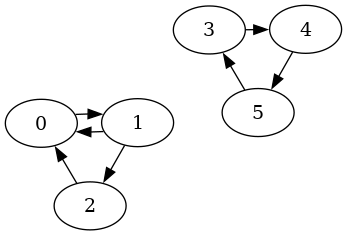

In [30]:
from qiskit.transpiler import CouplingMap
 
cmap = CouplingMap([[0, 1],[1,0], [1, 2], [2, 0], [3, 4], [4, 5], [5, 3]])
component_cmaps = cmap.connected_components()
print(component_cmaps[1].graph[0])
cmap.draw()

In [ ]:
def heuristic(tableau, ndx, ndx_list, kwargs):
    '''
    Heuristic function to produce a single reduction from one node of a tree to a child

    tableau: Cirq_Tableau holding Pauli word
    ndx: int holding index (row) of current Pauli string being reduced
    '''
    tab = tableau.copy()
    reduction = [] # reduction of Pauli string
    c_map = coupling_map.copy()
    # loop to run until break condition is met - Pauli string is implementable
    while True:
        operation = None
        benefit = -float('inf')
        reduced = 0
        increased = 0

        # break condition 
        if sum(tab.xs[ndx] | tab.zs[ndx]) == 1:
            break
            
        #  loop to cycle over all qubit indexes to get all combinations of control and target 
        for i in range(tab.column_num):
            if i != tab.column_num -1 and (tab.xs[ndx][i] or tab.zs[ndx][i]): # prevents I's 
                for j in range(i+1, tab.column_num):
                    if tab.xs[ndx][j] or tab.zs[ndx][j]: # prevents I's 
                    
                            
                        # conditions to check for better benefit with i as ctrl and j as targ
                        reduce, increase, op = compare(tab, ndx, i, j)
                        if (reduce - increase) > benefit:
                            benefit = reduce - increase
                            operation = op
                            reduced = reduce
                            increased = increase
                        elif (reduce - increase) == benefit:
                            if reduce > reduced:
                                operation = op
                                reduced = reduce
                                increased = increase
                                
                        # conditions to check for better benefit with j as ctrl and i as targ
                        reduce, increase, op = compare(tab, ndx, j, i)
                        if (reduce - increase) > benefit:
                            benefit = reduce - increase
                            operation = op
                            reduced = reduce
                            increased = increase
                        elif (reduce - increase) == benefit:
                            if reduce > reduced:
                                operation = op
                                reduced = reduce
                                increased = increase

        # condition that picks the best operation and applies it
        if operation != None:
            for action in operation:
                match action[0]:
                    case "CX":
                        tab.apply_CX(action[1], action[2])
                    case "S":
                        tab.apply_S(action[1])
                    case "H":
                        tab.apply_H(action[1])
                        
            reduction += operation # appends to reduction

    # prunes of implemented Pauli string
    tab, single_q, new_ndx_list = prune(tab, ndx_list)
    reduction += single_q # appends to reduction
    
    return tab, reduction, new_ndx_list

## Hardware Aware Heuristic Implementation

In [28]:
def generate_new_couple_list(coupling_list, register, phys_virt_map):
    couple_list = []
    key_list = phys_virt_map.keys()
    for couple in coupling_list:
        if couple[0] in key_list and couple[1] in key_list:
            couple_list.append([register.index(phys_virt_map[couple[0]]), register.index(phys_virt_map[couple[1]])])

    return couple_list

In [29]:
def ibm_layout(num_qubits, machine=FakeAlmadenV2, algorithm=DenseLayout): 
    
    backend = machine()
    
    original_coupling_list = backend.configuration().coupling_map
    original_cmap = CouplingMap(original_coupling_list)
    instance = algorithm(coupling_map=original_cmap)
    instance.run(circuit_to_dag(QuantumCircuit(num_qubits)))

    phys_virt_map = instance.property_set["layout"].get_physical_bits()
    register = list(instance.property_set['layout'].get_registers())[0]

    new_coupling_list = generate_new_couple_list(original_coupling_list, register, phys_virt_map)
    distance_matrix = np.array(CouplingMap(new_coupling_list).distance_matrix)

    return distance_matrix, new_coupling_list, CouplingMap(new_coupling_list)

In [30]:
def generate_ops(tableau, pauli_ndx, distance_matrix, coupling_list):
    #print('H')
    tab = tableau.copy()
    ops = []
    occupancy = tab.xs[pauli_ndx] | tab.zs[pauli_ndx]

    dist_vals = np.matmul(distance_matrix, occupancy) * occupancy
    #print(dist_vals)
    ndxs = np.where(dist_vals == np.max(dist_vals))[0]
    #print(ndxs)
    for ndx in ndxs:
        for couple in coupling_list:
            #if (~tab.xs[pauli_ndx][couple[1]] & ~tab.zs[pauli_ndx][couple[1]])& (~tab.xs[pauli_ndx][couple[1]] & ~tab.zs[pauli_ndx][couple[1]])
            op = []
            if couple[0] == ndx: # qubit to be eliminated lies on control
                if  int(not tab.xs[pauli_ndx][couple[1]]) & int(not tab.zs[pauli_ndx][couple[1]]): # target is I
                    ops.append([("CX", int(ndx), couple[1]),("CX", couple[1], int(ndx)),("CX", int(ndx), couple[1])])
                    continue 
                    
                if tab.xs[pauli_ndx][ndx] & ~tab.zs[pauli_ndx][ndx]: #control is X
                    op.append(("H", int(ndx)))
                elif tab.xs[pauli_ndx][ndx] & tab.zs[pauli_ndx][ndx]: #control is Y
                    op.append(("S", int(ndx)))
                    op.append(("H", int(ndx)))
                    

                if tab.xs[pauli_ndx][couple[1]] & ~tab.zs[pauli_ndx][couple[1]]: #target is X
                    ops.append(op + [("H", couple[1]), ("CX", int(ndx), couple[1])])
                    ops.append(op + [("S", couple[1]), ("CX", int(ndx), couple[1])])
                else:
                    ops.append(op + [("CX", int(ndx), couple[1])])

            elif couple[1] == ndx:# qubit to be eliminated lies on target
                if int(not tab.xs[pauli_ndx][couple[0]]) & int( not tab.zs[pauli_ndx][couple[0]]): # control is I
                    ops.append([("CX", couple[0], int(ndx)),("CX", int(ndx), couple[0]),("CX", couple[0], int(ndx))])
                    continue
                
                if tab.xs[pauli_ndx][ndx] & tab.zs[pauli_ndx][ndx]: #target is Y
                    op.append(("S", int(ndx)))
                elif ~tab.xs[pauli_ndx][ndx] & tab.zs[pauli_ndx][ndx]: #target is Z
                    op.append(("H", int(ndx)))
                
                if ~tab.xs[pauli_ndx][couple[0]] & tab.zs[pauli_ndx][couple[0]]: #control is Z
                    ops.append(op + [("H", couple[0]), ("CX", couple[0], int(ndx))])
                    ops.append(op + [("H", couple[0]),("S", couple[0]), ("CX", couple[0], int(ndx))])
                else:
                    ops.append(op + [("CX", couple[0], int(ndx))])
    #print('H') 
    #print(ops)
    if any(cx_count(x) == 1 for x in ops):
        ops = [x for x in ops if cx_count(x) == 1]
    # print("list of ops")
    # print(ops)
    #print('H') 
    return ops

In [31]:
def best_oper(tableau,pauli_ndx, op_list, distance_matrix, switch):
    #print('b')
    tab = None
    operation = None
    distance = float('inf')

    pauli_occupancy = tableau.xs[pauli_ndx] | tableau.zs[pauli_ndx]

    pauli_distance = sum(np.matmul(distance_matrix, pauli_occupancy) * pauli_occupancy)
    
    #print(op_list)
    for op in op_list:
        table = tableau.copy()

        for action in op:
            match action[0]:
                case "CX":
                    table.apply_CX(action[1], action[2])
                case "S":
                    table.apply_S(action[1])
                case "H":
                    table.apply_H(action[1])
        
        occupancy = table.xs | table.zs
        p_occupancy = occupancy[pauli_ndx]
        pauli_dist = sum(np.matmul(distance_matrix, p_occupancy) * p_occupancy)#sum(dist_vals[:, pauli_ndx])

        if switch:
            if pauli_dist <= pauli_distance: 
           
                operation = op             
                tab = table
                pauli_distance = pauli_dist

        else:
            dist_vals = np.matmul(distance_matrix, occupancy.T) * occupancy.T
            dist = sum(sum(dist_vals))
            
            if (dist < distance and pauli_dist <= pauli_distance): # or pauli_dist <= pauli_distance:
           
                operation = op
                tab = table
                distance = dist
                pauli_distance = pauli_dist
    return tab, operation

In [32]:
def hrdwre_awr_solve(tableau, pauli_ndx, ndx_list,kwargs):

    distance_matrix, coupling_list = kwargs['distance_matrix'], kwargs['coupling_list']
    tab = tableau.copy()
    reduction = []
    elapsed_states = []
    greedy_switch = False
    while sum(tab.xs[pauli_ndx] | tab.zs[pauli_ndx]) != 1:
        
        operations = generate_ops(tab, pauli_ndx, distance_matrix, coupling_list)
        # print(pauli_ndx)
        # print(tab.return_string())
        new_tab, best_op  = best_oper(tab,pauli_ndx, operations, distance_matrix, greedy_switch)

        if new_tab not in elapsed_states:
            tab = new_tab.copy()
            reduction += best_op
            elapsed_states.append(new_tab)
            #print(reduction)
            
        else:
            greedy_switch = True
            index = elapsed_states.index(new_tab)
            reduction = reduction[:index+1]
            #print(reduction)
            tab = new_tab
            continue
        
        greedy_switch = False
    tab, single_q, new_ndx_list = prune(tab, ndx_list)
    reduction += single_q
    
    return tab, reduction, new_ndx_list

## MCTS Tests

### Data collection

In [33]:
mx_ct_10_12 =[["IIIIIIZIZI", "IIZIIIIIIZ", "IZIIIIIIZI", "IIIIZIIIZI", "ZZIIIIIIII", "IIIIIZIIIZ", "IIIZIIIIZI", "IIIIZIIIIZ", "IIZIIZIIII", "IZIIIIIIIZ", "IIIZIIIZII", "IIIIIZIZII"], ["XIIIIIIIII", "IXIIIIIIII", "IIXIIIIIII", "IIIXIIIIII", "IIIIXIIIII", "IIIIIXIIII", "IIIIIIXIII", "IIIIIIIXII", "IIIIIIIIXI", "IIIIIIIIIX"]]
mx_ct_15_63 = [["IIIIIIIIIZIIIZI", "IIIIZIIIIIIIIIZ", "IIZIIIIIIIIIZII", "IIIIIIIZIIIIZII", "IZZIIIIIIIIIIII", "IIIIIIIIZIIIIIZ", "IIIIIZIIIIIIZII", "IIIIIIZIIIIIIIZ", "IIIZIIIIZIIIIII", "IZIIIIIIIIIIIZI", "IIIIIZIIIIIZIII", "IIIIIIIIZIIZIII", "ZIIIIIIZIIIIIII", "IIIIIZIIIIIIIZI", "IIIZZIIIIIIIIII", "IIZIZIIIIIIIIII", "IIIIIIZIIIIIIZI", "IIIZZIIIIIIIIII", "IIIIIIZIIIIIZII", "IIIIIIIZIIZIIII", "ZIIIZIIIIIIIIII", "IIIIIIIZIIIIIIZ", "IZIIIIIIIZIIIII", "IIIIIIIIZZIIIII", "IIIIIZIIIIZIIII", "IIZIIIZIIIIIIII", "IIIIIIIIIIIZIZI", "IIIIIIIZIIZIIII", "IIZIIIZIIIIIIII", "IZIIIIIIZIIIIII", "IIIIIIZIIIIZIII", "ZIIIIIIIIZIIIII", "IIIIZZIIIIIIIII", "IIIIIIZIIIIIZII", "IIIZIIIIIIIIIIZ", "IIIIZIIIIZIIIII", "ZIIIIIZIIIIIIII", "IIIZIIIIIIIIIZI", "IIIIIIIIIIZIZII", "IIIIIIIZIIIZIII", "IIIIIIIIIIIIZIZ", "IIIIIIIIIIIIZIZ", "IIIIIIIZIIIIZII", "IIIIIZIIIIIIIZI", "IZIIIIIZIIIIIII", "IIZIIIIIIIIZIII", "IIZIIIIIIIIIIIZ", "IIZIIIIIIIIIZII", "IIIIIIIIIIIZIIZ", "IIIZIIIIZIIIIII", "IZIIIIIZIIIIIII", "IIIIIZIIZIIIIII", "IZIIIIIIIIZIIII", "IIIIIIIIIIZIIIZ", "IIIIIIIIIIIZIZI", "ZIZIIIIIIIIIIII", "IIIZIIZIIIIIIII", "IIIIIIIIIZIIIIZ", "ZIIIIZIIIIIIIII", "ZIIIIZIIIIIIIII", "IIIIIZIIIIIIIIZ", "IZIIIIZIIIIIIII", "IIIIIIIIIZZIIII"], ["XIIIIIIIIIIIIII", "IXIIIIIIIIIIIII", "IIXIIIIIIIIIIII", "IIIXIIIIIIIIIII", "IIIIXIIIIIIIIII", "IIIIIXIIIIIIIII", "IIIIIIXIIIIIIII", "IIIIIIIXIIIIIII", "IIIIIIIIXIIIIII", "IIIIIIIIIXIIIII", "IIIIIIIIIIXIIII", "IIIIIIIIIIIXIII", "IIIIIIIIIIIIXII", "IIIIIIIIIIIIIXI", "IIIIIIIIIIIIIIX"]]
mx_ct_20_117 = [["IIIIIIIIIIIIIZIIIZII", "IIIIIZIIIIIIIIIIIIIZ", "IIZIIIIIIIIIIIIIZIII", "IIIIIIIIIZIIIIIIZIII", "IZIZIIIIIIIIIIIIIIII", "IIIIIIIIIIIZIIIIIIIZ", "IIIIIIIZIIIIIIIIZIII", "IIIIIIIIZIIIIIIIIIIZ", "IIIIIZIIIIIZIIIIIIII", "IIZIIIIIIIIIIIIIIIZI", "IIIIIIIZIIIIIIIZIIII", "IIIIIIIIIIIZIIIZIIII", "IZIIIIIIIIZIIIIIIIII", "IIIIIIZIIIIIIIIIIIZI", "IIIIZIZIIIIIIIIIIIII", "IIIZIZIIIIIIIIIIIIII", "IIIIIIIIIZIIIIIIIIZI", "IIIIZZIIIIIIIIIIIIII", "IIIIIIIIZIIIIIIIZIII", "IIIIIIIIIIZIIZIIIIII", "ZIIIIIZIIIIIIIIIIIII", "IIIIIIIIIZIIIIIIIIIZ", "IZIIIIIIIIIIIZIIIIII", "IIIIIIIIIIIZIZIIIIII", "IIIIIIIZIIIIIZIIIIII", "IIIZIIIIZIIIIIIIIIII", "IIIIIIIIIIIIIIIZIZII", "IIIIIIIIIZIIIZIIIIII", "IIIZIIIIZIIIIIIIIIII", "IIZIIIIIIIIZIIIIIIII", "IIIIIIIIZIIIIIIZIIII", "ZIIIIIIIIIIIZIIIIIII", "IIIIIIZZIIIIIIIIIIII", "IIIIIIIZIIIIIIZIIIII", "IIIIIIIIZIIIIIIIZIII", "IIIIIIIIIIZZIIIIIIII", "IIIIZIIIIIIIIIIIIIZI", "IIIIIIZIIIIIZIIIIIII", "IZIIIIIIIZIIIIIIIIII", "IIIIZIIIIIIIIIIIIIZI", "IIIIIIIIIIIIIZIIZIII", "IIIIIIIIIZIIIIIZIIII", "IIIIIIIIIIIIIIIIZIIZ", "IIIIIIIIIIIIIIIIZIIZ", "IIIIIIIIIIZIIIIIZIII", "IIIIIIZIIIIIIIIIIZII", "IIIIIZIZIIIIIIIIIIII", "IIIZIIIIIIIIIIIZIIII", "IIIZIIIIIIIIIIIIIIZI", "IIIZIIIIIIIIIIIIZIII", "IIIIIIIIIIIIIIZIIIIZ", "IIIIZIIIIIIZIIIIIIII", "IZIIIIIIIZIIIIIIIIII", "IIIIIIIZIIIZIIIIIIII", "IZIIIIIIIIIIIIZIIIII", "IIIIIIIIIIIIIZIIIIZI", "IIIIIIIIIIIIIIIZIZII", "ZIIZIIIIIIIIIIIIIIII", "IIIIZIIIZIIIIIIIIIII", "IIIIIIIIIIIIIZIIIIZI", "ZIIIIIIZIIIIIIIIIIII", "IIIIIIIIIIZIIIIIZIII", "IZIIIIZIIIIIIIIIIIII", "IIIZIIIIIZIIIIIIIIII", "IIIIIIIZIIIIIIIIIIIZ", "IZIIIIIIZIIIIIIIIIII", "IIIIIIIIIIIIZIZIIIII", "IIIIIIIZIIIIIIIIZIII", "IIIIIIIZIIIIIIZIIIII", "ZIIIIIIIIZIIIIIIIIII", "IIIIIIZIZIIIIIIIIIII", "IIIIIIIIIIIIZZIIIIII", "IIIIIIIIIIIIIIZIIIZI", "IIIIIIIIZIIIIIIIIIZI", "IIIIIIIIIZIIIIIZIIII", "IIIIIIIIZIIIIIIIIIIZ", "IIIIIZZIIIIIIIIIIIII", "IIIZIIIIIIIIIIIZIIII", "IIZIIIIIIIZIIIIIIIII", "IIIIIZIIIIIIIIIIZIII", "IIIIIIIIIIZIIIIIIIZI", "IIIIIIIIIIIIIIIZZIII", "IIIIZIIIIIIIIIIZIIII", "ZIZIIIIIIIIIIIIIIIII", "IIIZIIZIIIIIIIIIIIII", "IIIIZIIIIIIIIIIIIZII", "IIIIIIIZIIIIIIIZIIII", "IIIIIIIZIIIIZIIIIIII", "IIIIIIIIZIIIZIIIIIII", "IZIIIIIIIIIIIIIZIIII", "ZIIIIIIIIIIIIIZIIIII", "IIIIIIIIIZIIIIZIIIII", "IIZIIIIIIIIIIIIIZIII", "IIIIIIIZIIIIZIIIIIII", "IIIIIIIIIIIIIIZIZIII", "IIIZIIZIIIIIIIIIIIII", "IIIIIIIIIIIZIIIIIIIZ", "IIIIIIIIIIIIIIIIIZZI", "ZIIIIIIIIIIIIIIZIIII", "IZIIIIIIIIIIIZIIIIII", "IZIIIIIIIIIIZIIIIIII", "IIIIIIIIIIIIIZIZIIII", "IIIIIZIIIZIIIIIIIIII", "IIIIZIIIIIIIIIIZIIII", "ZZIIIIIIIIIIIIIIIIII", "IIZIIIIIIIIIIIIZIIII", "IIZIZIIIIIIIIIIIIIII", "IIIIIIZIIIIIIIIZIIII", "IIIIIZIIIIIIIZIIIIII", "IIIZIIIIIIIIIZIIIIII", "ZIIIIIIIIIIIIIIIZIII", "IIIIIIIIIIZIIIIIIIIZ", "IZIIIZIIIIIIIIIIIIII", "IIIIIIIIZIIIZIIIIIII", "IIIIIIIIIIIZIIIIIIZI", "IIIIZIIIIIIIIZIIIIII", "ZIIIIZIIIIIIIIIIIIII"], ["XIIIIIIIIIIIIIIIIIII", "IXIIIIIIIIIIIIIIIIII", "IIXIIIIIIIIIIIIIIIII", "IIIXIIIIIIIIIIIIIIII", "IIIIXIIIIIIIIIIIIIII", "IIIIIXIIIIIIIIIIIIII", "IIIIIIXIIIIIIIIIIIII", "IIIIIIIXIIIIIIIIIIII", "IIIIIIIIXIIIIIIIIIII", "IIIIIIIIIXIIIIIIIIII", "IIIIIIIIIIXIIIIIIIII", "IIIIIIIIIIIXIIIIIIII", "IIIIIIIIIIIIXIIIIIII", "IIIIIIIIIIIIIXIIIIII", "IIIIIIIIIIIIIIXIIIII", "IIIIIIIIIIIIIIIXIIII", "IIIIIIIIIIIIIIIIXIII", "IIIIIIIIIIIIIIIIIXII", "IIIIIIIIIIIIIIIIIIXI", "IIIIIIIIIIIIIIIIIIIX"]]
mx_ct_15_4 = [["IIIIIIIIIIIIIZZ", "IIIIIIZIIIIIIIZ", "IIIIIIIIIZIIIIZ", "ZIIIIIIIIIIIIIZ", "IIIIIIIIIIZIIZI", "ZIIIIIIIIIIIIZI", "IIIIIZIIIIIIIZI", "IIIIIIIIIIIZZII", "IIIIIIIIIZIIZII", "IIIIZIIIIIIIZII", "IIIIIIIZIIIIZII", "IIIIIIIIIIZZIII", "IZIIIIIIIIIZIII", "IIIIZIIIIIIZIII", "IIIIIIIIZIZIIII", "IIIIIIZIIIZIIII", "IIIIIIIIZZIIIII", "IIIZIIIIIZIIIII", "IIIIIZIIZIIIIII", "IIIIIIIZZIIIIII", "IIIIIIZZIIIIIII", "IIZIIIIZIIIIIII", "IIIIIZZIIIIIIII", "IIZIIZIIIIIIIII", "ZIIIZIIIIIIIIII", "IIIZZIIIIIIIIII", "IIZZIIIIIIIIIII", "IZIZIIIIIIIIIII", "IZZIIIIIIIIIIII", "ZZIIIIIIIIIIIII"], ["XIIIIIIIIIIIIII", "IXIIIIIIIIIIIII", "IIXIIIIIIIIIIII", "IIIXIIIIIIIIIII", "IIIIXIIIIIIIIII", "IIIIIXIIIIIIIII", "IIIIIIXIIIIIIII", "IIIIIIIXIIIIIII", "IIIIIIIIXIIIIII", "IIIIIIIIIXIIIII", "IIIIIIIIIIXIIII", "IIIIIIIIIIIXIII", "IIIIIIIIIIIIXII", "IIIIIIIIIIIIIXI", "IIIIIIIIIIIIIIX"]]
mx_ct_20_12 =[["IIIIIIIIIIIIIIIIIIZZ", "IIIZIIIIIIIIIIIIIIIZ", "IIIIIIIIIIZIIIIIIIIZ", "IIIIIZIIIIIIIIIIIIIZ", "IIIIIIIZIIIIIIIIIIIZ", "IIIIIIIIIIIIIIZIIIIZ", "IIIIIIIIIIIIIZIIIIIZ", "IIIIIIIIZIIIIIIIIIIZ", "IIIIZIIIIIIIIIIIIIIZ", "IIIIIIIIIIIIIIIIIZIZ", "ZIIIIIIIIIIIIIIIIIIZ", "IZIIIIIIIIIIIIIIIIIZ", "IIIIIIIIIIIIIIIZIIZI", "IIIIIIIIIIIIZIIIIIZI", "IIZIIIIIIIIIIIIIIIZI", "IIIIIIIIIIIIIIIIIZZI", "IZIIIIIIIIIIIIIIIIZI", "ZIIIIIIIIIIIIIIIIIZI", "IIIIIIZIIIIIIIIIIIZI", "IIIZIIIIIIIIIIIIIIZI", "IIIIIIIIIZIIIIIIIIZI", "IIIIIIIZIIIIIIIIIIZI", "IIIIIIIIIIIZIIIIIIZI", "IIIIIIIIIIIIIIIIZZII", "IIIIIIIIIIIIIIZIIZII", "IIIIIIIIIIIIIZIIIZII", "IIIZIIIIIIIIIIIIIZII", "IIIIIIIIZIIIIIIIIZII", "IIIIIIZIIIIIIIIIIZII", "IIIIIIIIIIZIIIIIIZII", "IIIIIZIIIIIIIIIIIZII", "IIIIIIIIIIIZIIIIIZII", "IIIIIIIIIIIIIIIZIZII", "IIIIIIZIIIIIIIIIZIII", "IIIIIIIZIIIIIIIIZIII", "IIIIIIIIIIIIZIIIZIII", "IIIIIIIIIIIIIZIIZIII", "IIIIZIIIIIIIIIIIZIII", "IIZIIIIIIIIIIIIIZIII", "IIIIIIIIIIIZIIIIZIII", "IIIZIIIIIIIIIIIIZIII", "IIIIIIIIIIZIIIIIZIII", "IIIIIIIIIIIIIIZIZIII", "IIIIIIIIIZIIIIIIZIII", "IIIIIIIIIIZIIIIZIIII", "IIIIIIIIZIIIIIIZIIII", "IIIIIIZIIIIIIIIZIIII", "IIIIIIIIIZIIIIIZIIII", "IIIIIIIIIIIZIIIZIIII", "IIIIIZIIIIIIIIIZIIII", "IIIIIIIIIIIIZIIZIIII", "IIIIZIIIIIIIIIIZIIII", "IIZIIIIIIIIIIIIZIIII", "IZIIIIIIIIIIIIIZIIII", "IZIIIIIIIIIIIIZIIIII", "IIIIIIIIIIIZIIZIIIII", "IIIIIIIIIIZIIIZIIIII", "IIIIIIIIIZIIIIZIIIII", "IIIIIZIIIIIIIIZIIIII", "IIIIIIIZIIIIIIZIIIII", "IIIIIIIIIIIIZIZIIIII", "IIIIIIIIIIIIIZZIIIII", "IIIIIIZIIIIIIIZIIIII", "IIIIIIIIIZIIIZIIIIII", "IIIIIIIIZIIIIZIIIIII", "IIIIIIZIIIIIIZIIIIII", "IZIIIIIIIIIIIZIIIIII", "IIIIZIIIIIIIIZIIIIII", "IIIIIZIIIIIIIZIIIIII", "IIIIIIIIIIZIIZIIIIII", "IIIIIIIZIIIIIZIIIIII", "IIIIIIIIIZIIZIIIIIII", "IIZIIIIIIIIIZIIIIIII", "IZIIIIIIIIIIZIIIIIII", "IIIIZIIIIIIIZIIIIIII", "IIIZIIIIIIIIZIIIIIII", "IIIIIZIIIIIIZIIIIIII", "IIIIIIIIIIZIZIIIIIII", "IIIIIIIZIIIIZIIIIIII", "IIIIIIIIIIZZIIIIIIII", "IIIIIIIIIZIZIIIIIIII", "IIIIIZIIIIIZIIIIIIII", "IIIIIIIZIIIZIIIIIIII", "IIIIIIZIIIIZIIIIIIII", "IIIIZIIIIIIZIIIIIIII", "IIZIIIIIIIIZIIIIIIII", "IIIZIIIIIIZIIIIIIIII", "ZIIIIIIIIIZIIIIIIIII", "IIIIIIIIZIZIIIIIIIII", "IIIIIIIIIZZIIIIIIIII", "IZIIIIIIIZIIIIIIIIII", "IIIZIIIIIZIIIIIIIIII", "IIIIIIIIZZIIIIIIIIII", "ZIIIIIIIIZIIIIIIIIII", "IIIIIIIZZIIIIIIIIIII", "IIZIIIIIZIIIIIIIIIII", "ZIIIIIIIZIIIIIIIIIII", "IZIIIIIIZIIIIIIIIIII", "IIIZIIIIZIIIIIIIIIII", "IIIIIZIIZIIIIIIIIIII", "IIZIIIIZIIIIIIIIIIII", "IIIZIIIZIIIIIIIIIIII", "IIIIZIIZIIIIIIIIIIII", "ZIIIIIIZIIIIIIIIIIII", "IIIIIZZIIIIIIIIIIIII", "IIIIZIZIIIIIIIIIIIII", "IIZIIIZIIIIIIIIIIIII", "ZIIIIIZIIIIIIIIIIIII", "IZIIIIZIIIIIIIIIIIII", "IIZIIZIIIIIIIIIIIIII", "ZIIIIZIIIIIIIIIIIIII", "IZIIIZIIIIIIIIIIIIII", "IIIZZIIIIIIIIIIIIIII", "ZIIIZIIIIIIIIIIIIIII", "IIZIZIIIIIIIIIIIIIII", "IZIIZIIIIIIIIIIIIIII", "IIZZIIIIIIIIIIIIIIII", "ZIIZIIIIIIIIIIIIIIII", "ZIZIIIIIIIIIIIIIIIII", "ZZIIIIIIIIIIIIIIIIII"], ["XIIIIIIIIIIIIIIIIIII", "IXIIIIIIIIIIIIIIIIII", "IIXIIIIIIIIIIIIIIIII", "IIIXIIIIIIIIIIIIIIII", "IIIIXIIIIIIIIIIIIIII", "IIIIIXIIIIIIIIIIIIII", "IIIIIIXIIIIIIIIIIIII", "IIIIIIIXIIIIIIIIIIII", "IIIIIIIIXIIIIIIIIIII", "IIIIIIIIIXIIIIIIIIII", "IIIIIIIIIIXIIIIIIIII", "IIIIIIIIIIIXIIIIIIII", "IIIIIIIIIIIIXIIIIIII", "IIIIIIIIIIIIIXIIIIII", "IIIIIIIIIIIIIIXIIIII", "IIIIIIIIIIIIIIIXIIII", "IIIIIIIIIIIIIIIIXIII", "IIIIIIIIIIIIIIIIIXII", "IIIIIIIIIIIIIIIIIIXI", "IIIIIIIIIIIIIIIIIIIX"]]
mx_ct_20_4 = [["IIIIIIIIIIIIIIIIIIZZ", "IIIIIIIIIZIIIIIIIIIZ", "IIIIIIIZIIIIIIIIIIIZ", "IIIIIIIIIIZIIIIIIIIZ", "IIIIIIIIIIIZIIIIIIZI", "ZIIIIIIIIIIIIIIIIIZI", "IIIIIIZIIIIIIIIIIIZI", "IIIIIIIIIIIIIIIIZZII", "IIIIIZIIIIIIIIIIIZII", "IIIZIIIIIIIIIIIIIZII", "IZIIIIIIIIIIIIIIIZII", "IIIIIIIIIIIIZIIIZIII", "IZIIIIIIIIIIIIIIZIII", "IIIIIIIZIIIIIIIIZIII", "IIIIIIIIIIIIIIZZIIII", "IIIIIIIIIIIIIZIZIIII", "IIIIIIIIIZIIIIIZIIII", "IIIZIIIIIIIIIIIZIIII", "IIIIIIIIIIIIZIZIIIII", "IIIIIIIIIIIZIIZIIIII", "IIIIIIIZIIIIIIZIIIII", "IIIIIIZIIIIIIZIIIIII", "IIIIIIIIZIIIIZIIIIII", "IIIIIIIIIIZIIZIIIIII", "ZIIIIIIIIIIIZIIIIIII", "IIIZIIIIIIIIZIIIIIII", "IIZIIIIIIIIZIIIIIIII", "ZIIIIIIIIIIZIIIIIIII", "IIIIIIIIIZZIIIIIIIII", "IIIIIIIIZIZIIIIIIIII", "IIIIZIIIIZIIIIIIIIII", "IIIIIIIZZIIIIIIIIIII", "IZIIIIIIZIIIIIIIIIII", "IIZIIIZIIIIIIIIIIIII", "IIIIZIZIIIIIIIIIIIII", "IIIZIZIIIIIIIIIIIIII", "IZIIIZIIIIIIIIIIIIII", "IIZIIZIIIIIIIIIIIIII", "IIZIZIIIIIIIIIIIIIII", "ZIIIZIIIIIIIIIIIIIII"], ["XIIIIIIIIIIIIIIIIIII", "IXIIIIIIIIIIIIIIIIII", "IIXIIIIIIIIIIIIIIIII", "IIIXIIIIIIIIIIIIIIII", "IIIIXIIIIIIIIIIIIIII", "IIIIIXIIIIIIIIIIIIII", "IIIIIIXIIIIIIIIIIIII", "IIIIIIIXIIIIIIIIIIII", "IIIIIIIIXIIIIIIIIIII", "IIIIIIIIIXIIIIIIIIII", "IIIIIIIIIIXIIIIIIIII", "IIIIIIIIIIIXIIIIIIII", "IIIIIIIIIIIIXIIIIIII", "IIIIIIIIIIIIIXIIIIII", "IIIIIIIIIIIIIIXIIIII", "IIIIIIIIIIIIIIIXIIII", "IIIIIIIIIIIIIIIIXIII", "IIIIIIIIIIIIIIIIIXII", "IIIIIIIIIIIIIIIIIIXI", "IIIIIIIIIIIIIIIIIIIX"]]
mx_ct_20_8 = [["IIIIIIIIIIIIIIIIIIZZ", "IIIIIIIIZIIIIIIIIIIZ", "IIIIIIIIIIZIIIIIIIIZ", "IIIIIIIIIIIIIIIZIIIZ", "IIIIIIIIIIIZIIIIIIIZ", "IIIIIIIIIIIIIZIIIIIZ", "ZIIIIIIIIIIIIIIIIIIZ", "IIIZIIIIIIIIIIIIIIIZ", "IIIIIIIIIIIZIIIIIIZI", "IIIIIIIZIIIIIIIIIIZI", "IIIIIIIIIZIIIIIIIIZI", "IZIIIIIIIIIIIIIIIIZI", "IIIIIIIIIIIIIIIIIZZI", "IIIIIIIIIIIIIIZIIIZI", "IIIIIIIIIIIIZIIIIIZI", "IIIIIIIIIIIIIIIIZZII", "IIIIIIIZIIIIIIIIIZII", "IIZIIIIIIIIIIIIIIZII", "IIIIIIIIIIIIIIZIIZII", "IIIIIIIIZIIIIIIIIZII", "IIIIIIIIIIZIIIIIIZII", "IIIIIZIIIIIIIIIIIZII", "IIIIIIIIZIIIIIIIZIII", "IZIIIIIIIIIIIIIIZIII", "IIZIIIIIIIIIIIIIZIII", "IIIIIIIIIIIIIIIZZIII", "IIIIIIIIIIIZIIIIZIII", "IIIIIZIIIIIIIIIIZIII", "IIIIIIIIIIIIIZIIZIII", "IIIIIIIIIIIIIIZZIIII", "IIIIIIIZIIIIIIIZIIII", "IIIIIIZIIIIIIIIZIIII", "IIIIZIIIIIIIIIIZIIII", "IIIZIIIIIIIIIIIZIIII", "IIZIIIIIIIIIIIIZIIII", "IIIIIIIZIIIIIIZIIIII", "IIIIZIIIIIIIIIZIIIII", "ZIIIIIIIIIIIIIZIIIII", "IIIIIIZIIIIIIIZIIIII", "IIIIIIIIIIZIIIZIIIII", "IIIIIIIIIIIIZZIIIIII", "IIIIZIIIIIIIIZIIIIII", "IIZIIIIIIIIIIZIIIIII", "IIIIIIZIIIIIIZIIIIII", "IIIIIIIIZIIIIZIIIIII", "IIIIIZIIIIIIIZIIIIII", "IIIIZIIIIIIIZIIIIIII", "IIIIIIIIIIZIZIIIIIII", "IIIIIIIIIIIZZIIIIIII", "IIIIIIIIIZIIZIIIIIII", "ZIIIIIIIIIIIZIIIIIII", "IIIIIIIIZIIIZIIIIIII", "IIIIIIIIIZIZIIIIIIII", "IIIIIIZIIIIZIIIIIIII", "IIIIIIIIZIIZIIIIIIII", "IIIIIIIIIIZZIIIIIIII", "IIIIIIIIIZZIIIIIIIII", "IIIIIIIZIIZIIIIIIIII", "IIIZIIIIIIZIIIIIIIII", "IIZIIIIIIZIIIIIIIIII", "IZIIIIIIIZIIIIIIIIII", "IIIIIZIIIZIIIIIIIIII", "IIIIZIIIIZIIIIIIIIII", "IIIZIIIIZIIIIIIIIIII", "ZIIIIIIIZIIIIIIIIIII", "IZIIIIIZIIIIIIIIIIII", "ZIIIIIIZIIIIIIIIIIII", "IIIIIZIZIIIIIIIIIIII", "IIIIIZZIIIIIIIIIIIII", "IIIZIIZIIIIIIIIIIIII", "IIZIIIZIIIIIIIIIIIII", "ZIIIIIZIIIIIIIIIIIII", "IIIZIZIIIIIIIIIIIIII", "ZIIIIZIIIIIIIIIIIIII", "IZIIZIIIIIIIIIIIIIII", "IIIZZIIIIIIIIIIIIIII", "IIZIZIIIIIIIIIIIIIII", "IZIZIIIIIIIIIIIIIIII", "IZZIIIIIIIIIIIIIIIII", "ZZIIIIIIIIIIIIIIIIII"], ["XIIIIIIIIIIIIIIIIIII", "IXIIIIIIIIIIIIIIIIII", "IIXIIIIIIIIIIIIIIIII", "IIIXIIIIIIIIIIIIIIII", "IIIIXIIIIIIIIIIIIIII", "IIIIIXIIIIIIIIIIIIII", "IIIIIIXIIIIIIIIIIIII", "IIIIIIIXIIIIIIIIIIII", "IIIIIIIIXIIIIIIIIIII", "IIIIIIIIIXIIIIIIIIII", "IIIIIIIIIIXIIIIIIIII", "IIIIIIIIIIIXIIIIIIII", "IIIIIIIIIIIIXIIIIIII", "IIIIIIIIIIIIIXIIIIII", "IIIIIIIIIIIIIIXIIIII", "IIIIIIIIIIIIIIIXIIII", "IIIIIIIIIIIIIIIIXIII", "IIIIIIIIIIIIIIIIIXII", "IIIIIIIIIIIIIIIIIIXI", "IIIIIIIIIIIIIIIIIIIX"]]

In [34]:
import pickle 
from qiskit.qasm3 import dumps

In [35]:
def create_scale(step,start = 0, stop = 10):
    return np.arange(start, stop+step, step).tolist()

In [36]:
def data_collection(p_dict, function, parameter_list, times,divs, cancellation=True):
    for key in p_dict.keys():
        p_sentence = p_dict[key]
        num_qubits = len(p_sentence[0][0])
        p_sent_dict = dict()
        for parameter in parameter_list:
            div_dict = dict()
            for div in divs:
                for t in times:
                    start = time.time()
                    dist, c_list, c_map = ibm_layout(num_qubits, machine=FakeManhattanV2)
                    circuit, new_order = full_circuit(p_sentence, function, parameter, t,divs=div, gate_cancellation=cancellation, synth=1, distance_matrix=dist,coupling_list=c_list)
                    circuit = transpile(circuit, basis_gates=["cx", "rz", "s", "sdg", "h"])
                    end = time.time()
                    if div in div_dict:
                        div_dict[div].append((circuit.count_ops()['cx'],t,(end-start), dumps(circuit), new_order))
                    else:
                        div_dict.update({div : [(circuit.count_ops()['cx'],t,(end-start), dumps(circuit), new_order)]})
            if parameter in p_sent_dict:
                p_sent_dict[parameter].append(div_dict)
            else:
                p_sent_dict.update({parameter: [div_dict]})
        with open(f"{key}.pkl", "wb") as file:
            pickle.dump(p_sent_dict, file)

In [42]:
time_list = create_scale(0.5, start=0.5, stop=60)
time_list_2 = create_scale(0.05, start=0.05, stop=1)
param_list = create_scale(1)
div_list = [1]

ham_dict = dict(
    {
    "ucc_6_12_hrdwr" : ucc_6_12_comm,
    "NH3_hrdwr": NH3_comm,
    "H2O_hrdwr": H2O_comm,
    "CO_hrdwr" : CO_comm,
    "ucc_2_4_hrdwr" : ucc_2_4_comm,
    "H2_hrdwr" : H2_comm,
    "ucc_8_16_hrdwr":ucc_8_16_comm
    }
)

In [43]:
data_collection(ham_dict, hrdwre_awr_solve, param_list, time_list_2,div_list, cancellation=True)

KeyboardInterrupt: 

### Hardware aware Tests

In [259]:
dist, c_list, c_map = ibm_layout(4, machine=FakeManhattanV2)
print(c_list)
cirquit = full_circuit(H2_comm, hrdwre_awr_solve, 0, 0.05, divs=1, rot_params = None, gate_cancellation=True, synth = 1, distance_matrix = dist, coupling_list=c_list)

[[2, 1], [2, 3], [1, 2], [1, 0], [0, 1], [3, 2]]


In [260]:
cc = transpile(cirquit[0], basis_gates=["cx", "rz", "s", "sdg", "h"])
cc.count_ops()['cx']

26

### Rustiq Tests

In [40]:
from qiskit.quantum_info import Pauli, SparsePauliOp, Clifford
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.transpiler.passes.synthesis.hls_plugins import PauliEvolutionSynthesisRustiq, GreedySynthesisClifford 
from qiskit import transpile

In [106]:
def create_operator(p_whole):
    # Creating operator - rustiq qiskit implementation requires PauliEvolutionGate
    # PauliEvolutionGate takes in Paulis before trotterization - trotterization occurs during rustiq run
    operator = None
    
    for string in p_whole:
        if operator == None:
            operator = SparsePauliOp(string)
        else:
            operator = operator +  SparsePauliOp(string)
        
    return PauliEvolutionGate(operator, time=1)

In [141]:
op = create_operator(ucc_10_20_whole)
print(op)

Instruction(name='PauliEvolution', num_qubits=20, num_clbits=0, params=[1.0])


In [ ]:
c = QuantumCircuit(8)
c.append(op, c.qubits)
c.draw()

In [136]:
from qiskit.transpiler.passes.synthesis.hls_plugins import PauliEvolutionSynthesisDefault

In [142]:
default = PauliEvolutionSynthesisDefault()
cirq = default.run(op, preserve_order=True)

In [143]:
rustiq = PauliEvolutionSynthesisRustiq() #rustiq pass
# resynth_clifford_method=1 uses Qiskit greedy synthesis
cirq2 = rustiq.run(op, preserve_order=True,optimize_count=True, resynth_clifford_method=1,upto_phase=True, upto_clifford=False)



In [144]:
cirq.count_ops()['cx']

108800

In [145]:
cirq2.count_ops()['cx']

21614

In [33]:
from qiskit.quantum_info import Statevector

# comparing state vectors for equivalence 
Statevector.from_instruction(cirq).equiv(Statevector.from_instruction(c))

True

In [34]:
from mqt import qcec
from qiskit.qasm3 import dumps
# verify the equivalence of two circuits provided as qasm files
result = qcec.verify(dumps(cirq), dumps(c))

# print the result
print(result.equivalence)

equivalent_up_to_global_phase


### Revised MCTS Tests

In [179]:
circuit, new_order = full_circuit(ucc_4_8_comm, pair_solve, 0, 1, divs=2,  gate_cancellation=True, synth=1, key=1)
#circuit.draw('mpl')

In [180]:
circuit.count_ops()['cx'] 

294